In [6]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import copy
import time

In [7]:

def sigmoid(x):
    return 1/(1+np.exp(-x))

def min_max_vals(x_list, y_list):
    x = np.array(x_list, dtype=np.float32).reshape(-1, 1)
    y = np.array(y_list, dtype=np.float32).reshape(-1, 1)
    return x.min(), x.max(), y.min(), y.max()

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def grad_sigmoid(x):
    return sigmoid(x) * (1 -sigmoid(x))

def tanh(x):
    return np.tanh(x)

def grad_tanh(x):
    return 1 - np.tanh(x)**2



In [8]:

def data_to_matrix(data, test_data):
    x_list, y_list = [], []
    for i, row in enumerate(data):
        if i > 0:
            if len(row) == 3:
                _, x, y = row
            elif len(row) == 2:
                x, y = row
            else:
                raise ValueError("Nieoczekiwany format wiersza")

            x_list.append(float(x))
            y_list.append(float(y))
            
    test_x_list, test_y_list = [], []
    for i, row in enumerate(test_data):
        if i > 0:
            if len(row) == 3:
                _, x, y = row
            elif len(row) == 2:
                x, y = row
            else:
                raise ValueError("Nieoczekiwany format wiersza")

            test_x_list.append(float(x))
            test_y_list.append(float(y))
            
    return (
        np.array(x_list).reshape(-1, 1),
        np.array(test_x_list).reshape(-1, 1),
        np.array(y_list).reshape(-1, 1),
        np.array(test_y_list).reshape(-1, 1)
    )

In [9]:

class MLP:
    def __init__(self, layer_num, act_func, grad_act_func, w=None, biases_w=None, x_min=None, x_max=None, y_min=None, y_max=None):
        self.layer_num = layer_num
        self.act_func = act_func
        self.grad_act_func = grad_act_func
        self.weight_history = []
        
        self.mse_history = []

        if w is None:
            self.w = [np.random.uniform(-1, 1, (layer_num[i], layer_num[i+1])) for i in range(len(layer_num)-1)]
        else:
            self.w = w

        if biases_w is None:
            self.biases_w = [np.random.uniform(-1, 1, (1, layer_num[i+1])) for i in range(len(layer_num)-1)]
        else:
            self.biases_w = biases_w
        
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max

    def calc(self, x_denorm): # działa jak forward ale nie wymaga normalizacji przed uruchomieniem
        x_denorm = np.array(x_denorm, dtype=np.float32)
        temp = (x_denorm - self.x_min) / (self.x_max - self.x_min)
        if temp.ndim == 1:
            temp = temp.reshape(1, -1)
            
        self.pre_activation_vals = []
        self.activations = [temp]
        
        for layer_id in range(len(self.layer_num) - 1):
            z = self.activations[-1] @ self.w[layer_id] + self.biases_w[layer_id]
            self.pre_activation_vals.append(z)

            if layer_id < len(self.layer_num) - 2:
                a = self.act_func(z)
            else:
                a = z
            self.activations.append(a)
            
        return self.activations[-1] * (self.y_max - self.y_min) + self.y_min

    def forward(self, x):
        temp = np.array(x, dtype=np.float32)
        if temp.ndim == 1:
            temp = temp.reshape(1, -1)
            
        self.pre_activation_vals = []
        self.activations = [temp]
        
        for layer_id in range(len(self.layer_num) - 1):
            z = self.activations[-1] @ self.w[layer_id] + self.biases_w[layer_id]
            self.pre_activation_vals.append(z)

            if layer_id < len(self.layer_num) - 2:
                a = self.act_func(z)
            else:
                a = z
            self.activations.append(a)
            
        return self.activations[-1]

    def backward(self, y_true):
            
        batch_size = y_true.shape[0]
        length = len(self.layer_num) - 1
        y_pred = self.activations[-1]
        
        grad_w = [None] * length
        grad_biases_w = [None] * length
        
        delta = (y_pred - y_true)

        for layer_id in reversed(range(length)):
            a_prev = self.activations[layer_id]
            
            grad_w[layer_id] = (a_prev.T @ delta) / batch_size
            grad_biases_w[layer_id] = np.sum(delta, axis=0, keepdims=True) / batch_size

            if layer_id > 0:
                delta = (delta @ self.w[layer_id].T) * self.grad_act_func(self.pre_activation_vals[layer_id - 1])
                
        return grad_w, grad_biases_w

    def update_weights(self, grad_w, grad_biases_w, lr=0.01):
        for i in range(len(self.w)):
            self.w[i] -= lr * grad_w[i]
            self.biases_w[i] -= lr * grad_biases_w[i]

    def train(self, X, Y, epochs=100, lr=0.01, batch_size=1, verbose= False, display_weights=True, epochs_between_graphs=100000):
        X = np.array(X)
        Y = np.array(Y)
        if X.ndim == 1: 
            X = X.reshape(-1, 1)
        if Y.ndim == 1: 
            Y = Y.reshape(-1, 1)
        
        self.x_min, self.x_max = X.min(axis=0), X.max(axis=0)
        self.y_min, self.y_max = Y.min(axis=0), Y.max(axis=0)
        
        X_norm = (X - self.x_min) / (self.x_max - self.x_min +0.000000001)
        Y_norm = (Y - self.y_min) / (self.y_max - self.y_min+0.000000001)


        for epoch in range(epochs):
            indices = np.random.permutation(len(X_norm))
            X_shuffled = X_norm[indices]
            Y_shuffled = Y_norm[indices]
            
            for i in range(0, len(X_norm), batch_size):
                x_batch = X_shuffled[i:i+batch_size]
                y_batch = Y_shuffled[i:i+batch_size]
                
                self.forward(x_batch)
                grad_w, grad_biases_w = self.backward(y_batch)
                self.update_weights(grad_w, grad_biases_w, lr)

            if (epoch % 100 == 0 or epoch == epochs - 1):
                y_pred_all = self.calc(X)
                current_mse = np.mean((Y - y_pred_all)**2)
                self.mse_history.append(current_mse)
                if (verbose and epoch % epochs_between_graphs == 0) or epoch == epochs - 1:
                    
    
                    plt.figure(figsize=(8, 5))
                    
                    plt.scatter(X, Y, color='gray', alpha=0.5, s=15, label='Dane rzeczywiste')
                    
                    sort_idx = np.argsort(X.flatten())
                    plt.plot(X.flatten()[sort_idx], y_pred_all.flatten()[sort_idx], 
                             color='red', linewidth=2, label=f'Model po {epoch} epokach')
                    
                    plt.title(f"EPOKA {epoch} | MSE: {current_mse:.6f}")
                    plt.xlabel("X")
                    plt.ylabel("Y")
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    
                    plt.show()
                self.weight_history.append([w.copy() for w in self.w])
        print('========================')
        print('Wagi:')
        print(self.w)
        print('Bias:')
        print(self.biases_w)

    def visualize_weights(self, epoch=-1):
        weights = self.weight_history[epoch]
    
        for i, w in enumerate(weights):
            plt.figure(figsize=(6,4))
            plt.imshow(w, cmap='coolwarm', aspect='auto')
            plt.colorbar()
            plt.title(f"Wagi warstwy {i} → {i+1} (epoka {epoch})")
            plt.xlabel("Neuron następnej warstwy")
            plt.ylabel("Neuron poprzedniej warstwy")
            plt.show()

    def plot_weight_evolution(self, layer_id=0):
        history = []
    
        for epoch_w in self.weight_history:
            history.append(epoch_w[layer_id].flatten())
    
        history = np.array(history)
    
        plt.figure(figsize=(8,5))
    
        for i in range(history.shape[1]):
            plt.plot(history[:, i], alpha=0.5)
    
        plt.title(f"Zmiana wag w czasie (warstwa {layer_id})")
        plt.xlabel("Epoka")
        plt.ylabel("Wartość wagi")
        plt.grid(True)
        plt.show()

    def plot_weight_norms(self):

        norms = []
    
        for epoch_w in self.weight_history:
            norms.append([np.linalg.norm(w) for w in epoch_w])
    
        norms = np.array(norms)
    
        plt.figure(figsize=(8,5))
    
        for i in range(norms.shape[1]):
            plt.plot(norms[:, i], label=f"Warstwa {i}")
    
        plt.title("Norma wag w czasie")
        plt.xlabel("Epoka")
        plt.ylabel("||W||")
        plt.legend()
        plt.grid(True)
        plt.show()


In [27]:
def plot_model_predictions(model, test_x, test_y):

    y_pred = model.calc(test_x)

    test_x = np.array(test_x).flatten()
    test_y = np.array(test_y).flatten()
    y_pred = np.array(y_pred).flatten()

    idx = np.argsort(test_x)
    test_x = test_x[idx]
    test_y = test_y[idx]
    y_pred = y_pred[idx]

    mse = np.mean((test_y - y_pred) ** 2)

    plt.figure()
    plt.scatter(test_x, test_y, label="true")
    plt.plot(test_x, y_pred, label="pred", color='red')

    plt.title(f"MSE: {mse}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()

    plt.show()

In [10]:

data_square_simple = csv.reader(open('mio1/regression/square-simple-training.csv'))
test_data_square_simple = csv.reader(open('mio1/regression/square-simple-test.csv'))


In [11]:

x_ss, test_x_ss, y_ss, test_y_ss = data_to_matrix(data_square_simple, test_data_square_simple)

In [50]:

# model na square simple

np.random.seed(52)

layer_num = [1,5,5,1]
mlp_ss_full = MLP(layer_num, sigmoid, grad_sigmoid)
mlp_ss_batch = MLP(layer_num, sigmoid, grad_sigmoid)

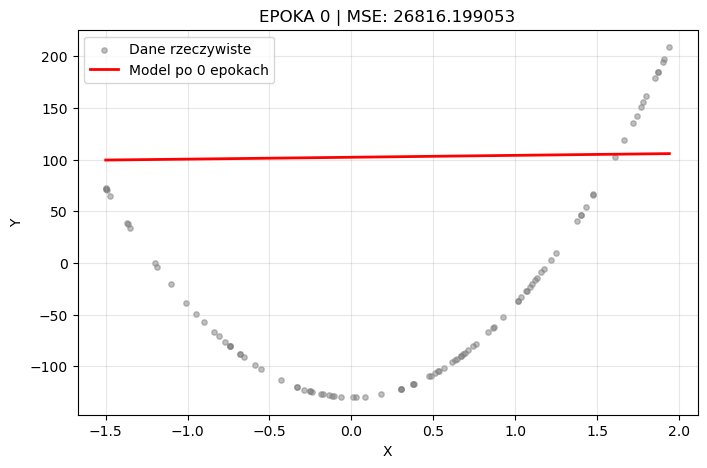

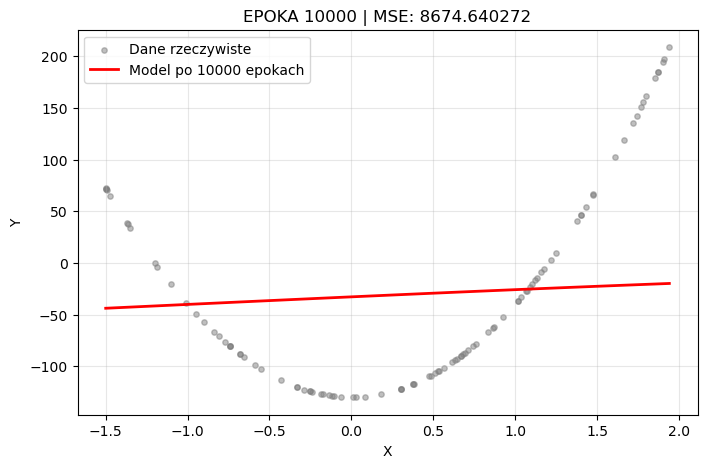

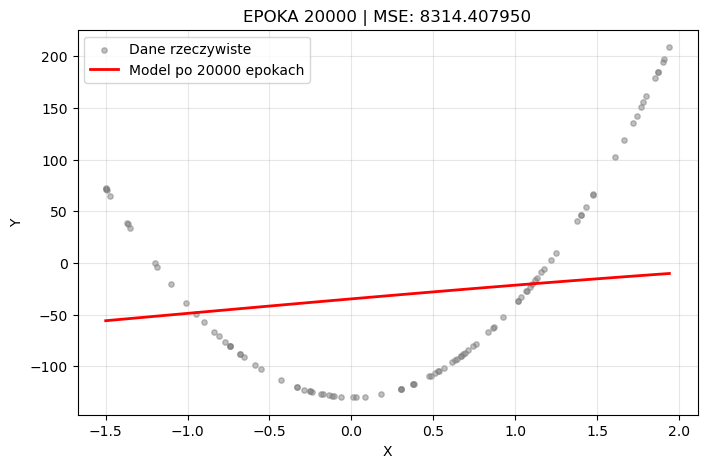

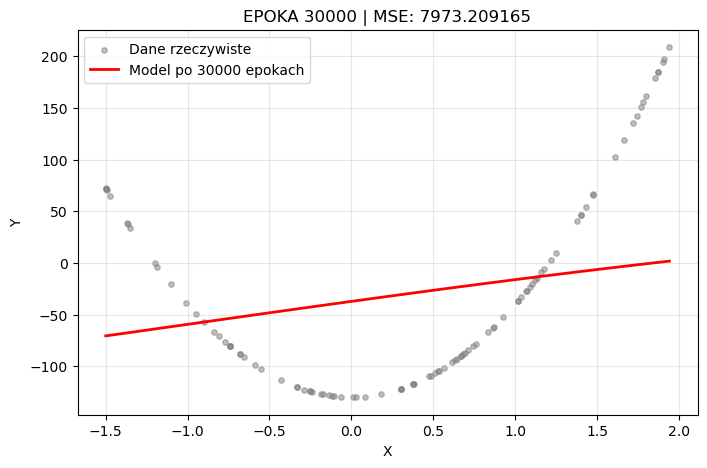

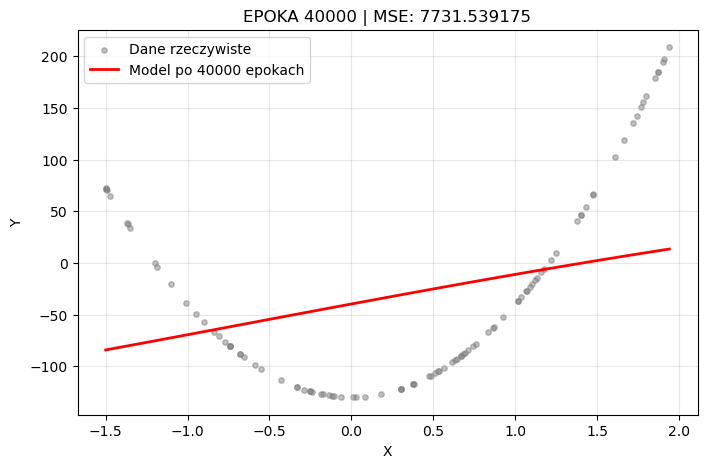

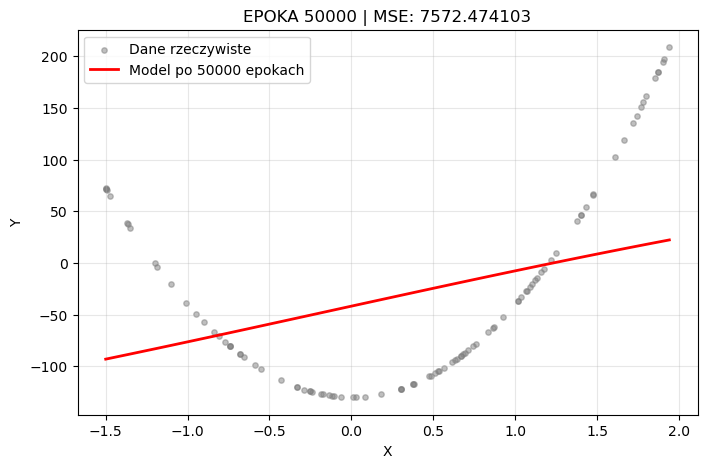

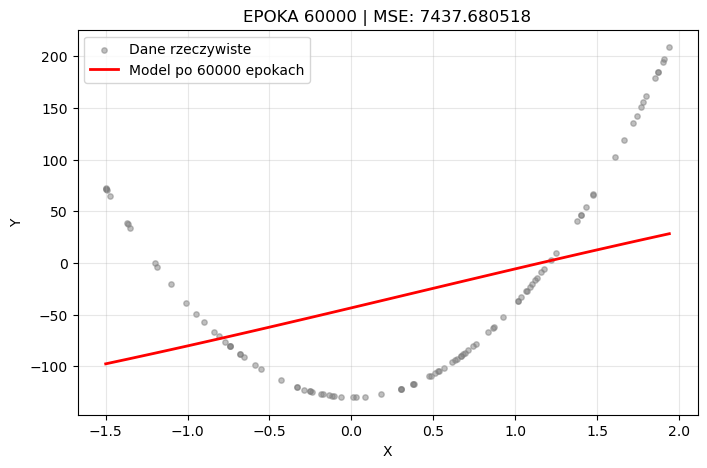

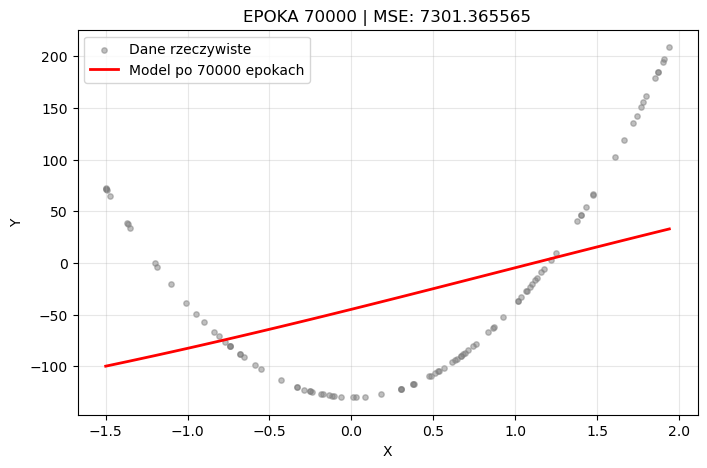

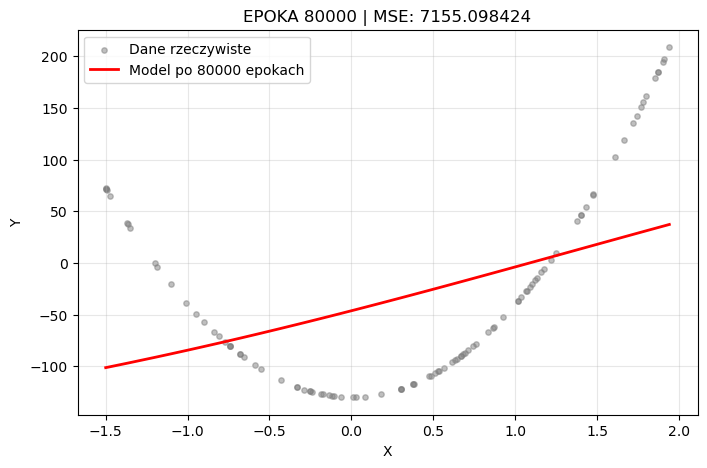

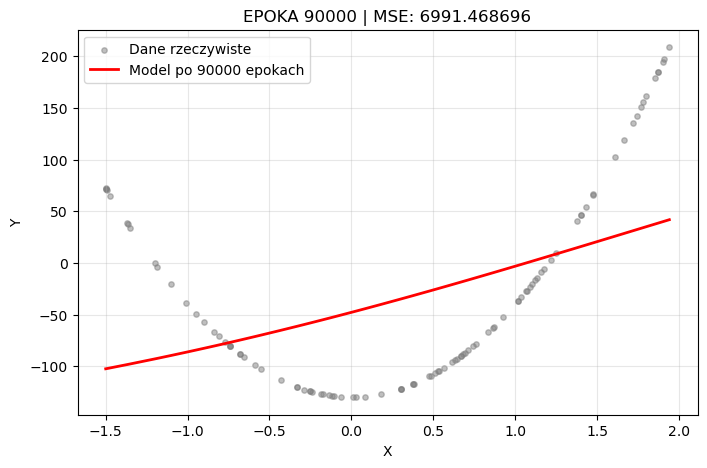

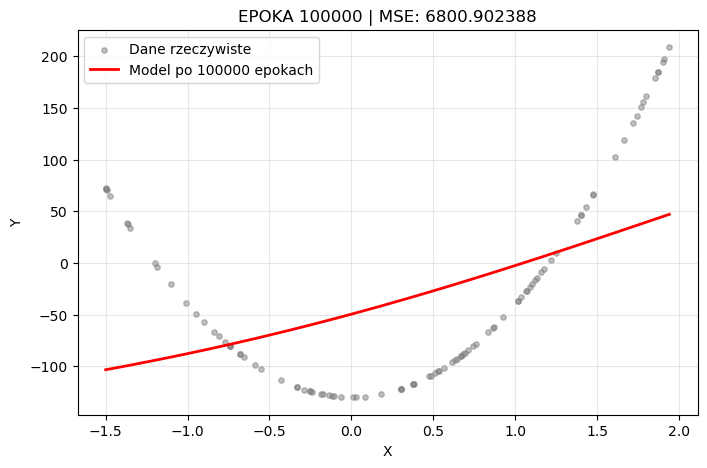

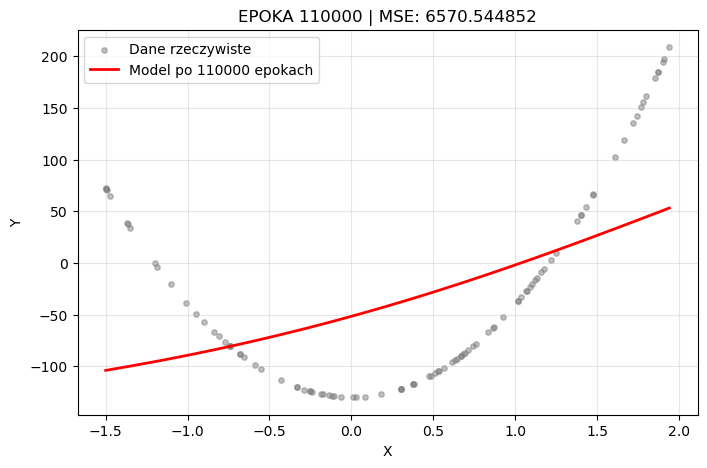

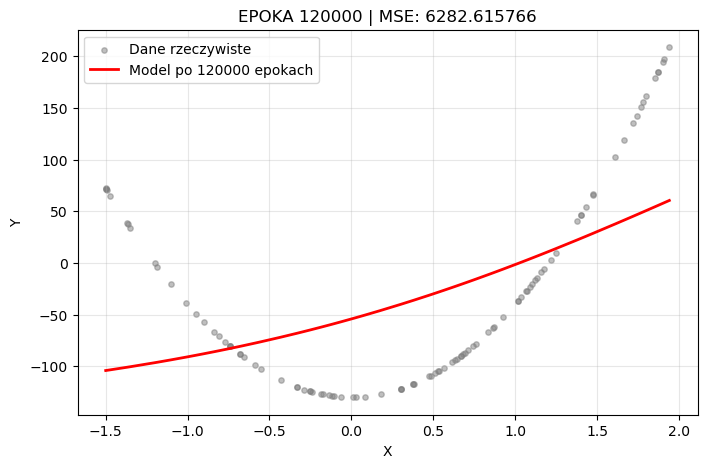

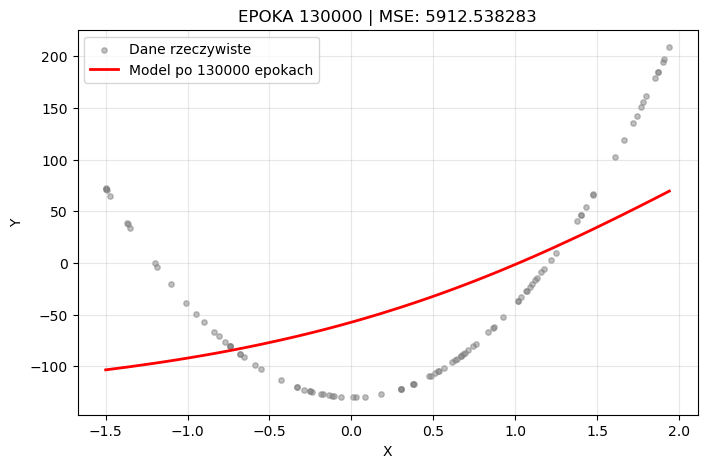

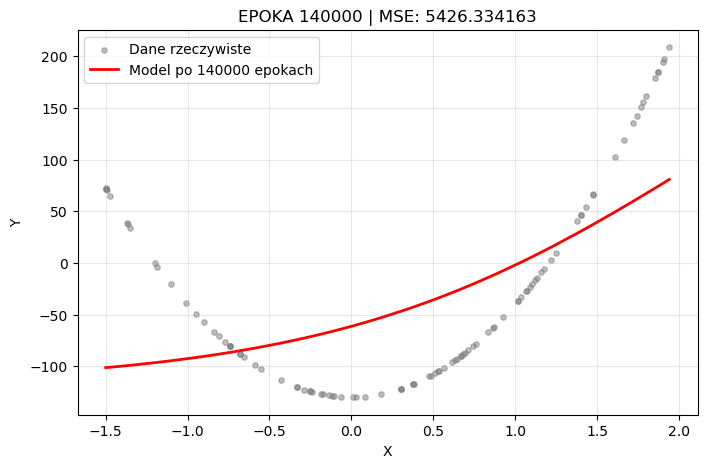

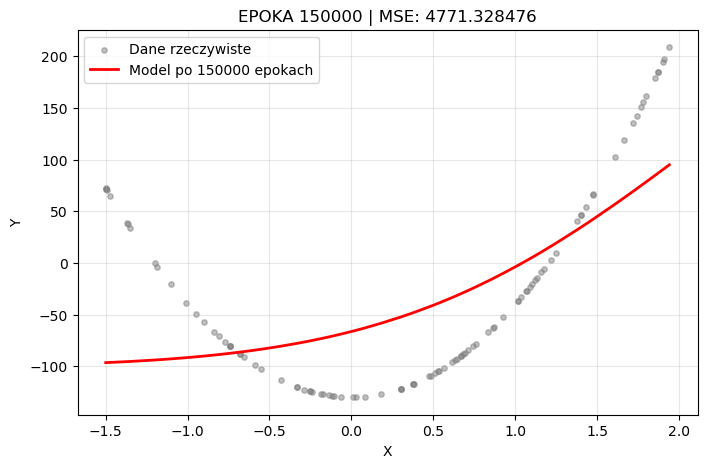

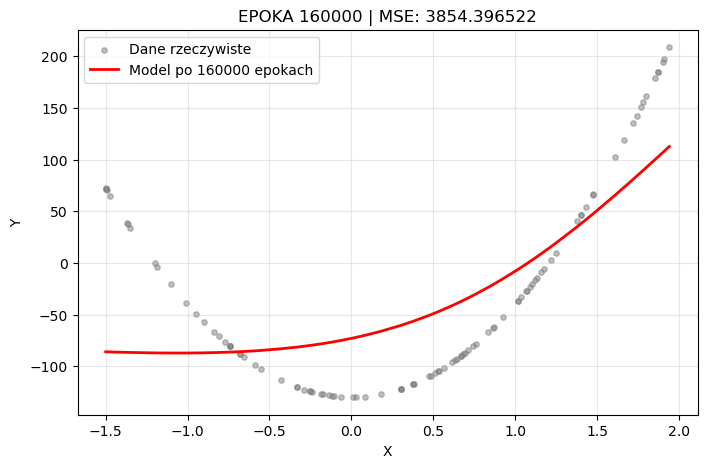

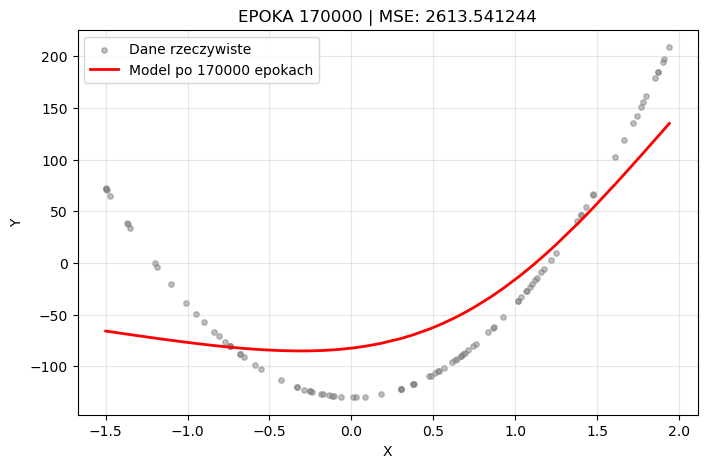

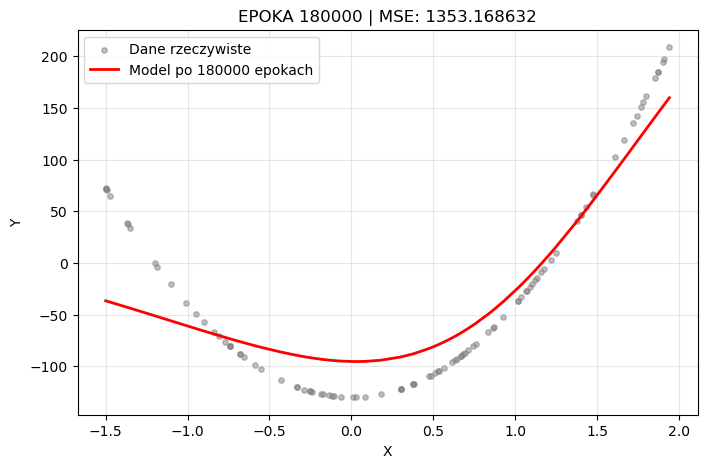

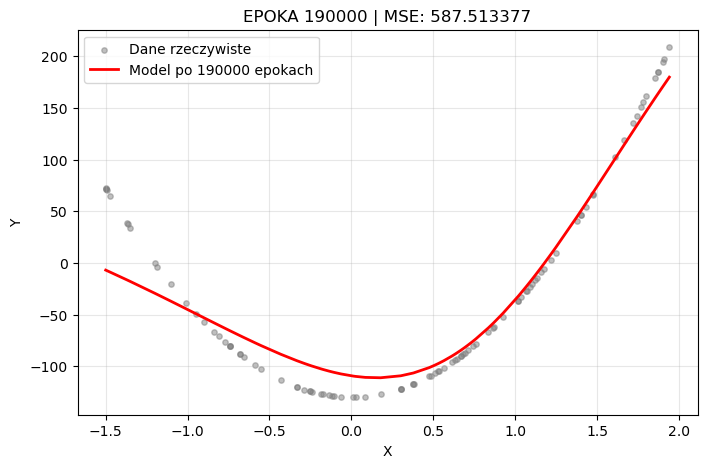

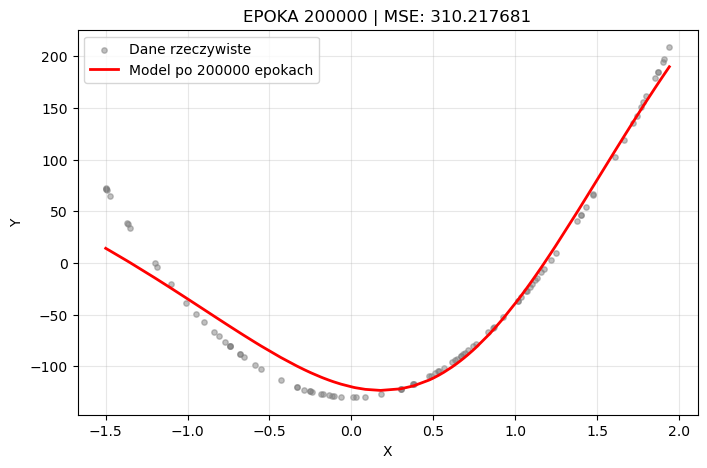

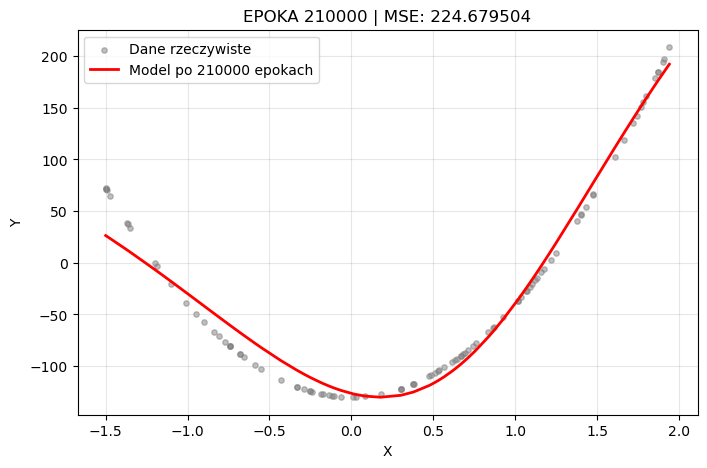

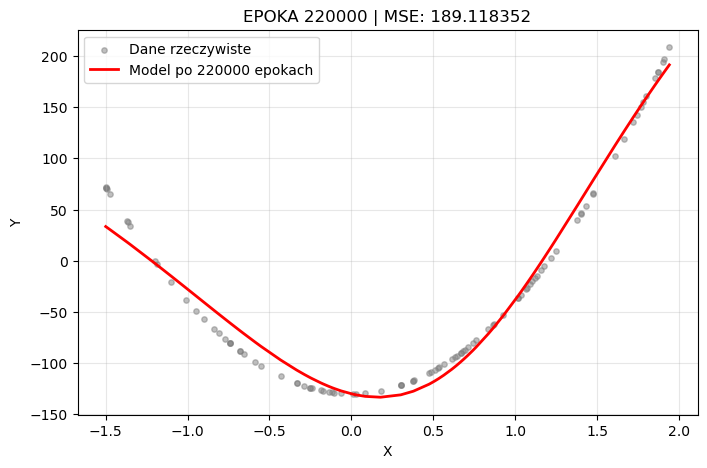

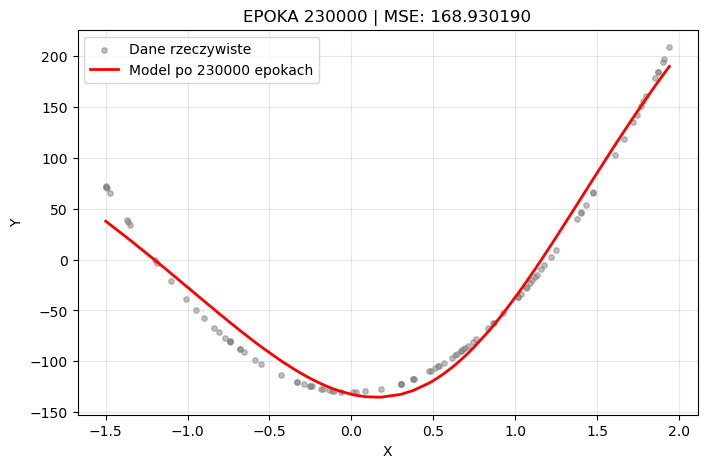

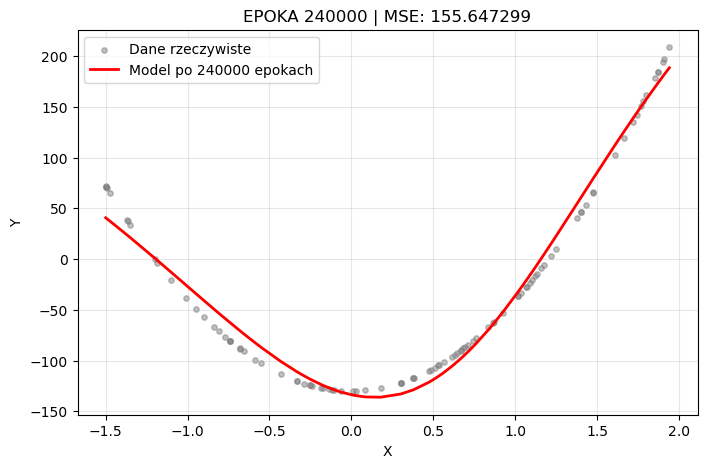

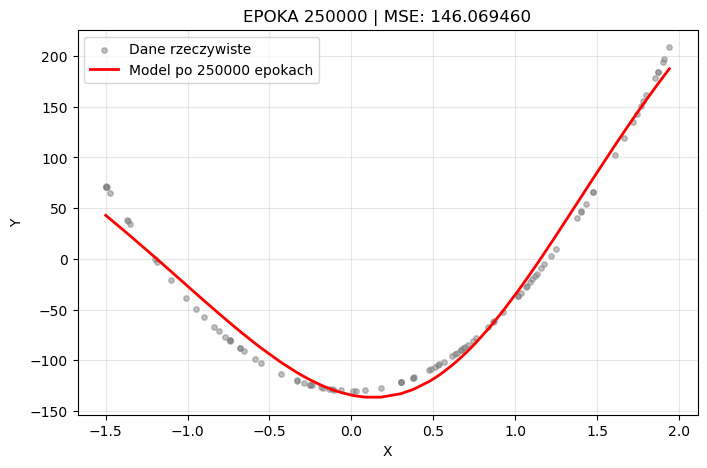

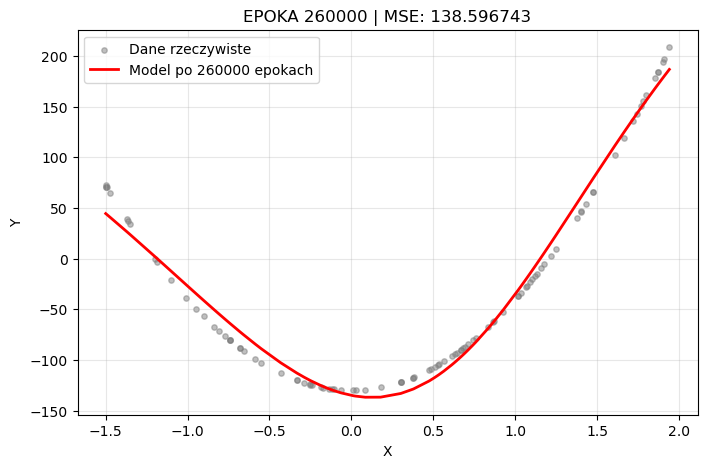

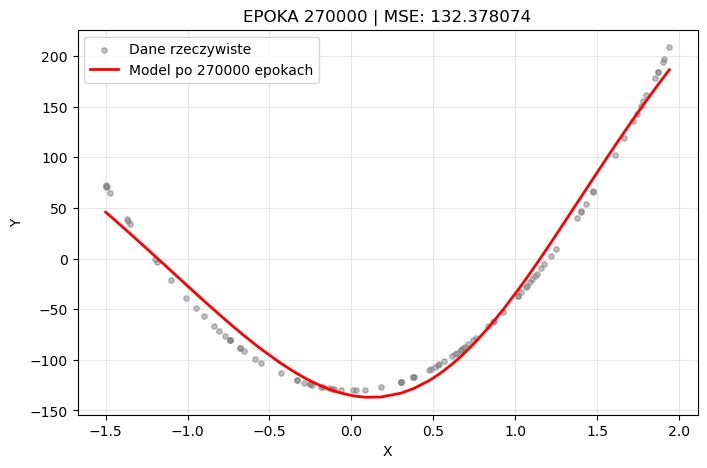

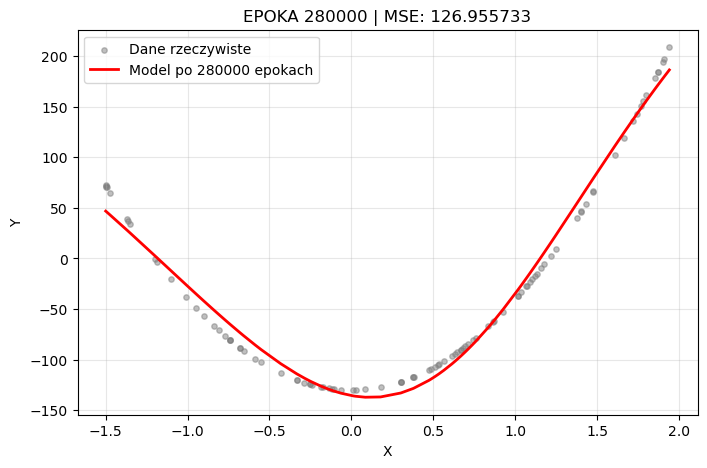

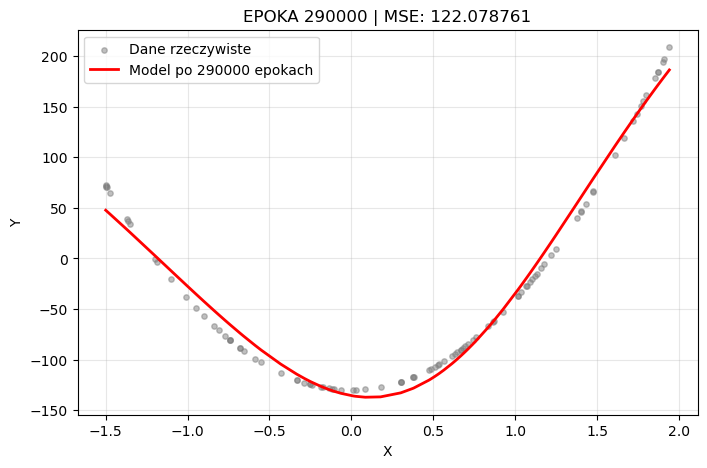

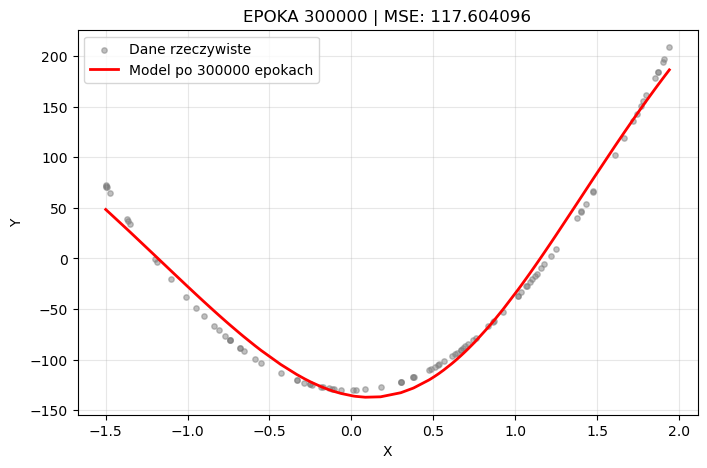

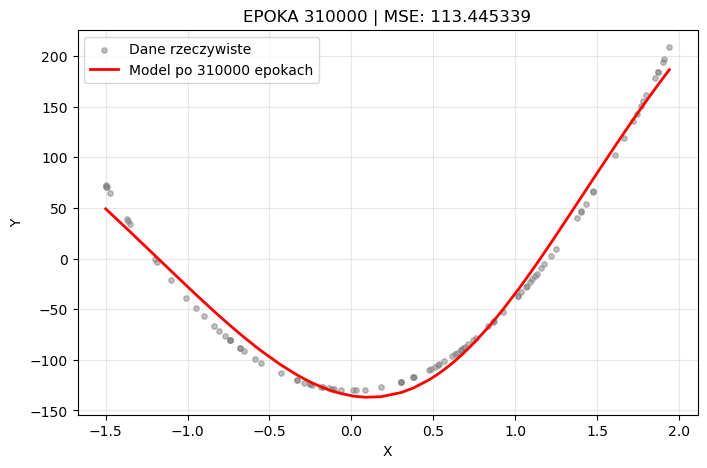

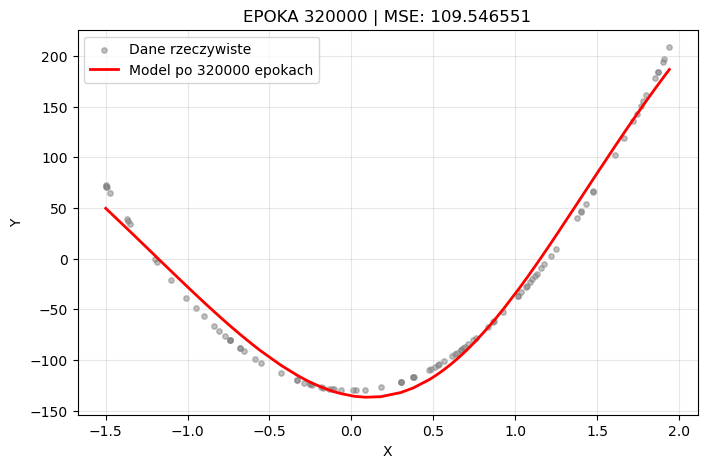

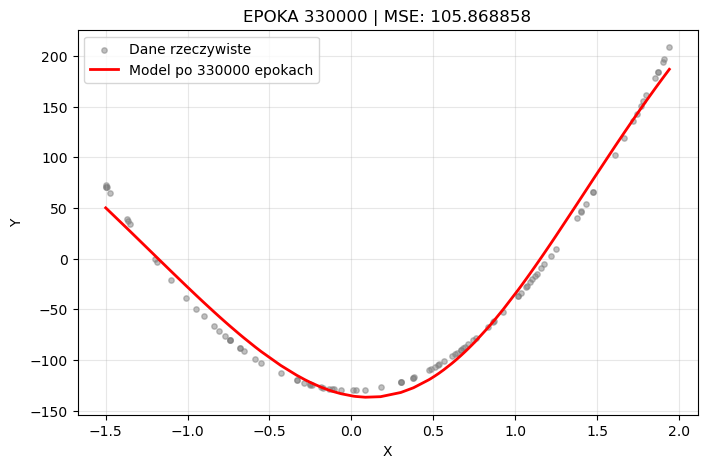

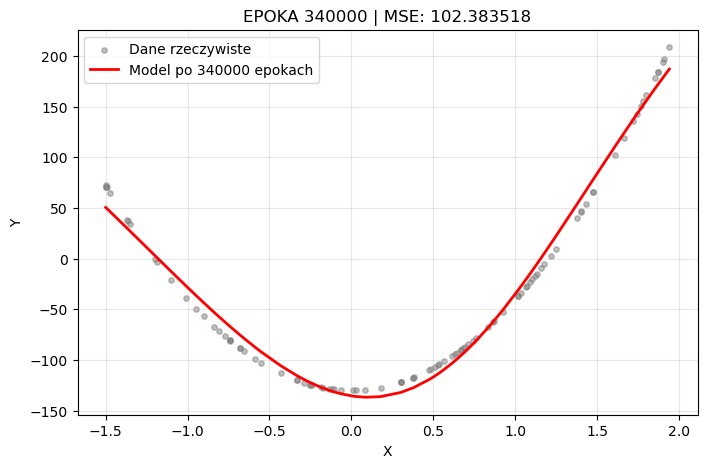

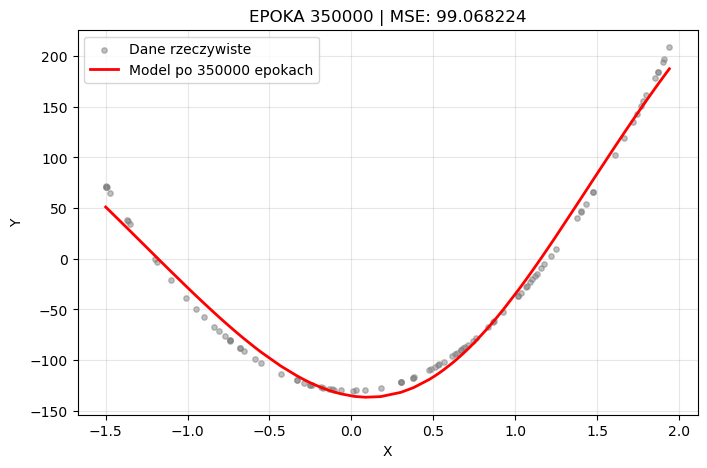

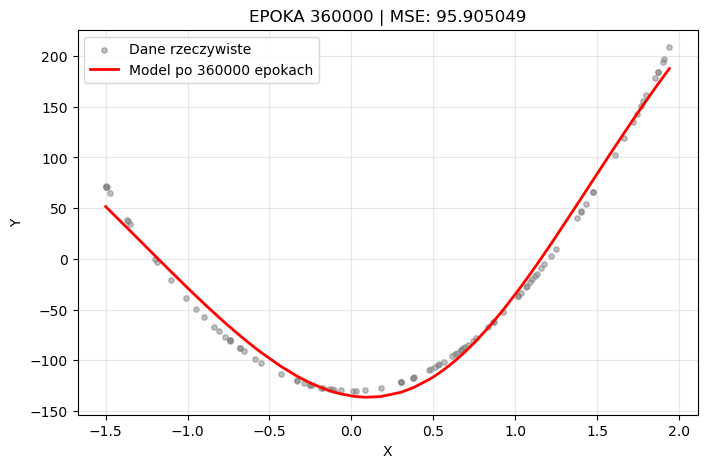

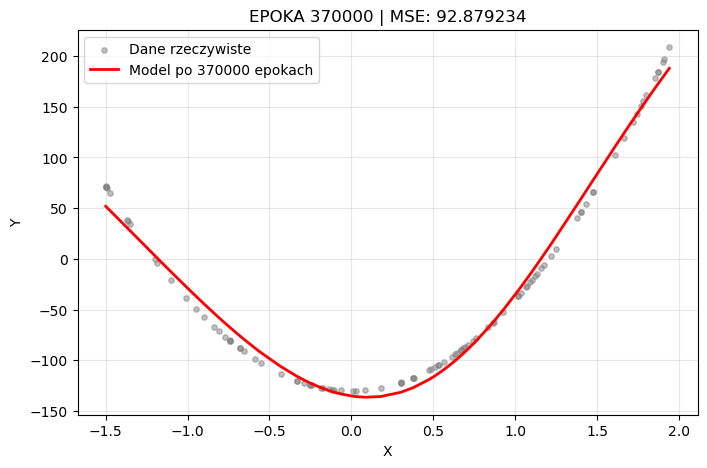

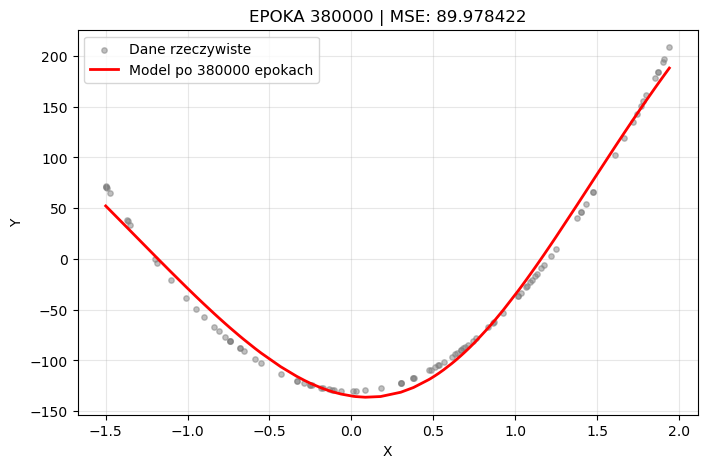

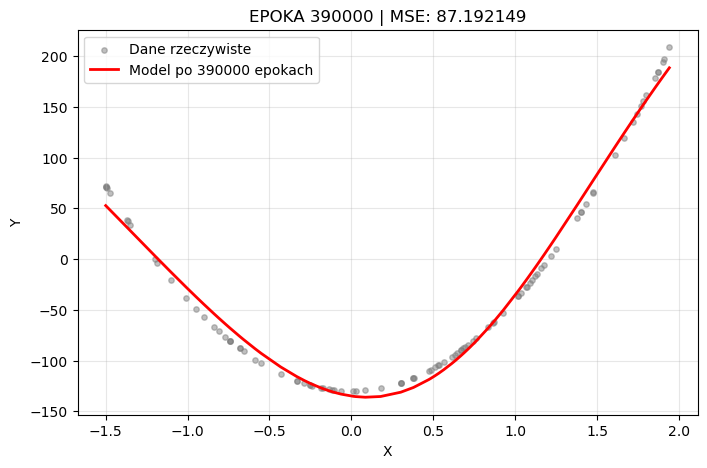

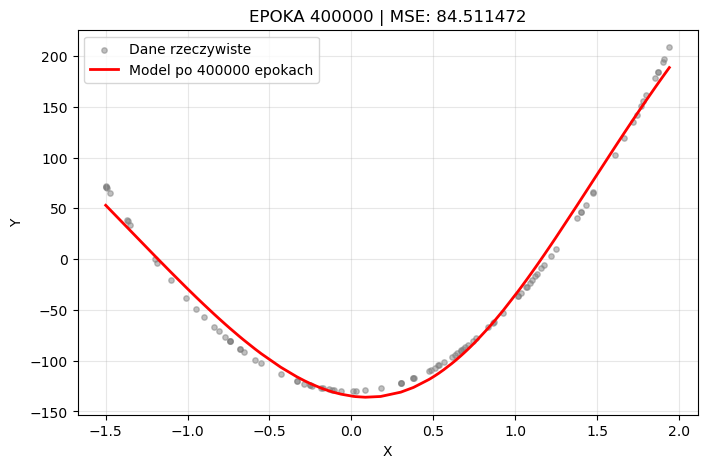

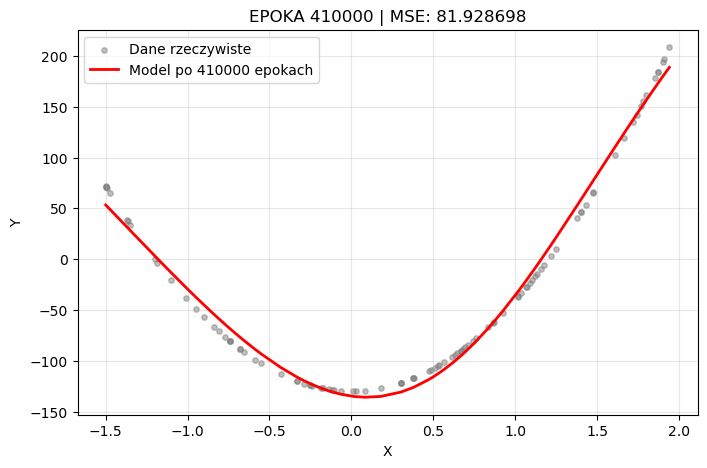

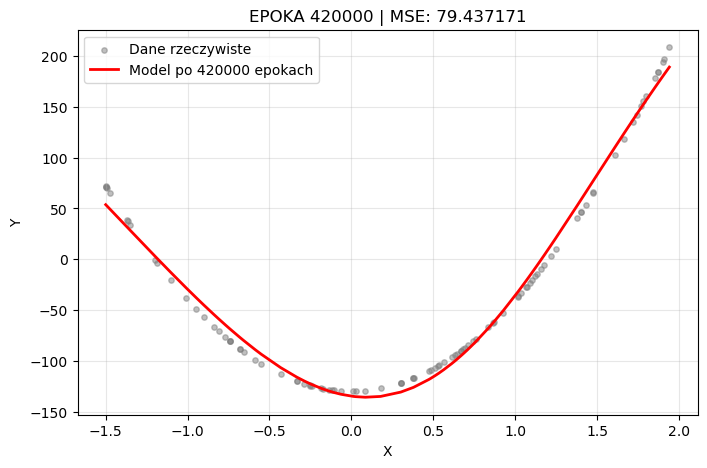

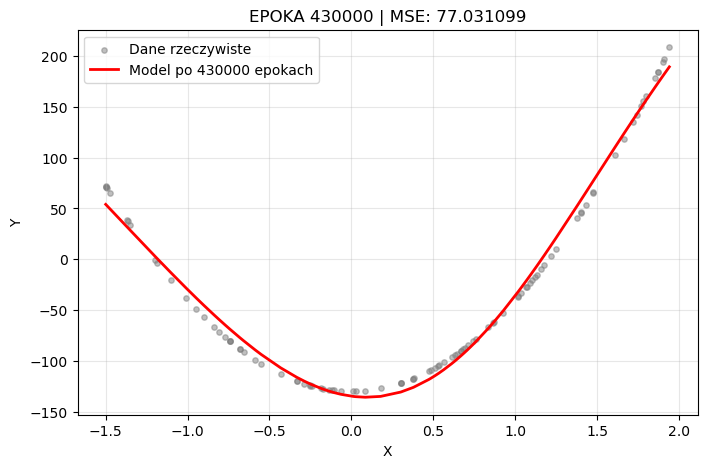

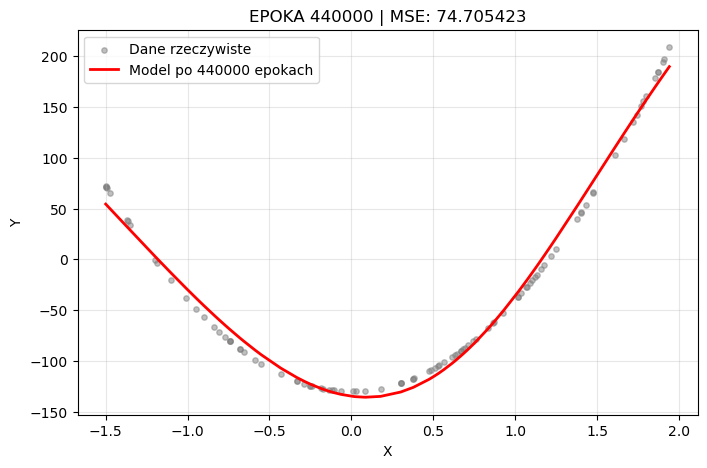

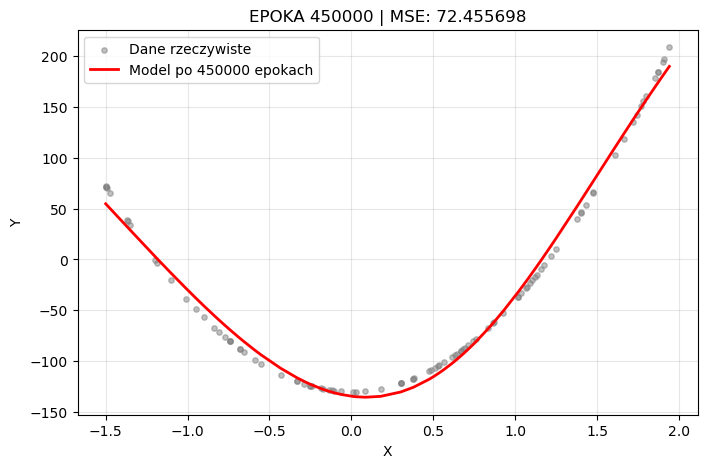

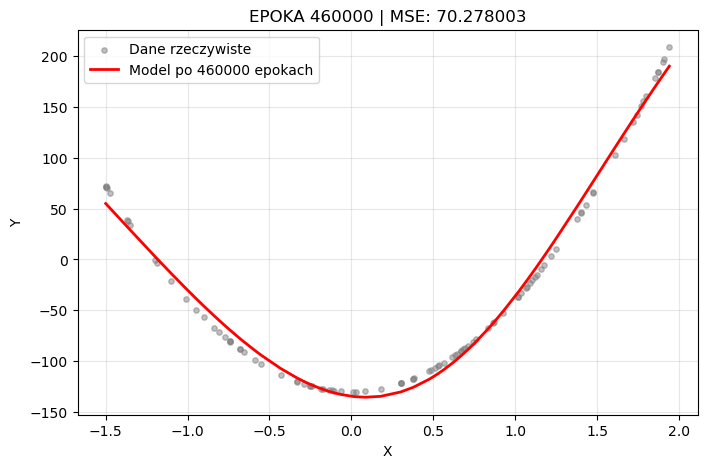

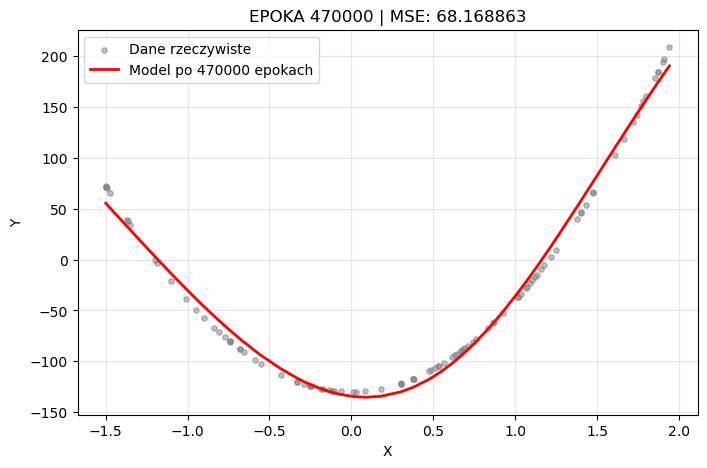

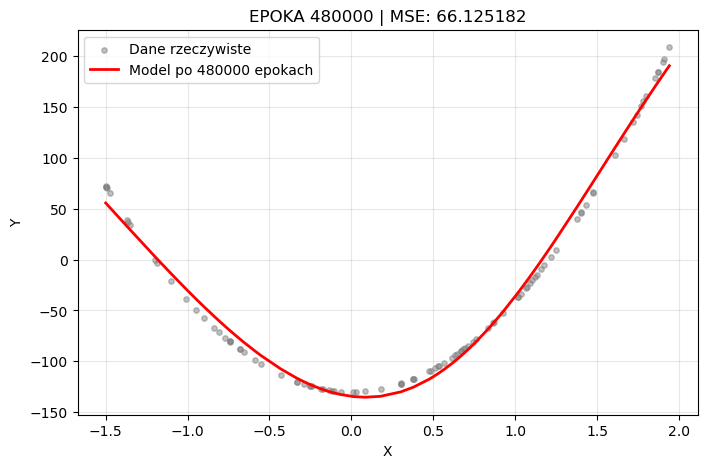

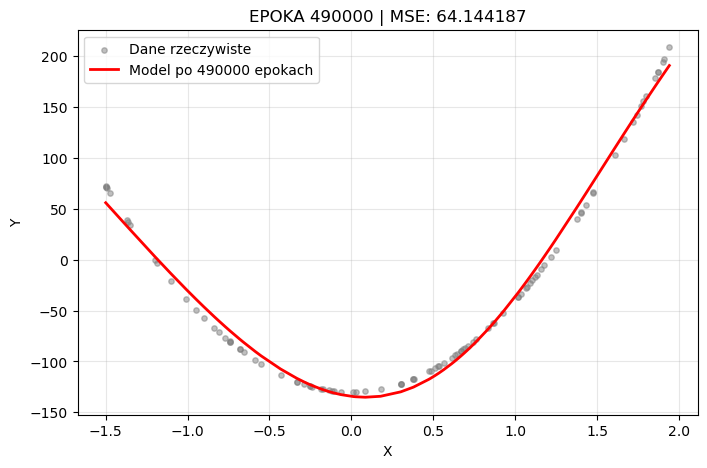

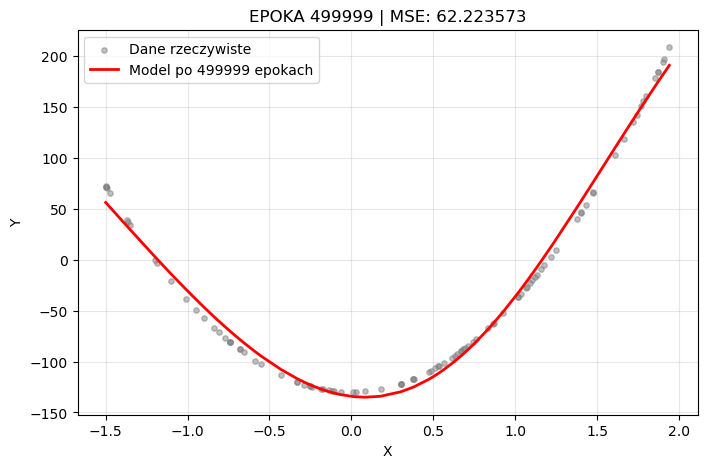

Wagi:
[array([[ 1.96732954, -3.11575878, -2.69577328, -0.4692838 , -1.13065677]]), array([[ 0.07223313, -2.0484948 ,  0.70186088,  0.52227691, -1.5926151 ],
       [ 0.4623257 ,  1.43186966,  0.72863814,  0.19464357,  3.96291338],
       [ 0.07295958,  1.99362358,  0.519567  ,  0.3578256 ,  2.57282589],
       [-0.20089217, -0.79535513, -0.39014811, -0.06414353,  1.0285078 ],
       [ 0.44154871, -0.09750247,  0.70212294,  0.96454342,  0.69327785]]), array([[ 0.43131767],
       [ 2.7187897 ],
       [ 0.44080511],
       [ 1.16594553],
       [-3.39114766]])]
Bias:
[array([[-0.36626873,  1.69584516,  0.36049813,  0.88706054, -0.71145433]]), array([[-0.10394033, -1.36157168, -0.08225801,  0.59435841, -0.19016509]]), array([[1.30503599]])]


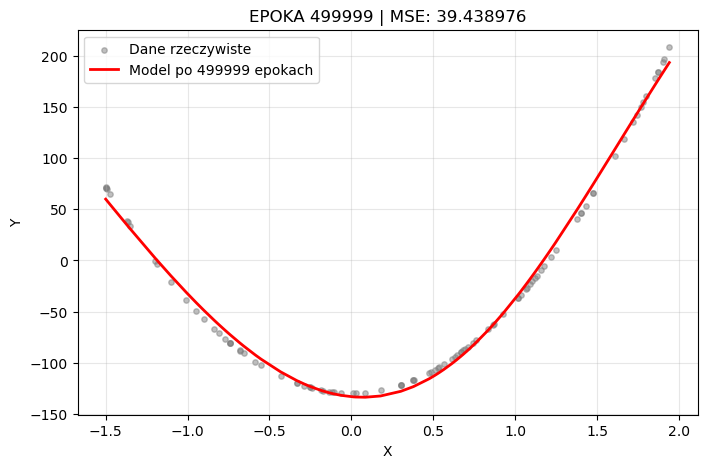

Wagi:
[array([[ 2.0703029 , -2.94773738, -2.80803931, -0.47473685, -1.13160637]]), array([[ 0.07691587, -2.19100534,  0.70953099,  0.53518874, -1.62081407],
       [ 0.45177872,  1.44174344,  0.71785035,  0.17156974,  3.99845408],
       [ 0.07802704,  2.11697775,  0.52136734,  0.36216324,  2.58078631],
       [-0.1984075 , -0.82376058, -0.38744696, -0.06017627,  1.03864104],
       [ 0.44356273, -0.06192689,  0.70304591,  0.96638037,  0.70586797]]), array([[ 0.45221705],
       [ 2.84152698],
       [ 0.46749816],
       [ 1.2120993 ],
       [-3.47513435]])]
Bias:
[array([[-0.31144212,  1.77511538,  0.25228226,  0.90093599, -0.70717148]]), array([[-0.09788515, -1.43108794, -0.07525124,  0.60598061, -0.19747263]]), array([[1.36469902]])]


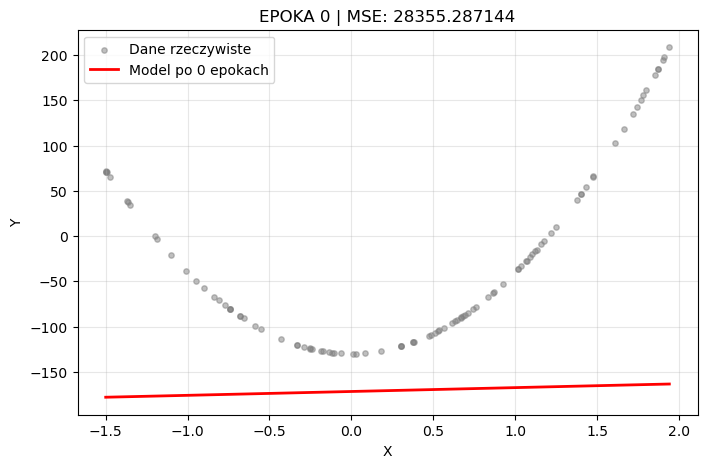

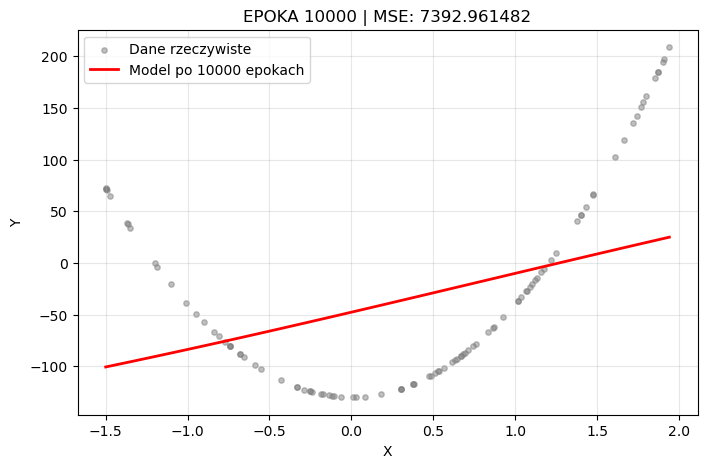

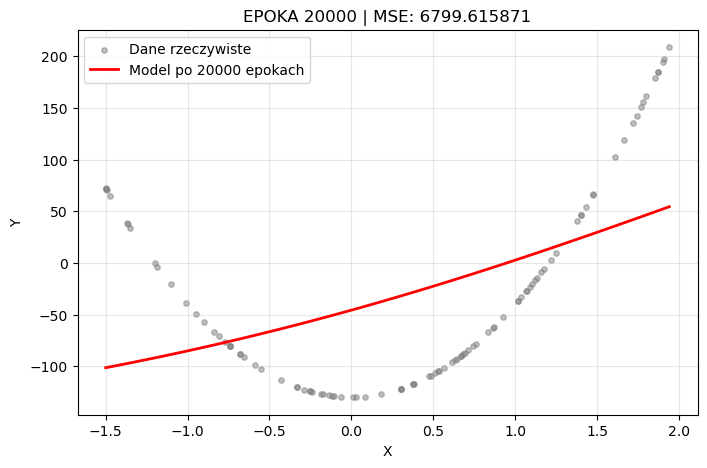

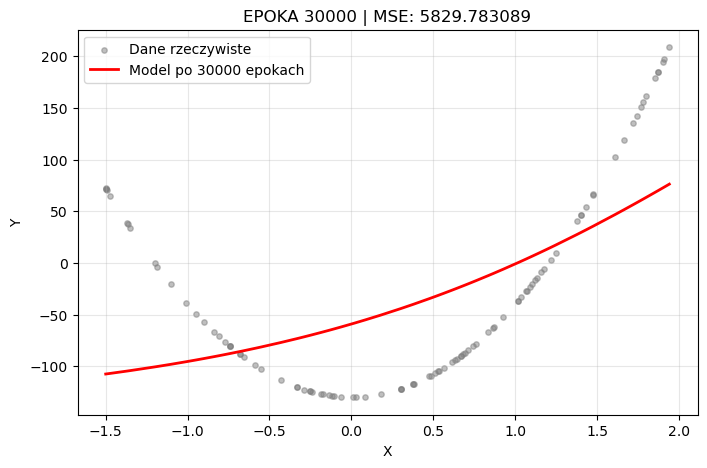

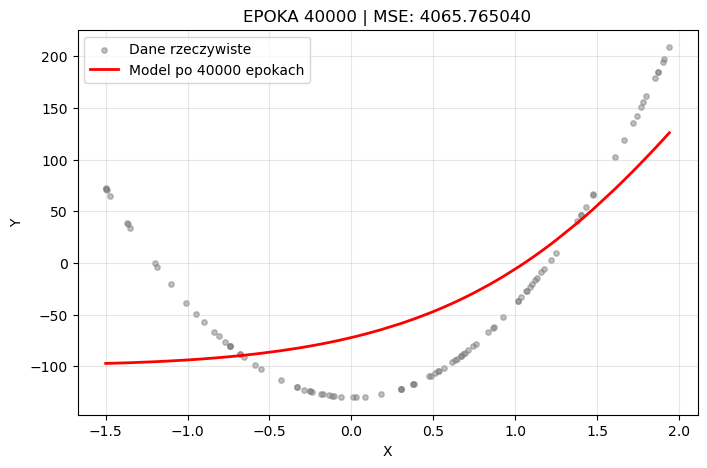

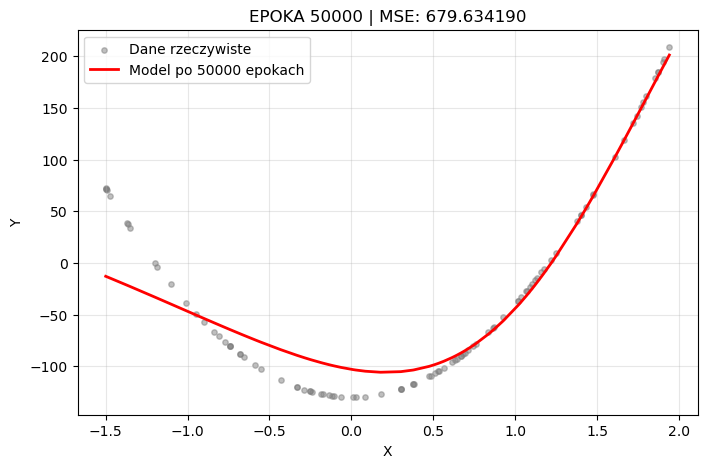

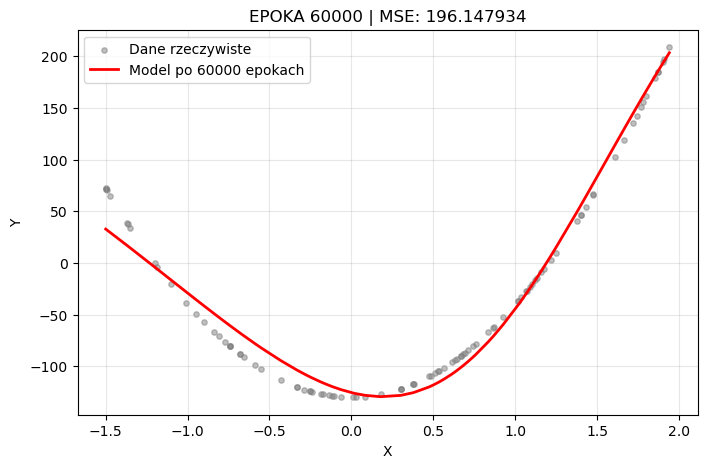

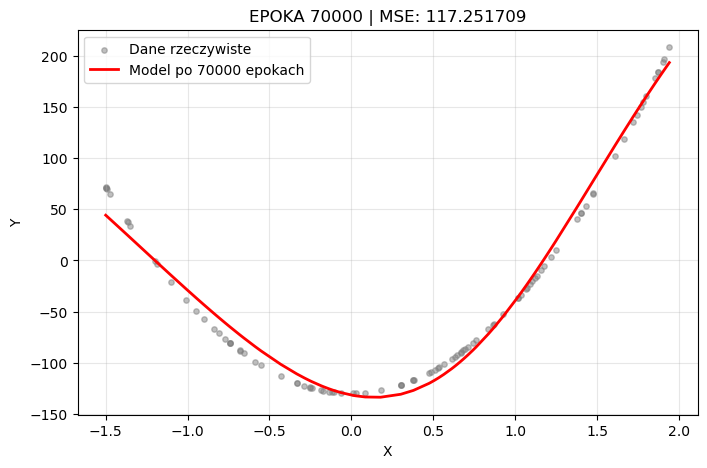

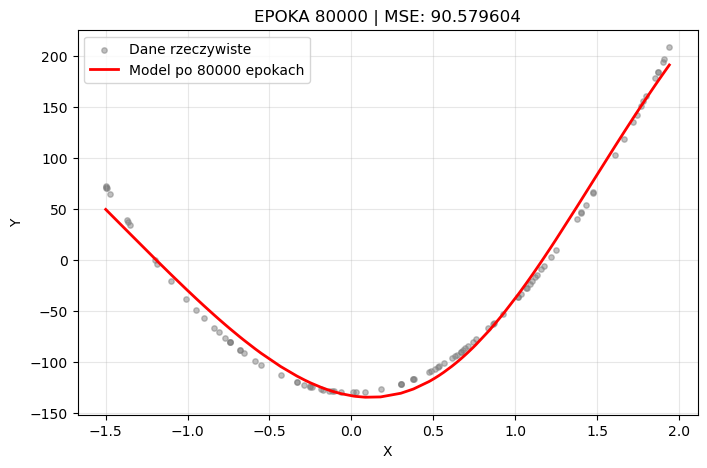

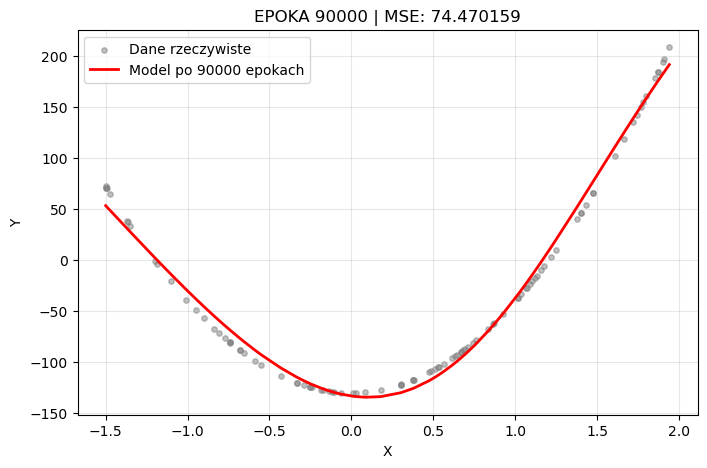

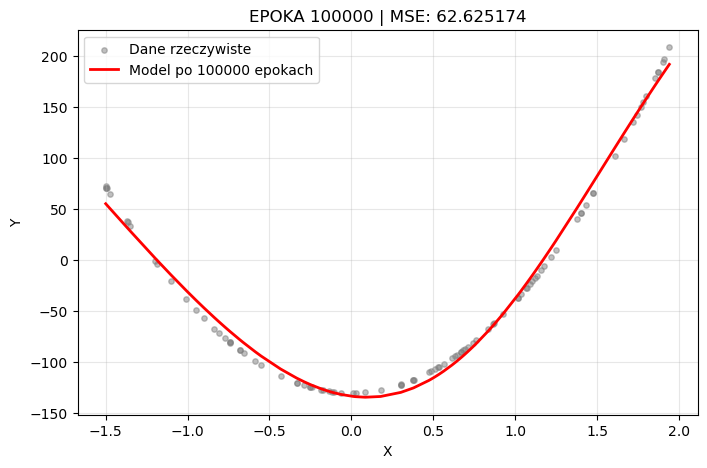

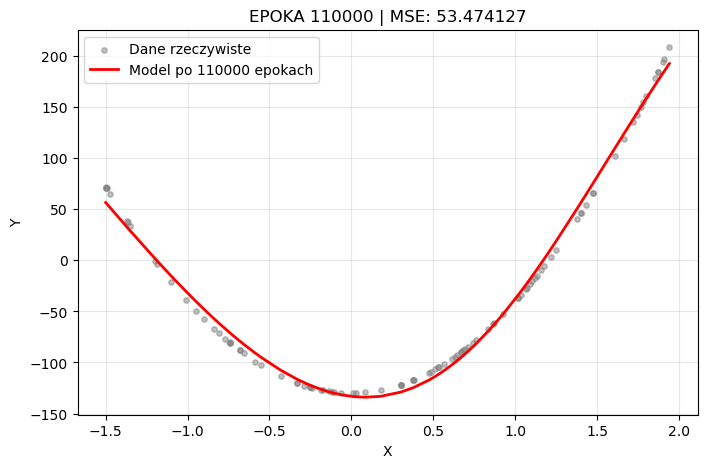

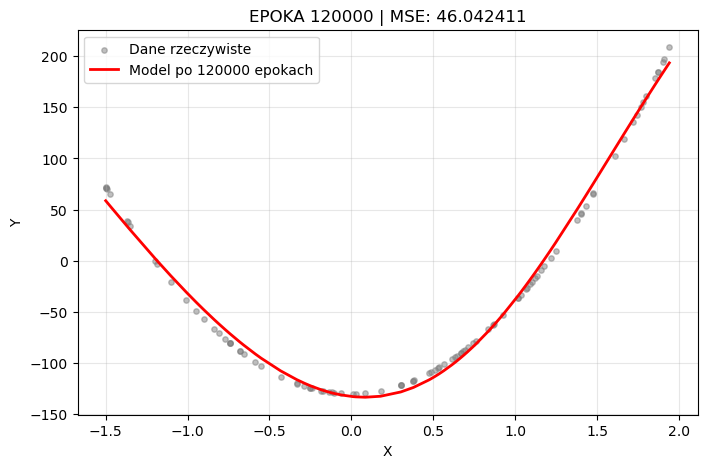

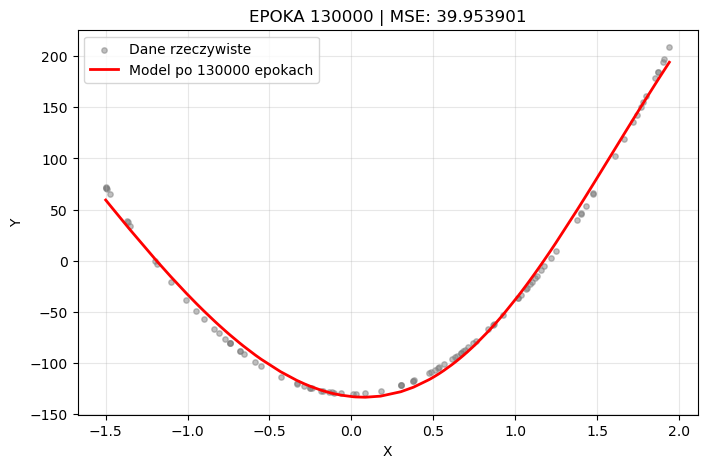

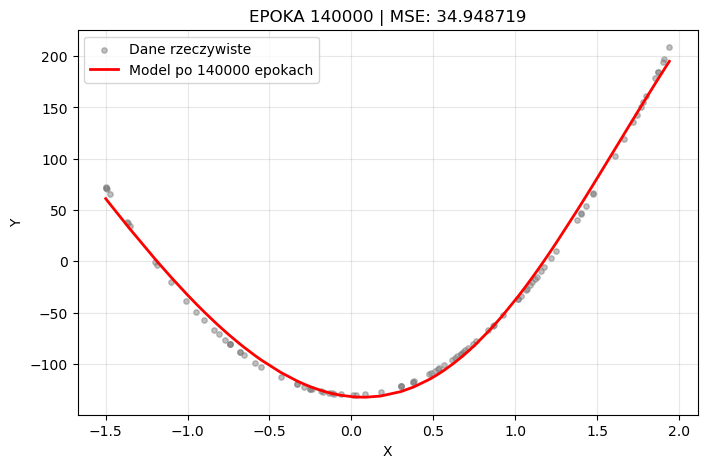

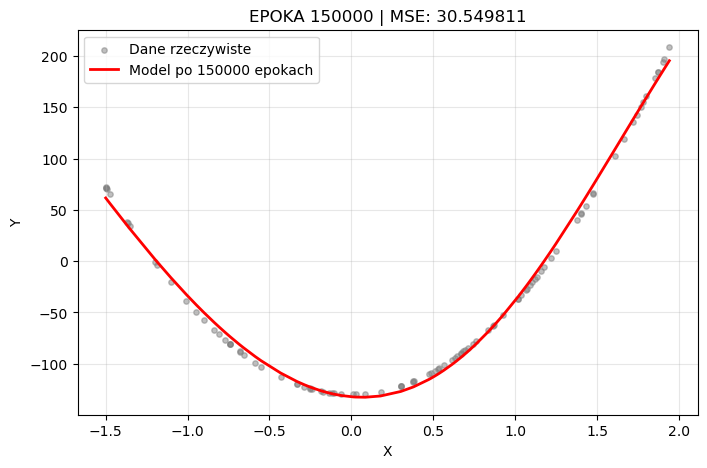

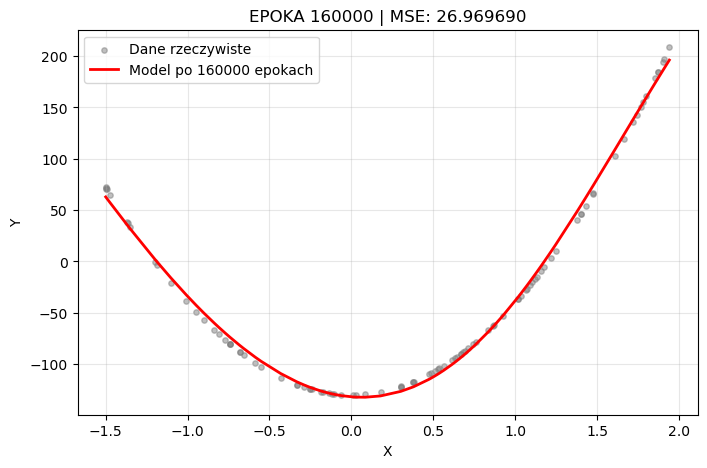

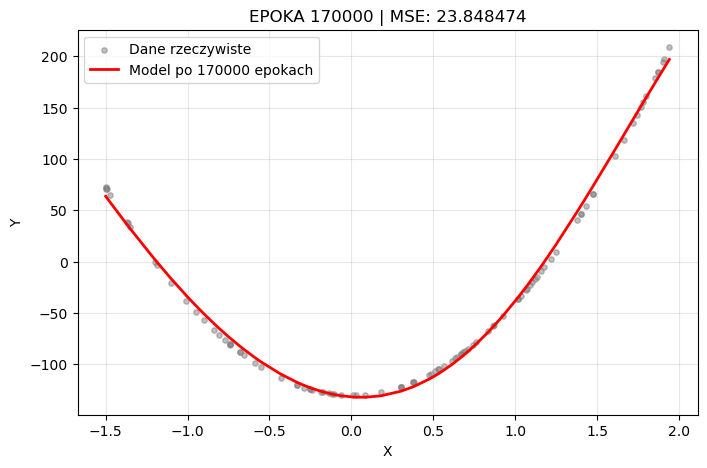

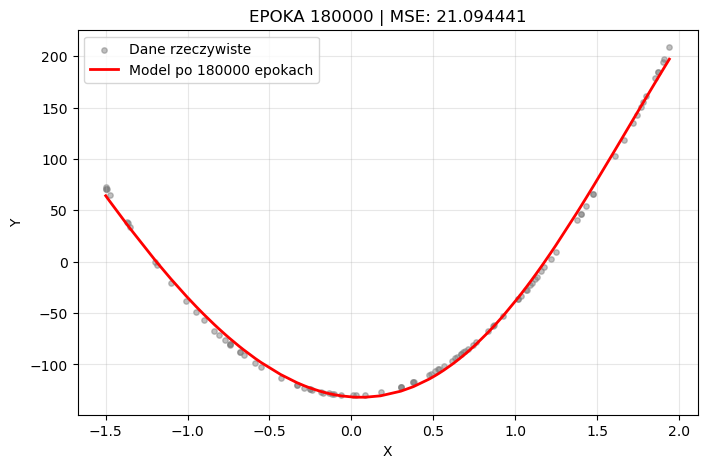

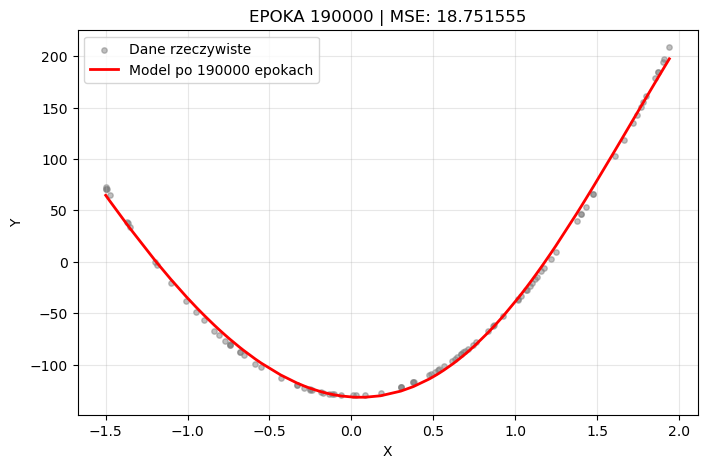

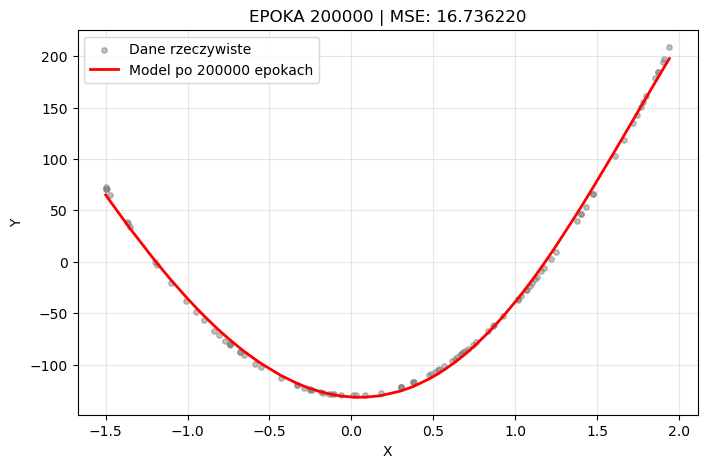

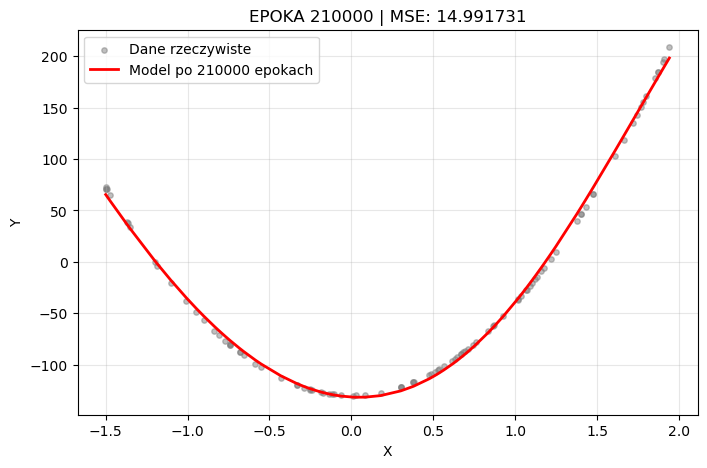

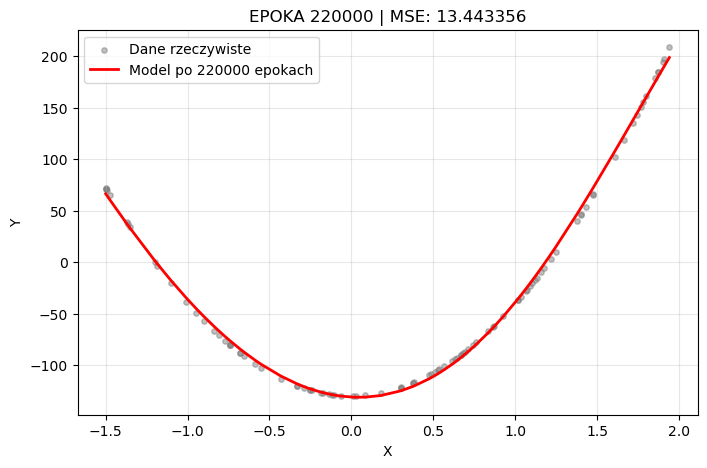

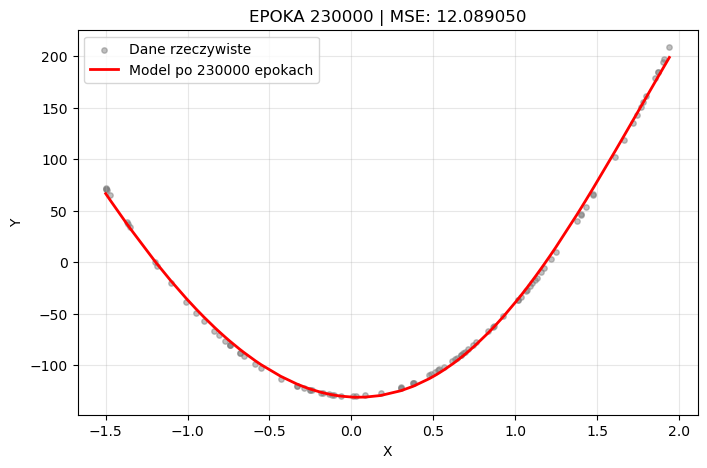

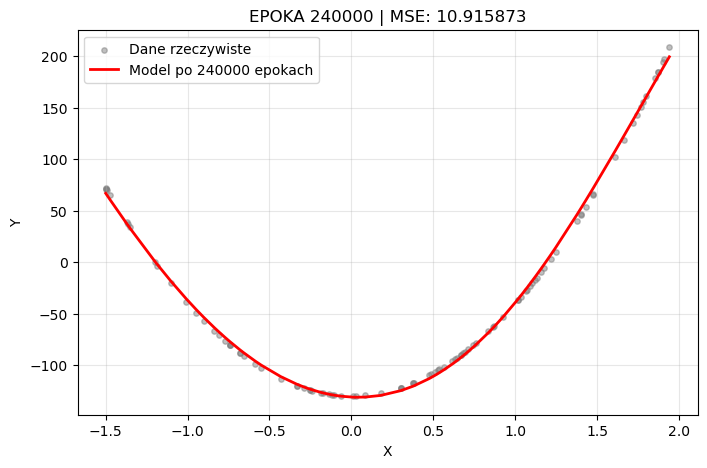

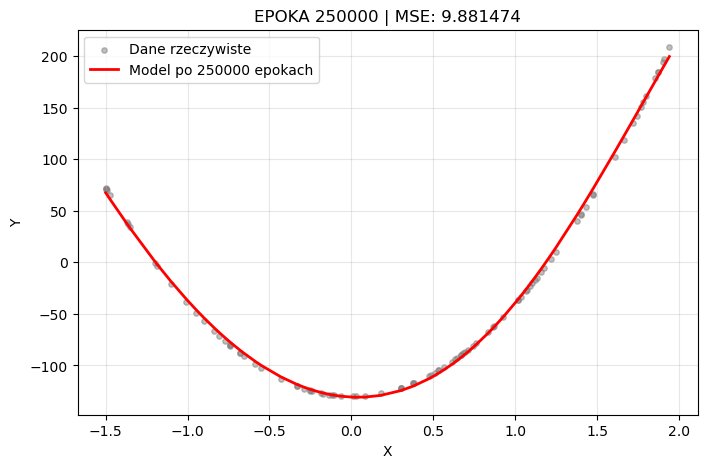

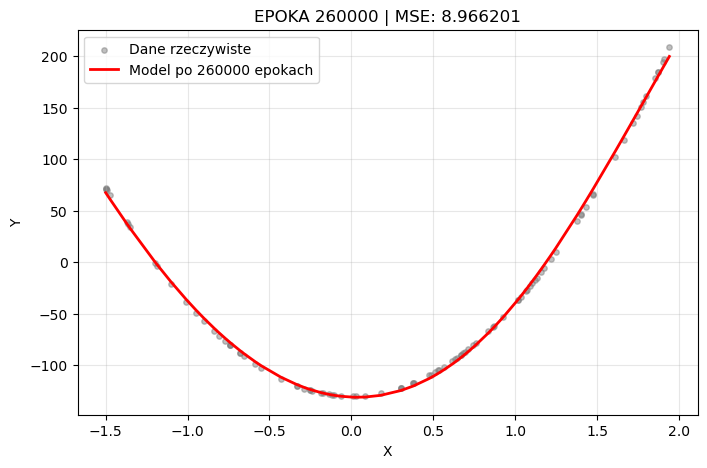

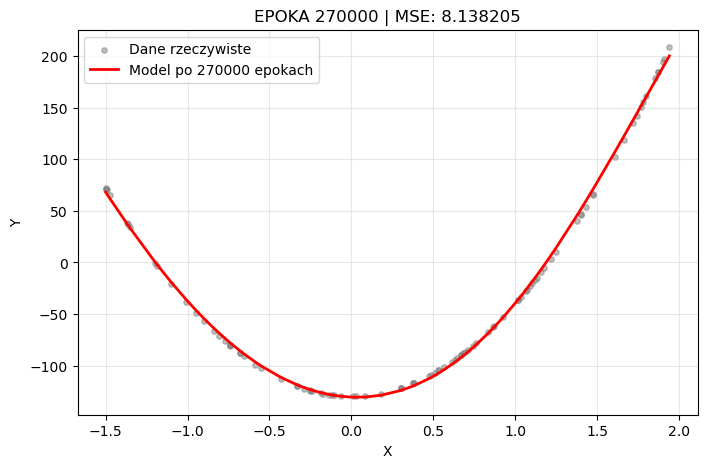

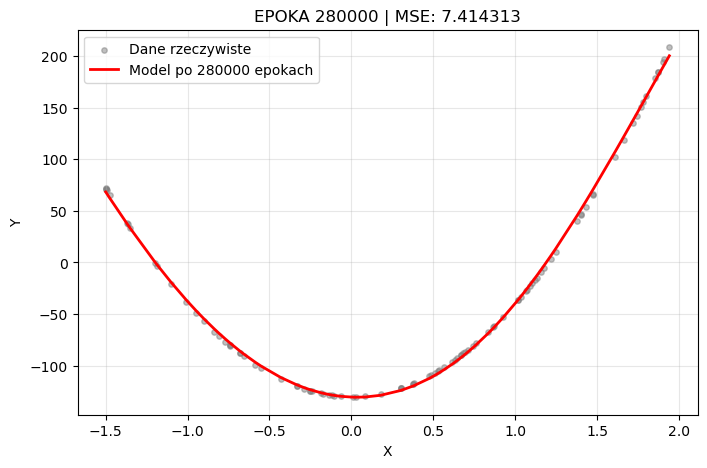

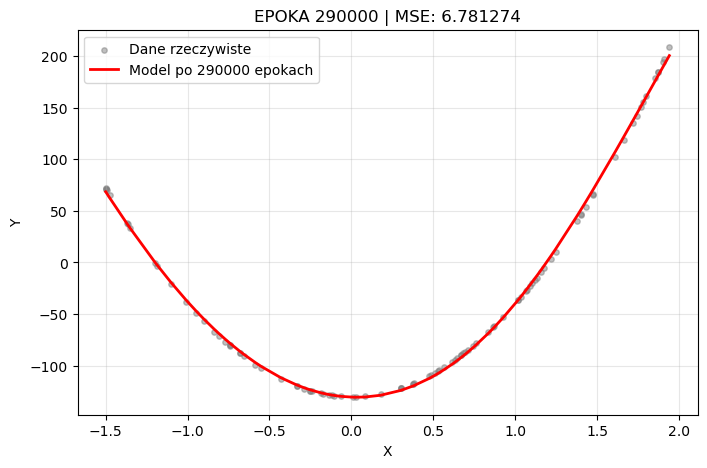

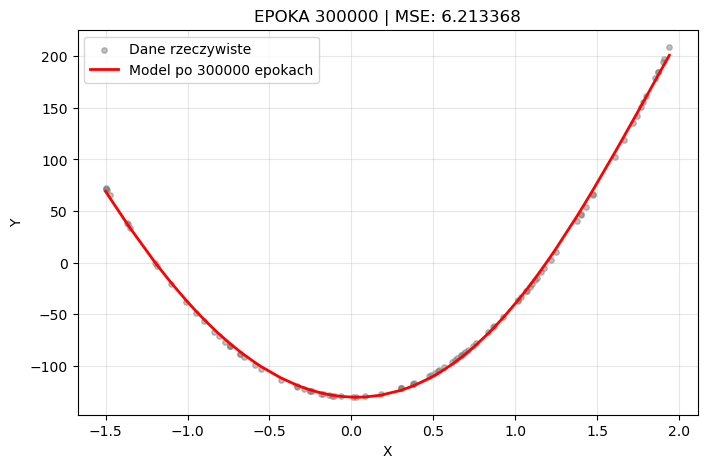

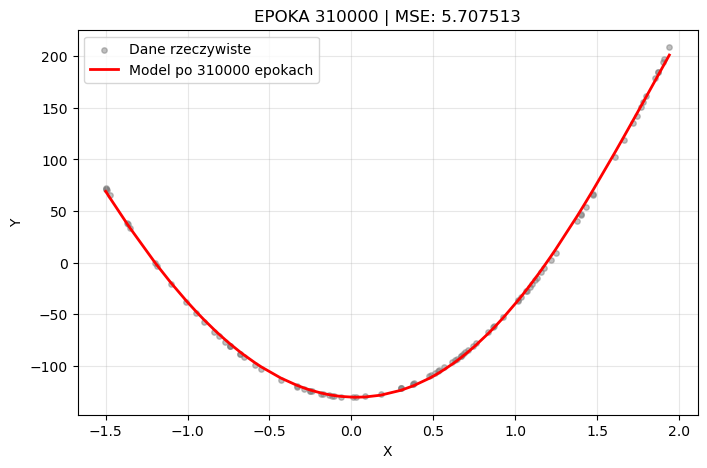

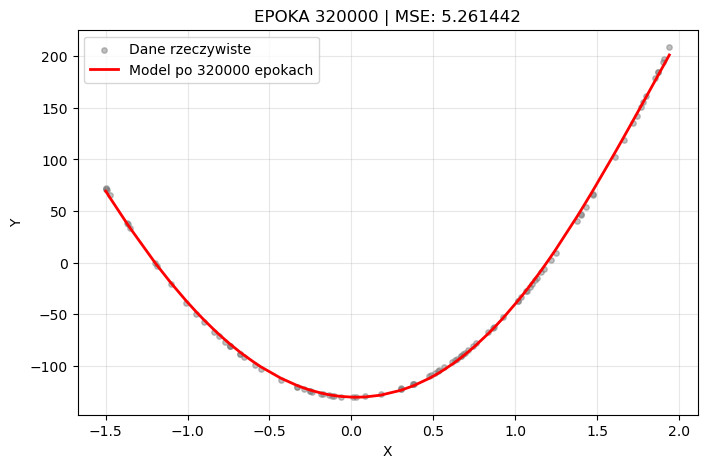

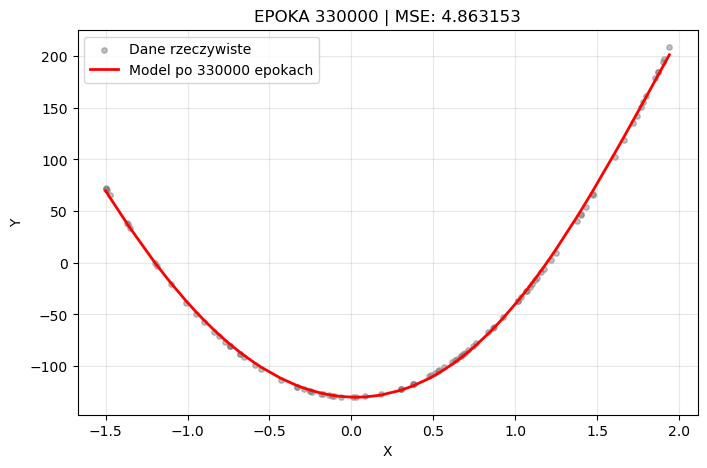

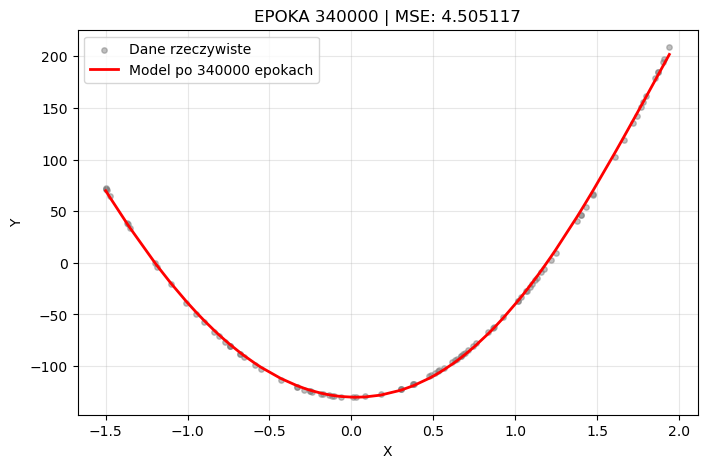

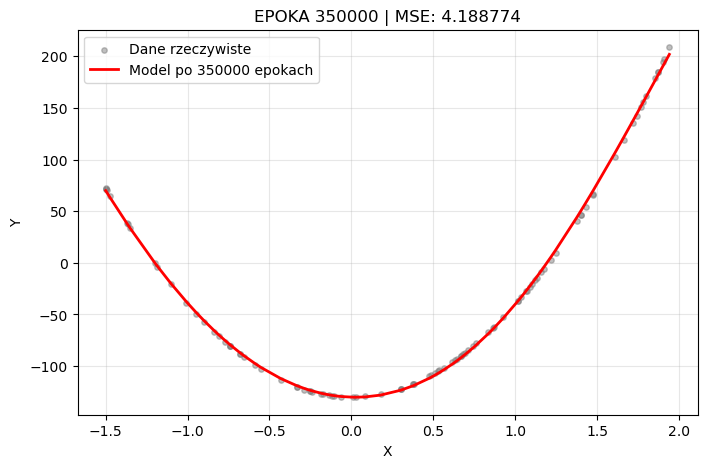

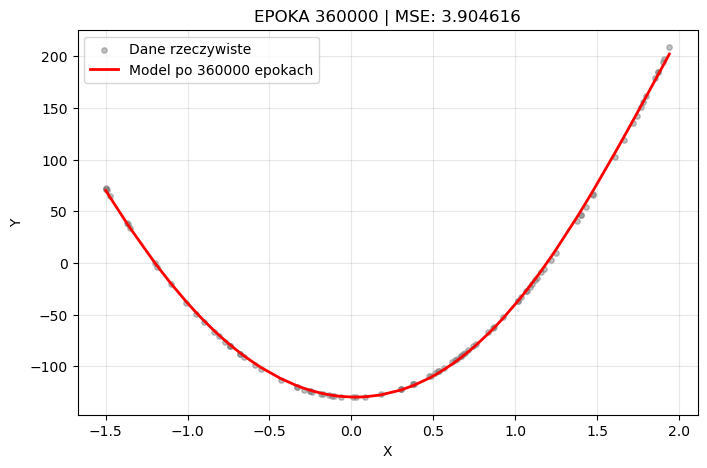

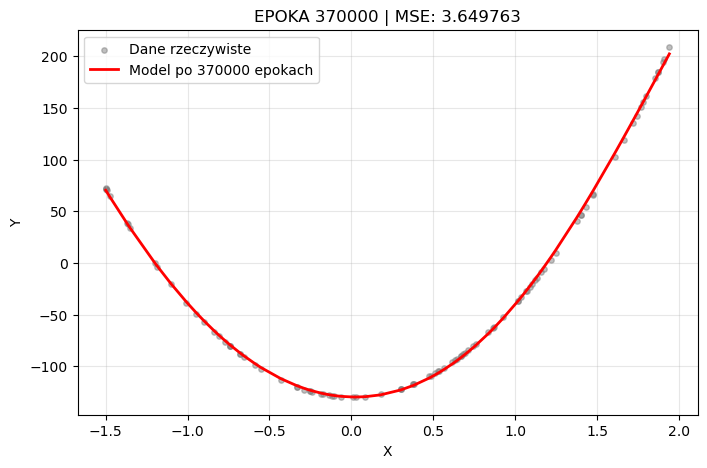

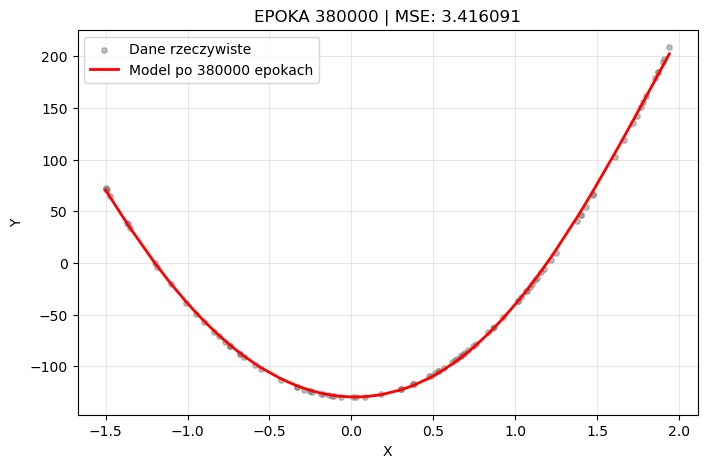

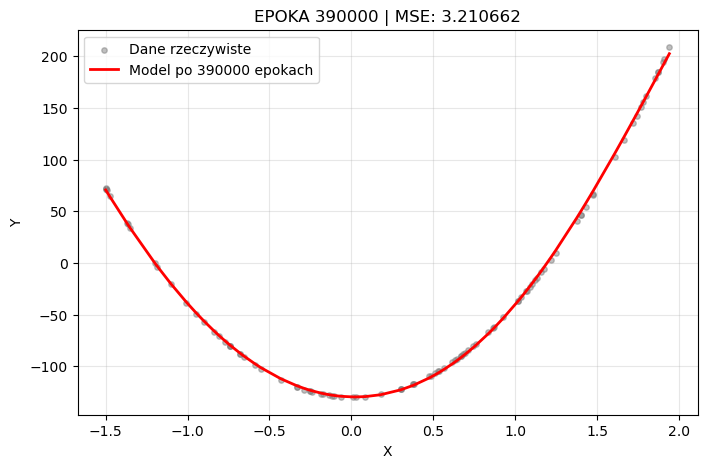

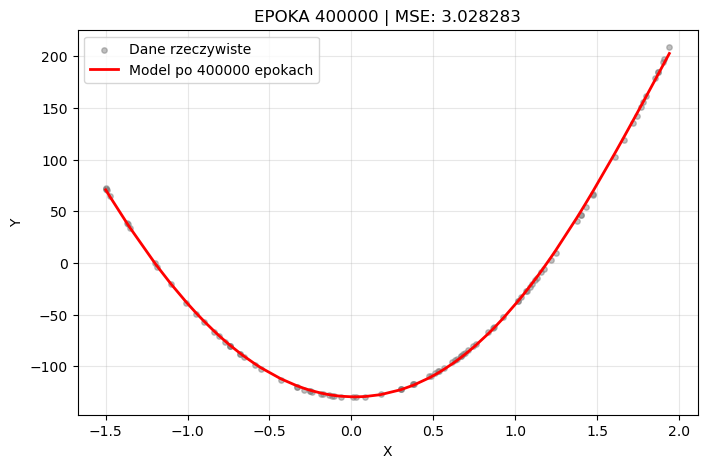

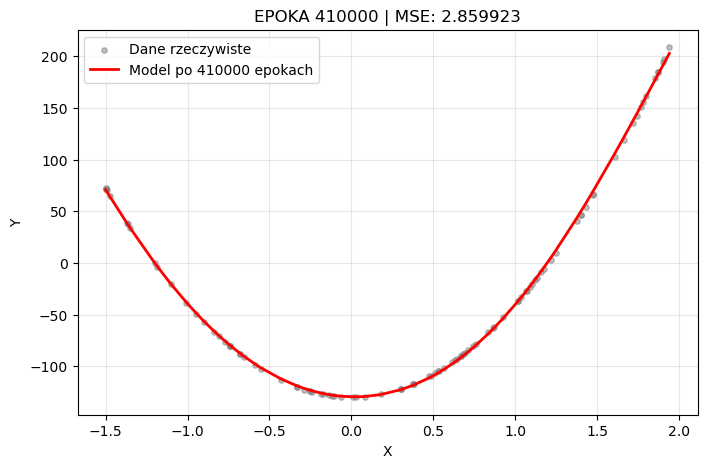

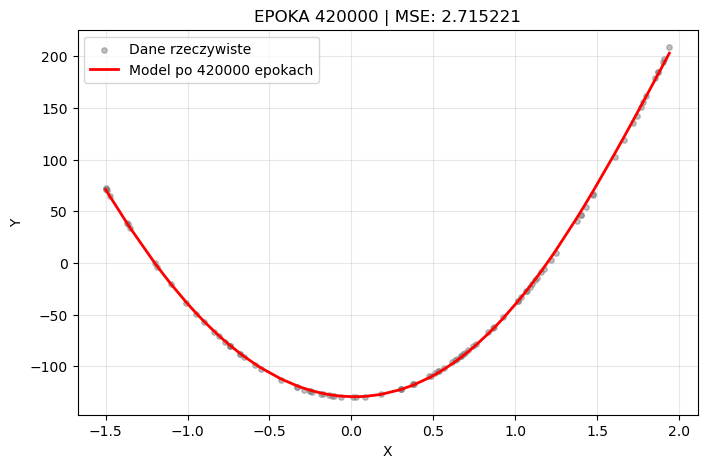

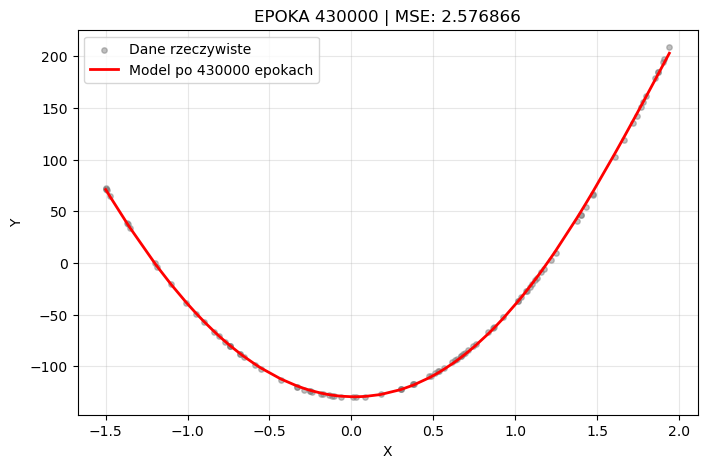

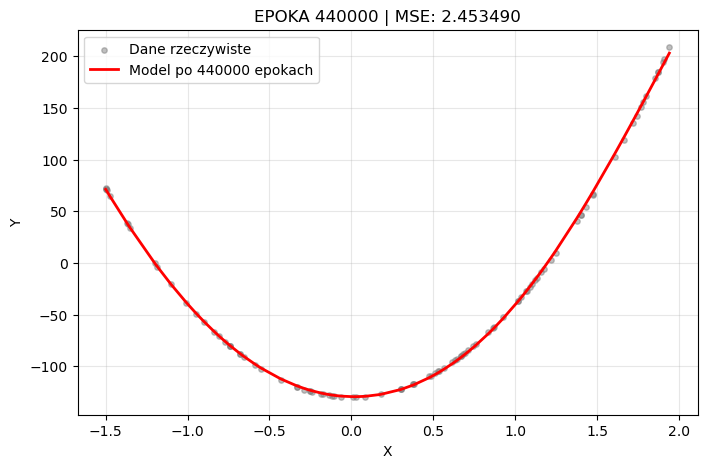

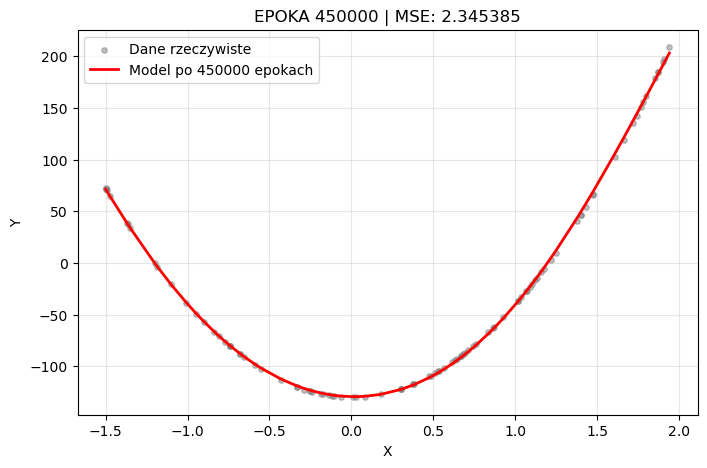

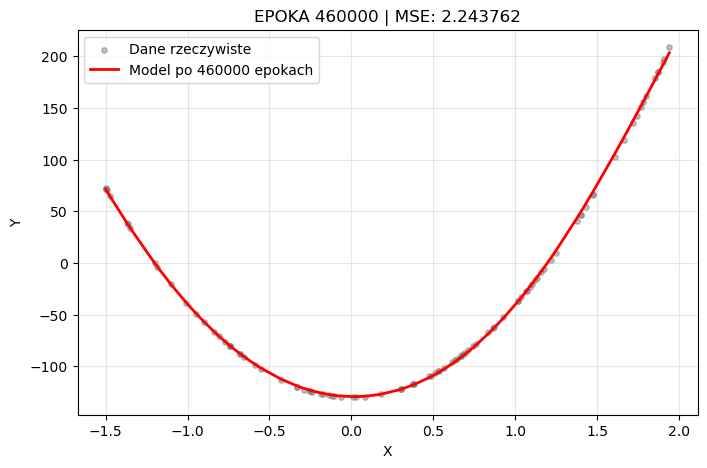

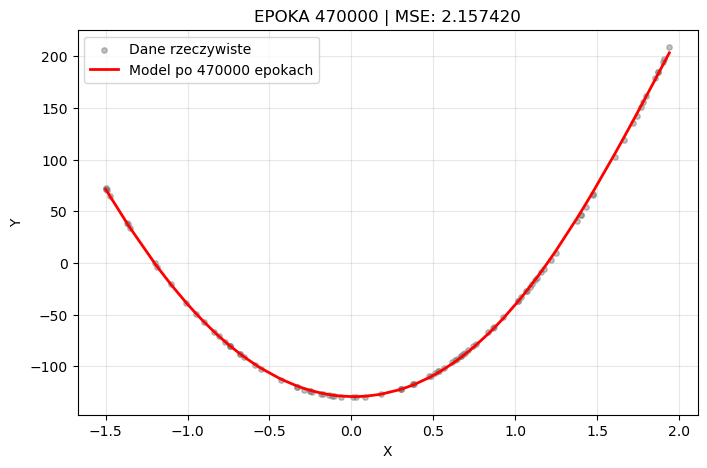

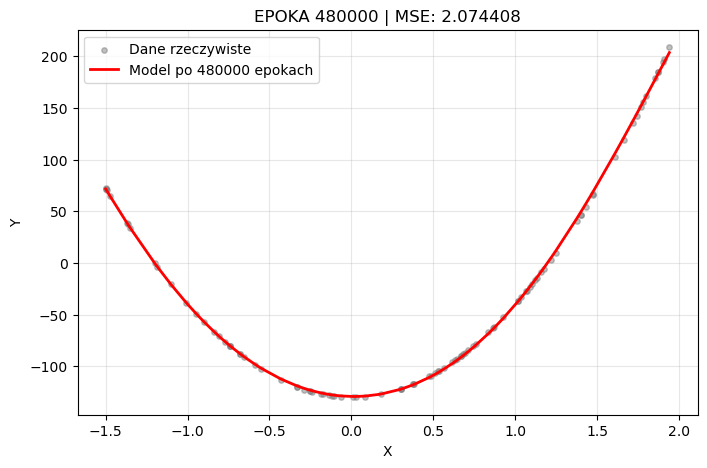

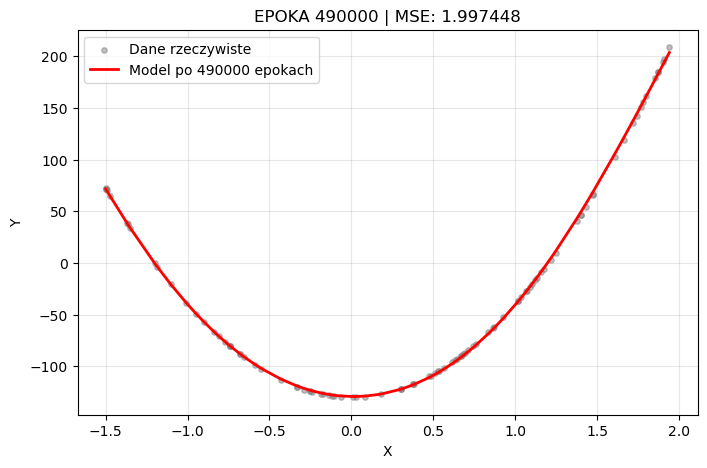

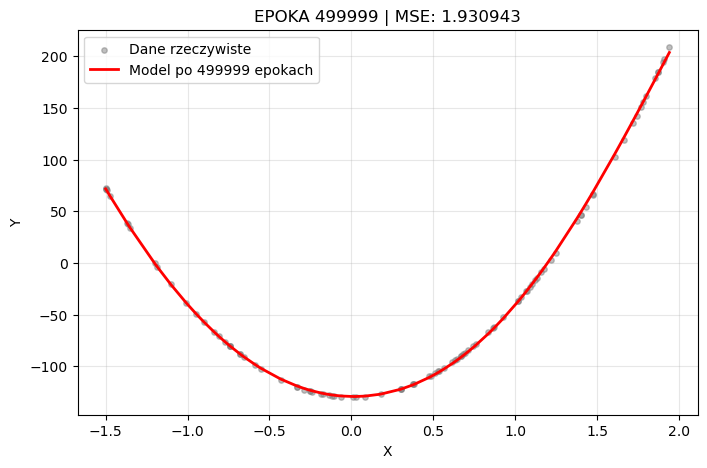

Wagi:
[array([[-2.62318673, -2.50768979,  2.36037095, -1.77934376,  2.62573324]]), array([[ 0.11289242, -2.92436087,  1.75319334, -0.14660259,  1.01281467],
       [ 0.44226275, -2.75099181,  1.12354191,  0.321082  ,  1.05385201],
       [ 0.7038287 ,  1.27737164,  1.12468317,  0.57678771, -2.22766442],
       [ 0.42365889, -1.32696227, -0.41003469,  0.54702239,  1.459051  ],
       [-0.53147057,  1.58070313, -0.68929223, -0.5005354 , -2.54259382]]), array([[ 0.28106391],
       [ 3.21943329],
       [-0.95520305],
       [ 0.32015631],
       [ 3.17360678]])]
Bias:
[array([[ 1.98253802,  1.57525062, -0.04475736,  0.02321322, -0.04138253]]), array([[ 0.59571024, -1.19355418,  0.26325407,  0.37876512, -1.11910682]]), array([[0.14619709]])]


KeyboardInterrupt: 

In [51]:




start = time.time()
mlp_ss_full.train(x_ss, y_ss, epochs=500000, lr=0.01, batch_size=len(x_ss), verbose=True)
time_full = time.time() - start


start = time.time()
mlp_ss_batch.train(x_ss, y_ss, epochs=500000, lr=0.01, batch_size=32, verbose=True)
time_batch = time.time() - start


print("Full batch time:", time_full)
print("Mini batch time:", time_batch)

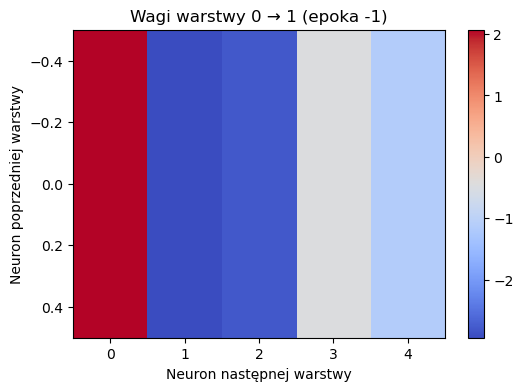

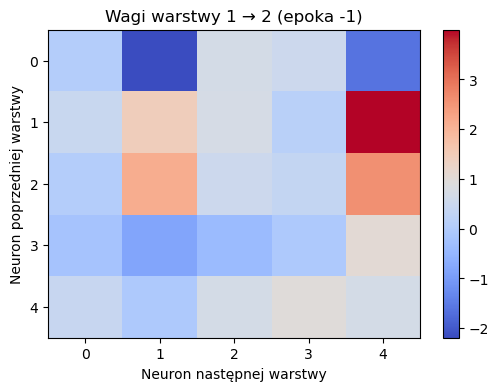

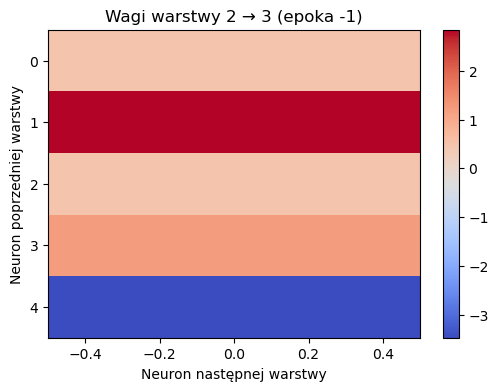

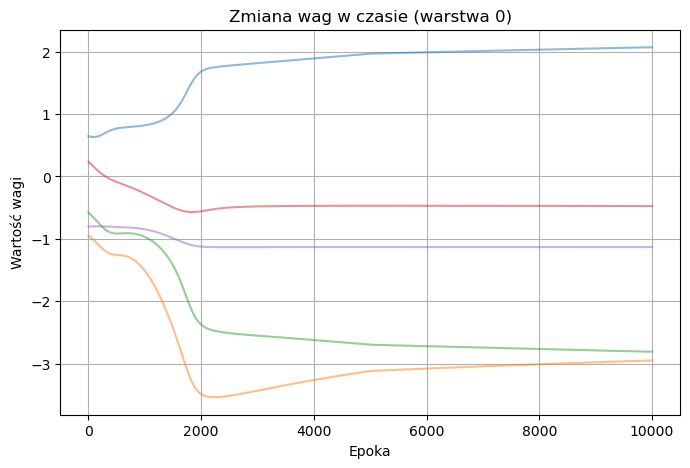

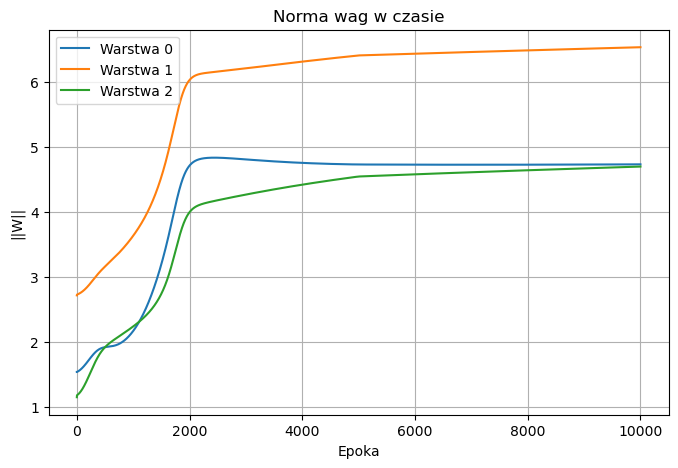

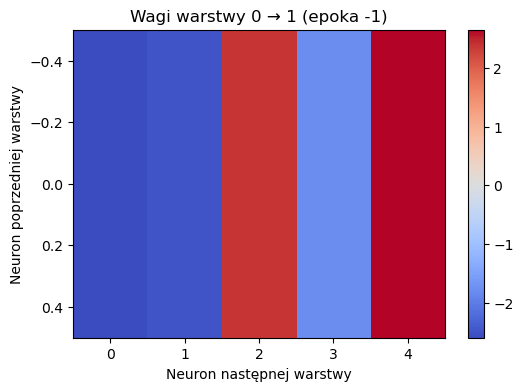

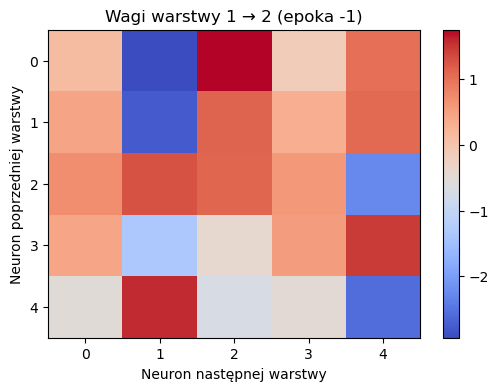

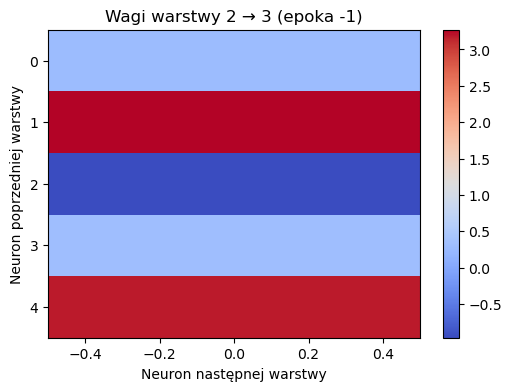

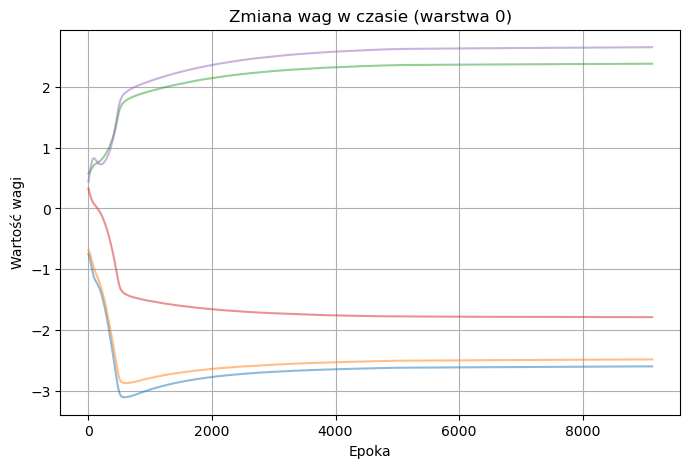

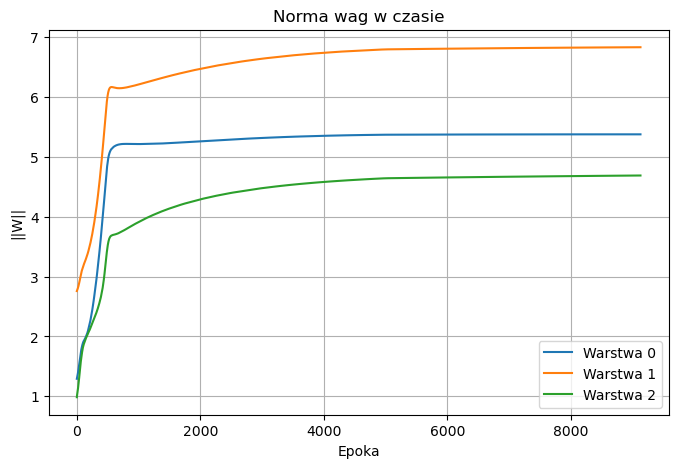

In [52]:

mlp_ss_full.plot_weight_evolution()
mlp_ss_full.plot_weight_norms()


mlp_ss_batch.plot_weight_evolution()
mlp_ss_batch.plot_weight_norms()

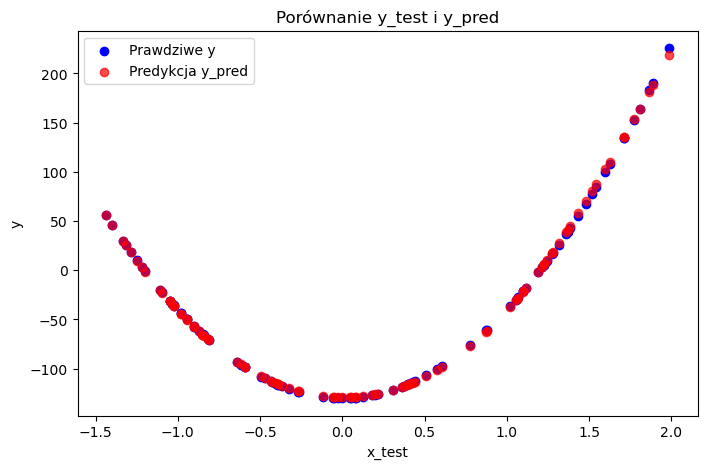

MSE dla modelu 1_5_5_1 trenowanym na batchach: 1.554192


In [55]:
y_pred = mlp_ss_batch.calc(test_x_ss)
plt.figure(figsize=(8,5))
plt.scatter(test_x_ss, test_y_ss, color='blue', label='Prawdziwe y')
plt.scatter(test_x_ss, y_pred, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(test_y_ss, y_pred)
print(f"MSE dla modelu 1_5_5_1 trenowanym na batchach: {loss:.6f}")

In [14]:
ss_w_full = [
    np.array([[-2.62318673, -2.50768979,  2.36037095, -1.77934376,  2.62573324]]),

    np.array([
        [ 0.11289242, -2.92436087,  1.75319334, -0.14660259,  1.01281467],
        [ 0.44226275, -2.75099181,  1.12354191,  0.321082  ,  1.05385201],
        [ 0.7038287 ,  1.27737164,  1.12468317,  0.57678771, -2.22766442],
        [ 0.42365889, -1.32696227, -0.41003469,  0.54702239,  1.459051  ],
        [-0.53147057,  1.58070313, -0.68929223, -0.5005354 , -2.54259382]
    ]),

    np.array([
        [ 0.28106391],
        [ 3.21943329],
        [-0.95520305],
        [ 0.32015631],
        [ 3.17360678]
    ])
]


ss_biases_w_full = [
    np.array([[ 1.98253802,  1.57525062, -0.04475736,  0.02321322, -0.04138253]]),

    np.array([[ 0.59571024, -1.19355418,  0.26325407,  0.37876512, -1.11910682]]),

    np.array([[0.14619709]])
]

# zapisanie najlepszyc wag
x_min, x_max, y_min, y_max = min_max_vals(x_ss, y_ss)
mlp_ss_full = MLP(
    layer_num=[1, 5, 5, 1],
    act_func=sigmoid,
    grad_act_func=grad_sigmoid,
    w=ss_w_full,
    biases_w=ss_biases_w_full,
    x_min=x_min,
    x_max=x_max,
    y_min=y_min,
    y_max=y_max
)

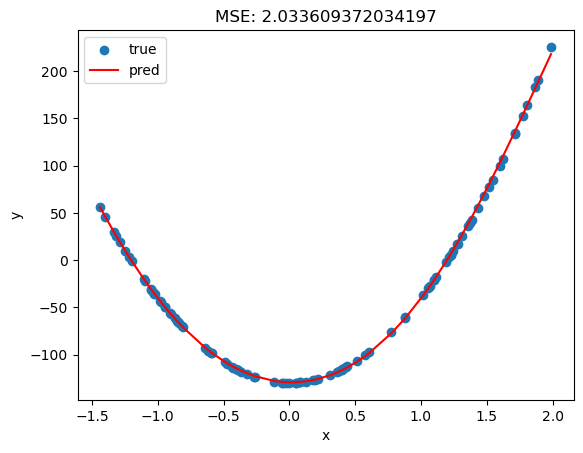

In [28]:
plot_model_predictions(mlp_ss_full, test_x_ss, test_y_ss) # sprawdzenie na testowych

In [67]:
# steps small

data_steps_small = csv.reader(open('mio1/regression/steps-small-training.csv'))
test_data_steps_small = csv.reader(open('mio1/regression/steps-small-test.csv'))
x_sts, test_x_sts, y_sts, test_y_sts = data_to_matrix(data_steps_small, test_data_steps_small)

np.random.seed(52)

layer_num = [1,20,20,1]
mlp_sts_full = MLP(layer_num, sigmoid, grad_sigmoid)
mlp_sts_batch = MLP(layer_num, sigmoid, grad_sigmoid)



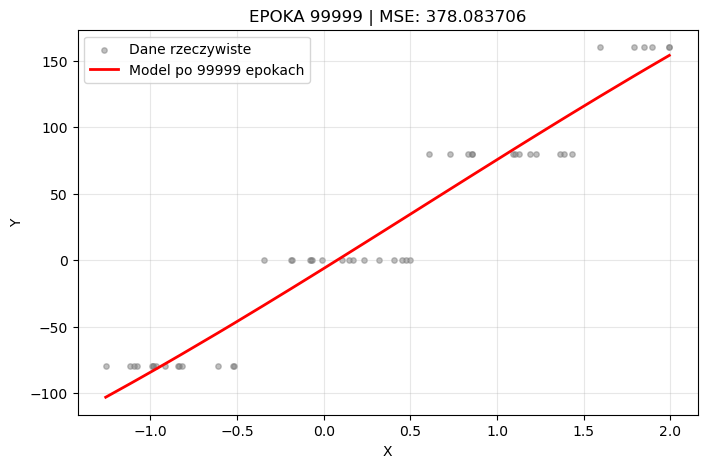

Wagi:
[array([[ 0.44518671, -1.36410269, -0.46870491,  0.25952029, -0.65187769,
         0.53448958, -0.95094792,  1.04042948,  1.02637948,  0.03890824,
         0.59181796,  0.61453986,  0.27880608, -0.3570119 ,  0.57601021,
        -0.31590566,  1.06552606,  0.03109986, -0.19608276,  0.75477529]]), array([[-2.47075415e-01, -7.85171977e-01, -3.21655311e-01,
        -1.41497958e-01,  4.72967926e-01,  2.12610994e-01,
        -5.62177091e-01,  6.64683367e-01,  6.33239716e-01,
        -2.05656416e-01,  2.61624491e-02,  5.54740433e-01,
        -3.90671421e-02,  5.18399506e-01, -9.17176543e-01,
         9.70468358e-04, -1.31768096e-01, -4.40040169e-01,
         7.20357168e-01, -9.66343033e-01],
       [-1.04592757e-01, -1.00742881e+00, -1.61970019e-01,
         6.10286179e-01, -3.69173373e-01,  1.21861406e+00,
        -7.92526612e-01, -8.02189860e-01,  8.23351328e-01,
         4.44736804e-01,  4.08161438e-01,  1.31574761e-01,
         6.09309193e-02,  8.76920476e-01, -5.44323323e-01,
      

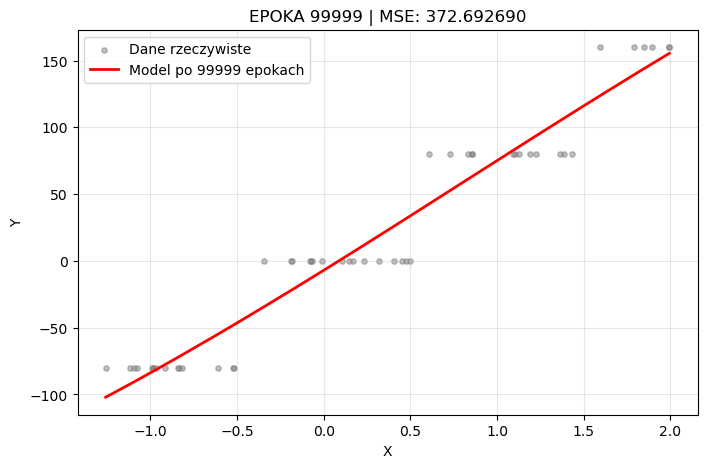

Wagi:
[array([[ 0.4493973 , -1.36051292, -0.46517145,  0.25236173, -0.64968599,
         0.53479329, -0.96192169,  1.02185923,  1.02346138,  0.03313236,
         0.5881247 ,  0.62677295,  0.27584811, -0.36065564,  0.56953414,
        -0.32587138,  1.06591821,  0.02286738, -0.20602408,  0.75496345]]), array([[-0.24720715, -0.78457144, -0.32039362, -0.1410123 ,  0.47339517,
         0.21733531, -0.56089078,  0.66114945,  0.63629797, -0.20568859,
         0.02658496,  0.55395921, -0.03157344,  0.51822588, -0.92448396,
         0.00213057, -0.13182845, -0.44046546,  0.72061817, -0.96642294],
       [-0.1043205 , -1.00816625, -0.16244812,  0.60991341, -0.36742146,
         1.25214106, -0.79519423, -0.81177616,  0.82233697,  0.44437532,
         0.40798398,  0.13203571,  0.06602839,  0.87613291, -0.55127348,
        -0.06639585,  0.39268655, -0.02024991,  0.24179356,  0.20099067],
       [-0.09822807,  0.784251  ,  0.41663426,  0.8112062 ,  0.76187188,
        -0.17713049,  0.3701209 , -0.92

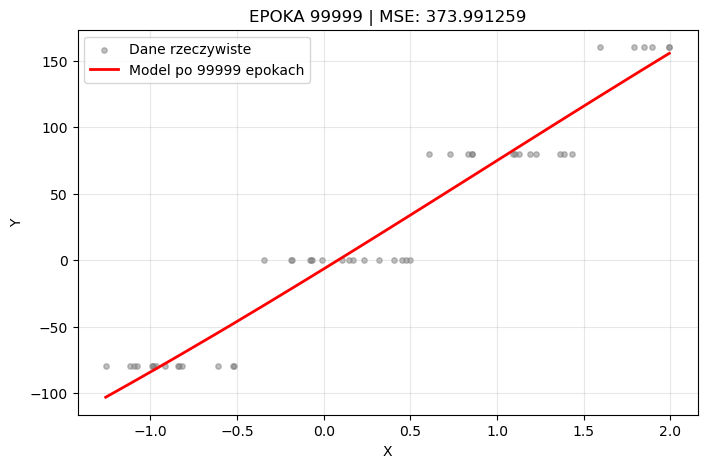

Wagi:
[array([[-0.18351344,  0.82191762,  0.94822109,  0.93249767,  0.01634435,
        -0.75466553,  0.54546006, -0.61852024,  0.57198281,  0.14088573,
         0.04597345, -1.051361  ,  0.91996742,  0.13882668, -0.88185771,
        -0.4309243 ,  0.18694484,  0.4913917 , -0.37373082,  1.15482143]]), array([[ 0.25751266, -0.76295769, -0.90832213,  0.41535052, -0.99224949,
         0.47687663,  0.17008773, -0.10824774, -0.3305369 ,  0.42835725,
         0.08379351,  0.59557307,  0.93083507,  0.84721508,  0.26397512,
        -0.15561702,  0.8343029 ,  0.78957831,  0.39656292,  0.16360281],
       [ 0.8441089 , -0.14825599, -0.41602459, -0.70199387,  0.27132541,
         0.7524273 , -0.85666584, -0.0539328 , -0.51914139,  1.07298144,
        -0.00622255, -0.21566704,  0.79242822,  0.2792579 , -0.95588873,
        -0.6184203 , -0.929094  , -0.3801463 , -0.83234927,  0.23884371],
       [-1.002253  , -0.29283607,  0.10075649, -0.69805515,  0.6427105 ,
         0.41653943, -0.06801243,  0.35

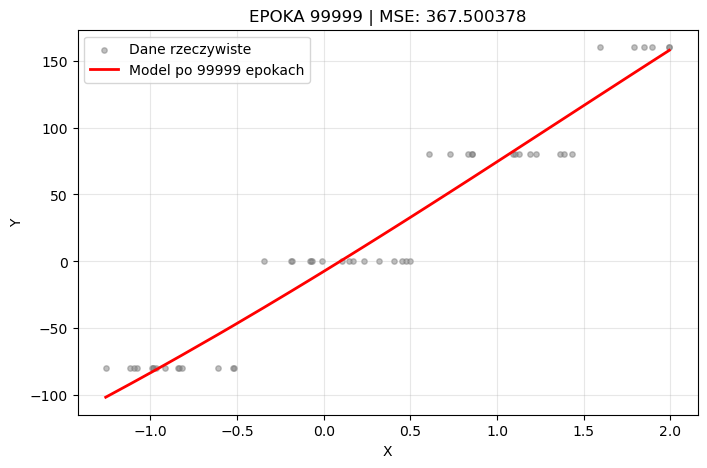

Wagi:
[array([[-0.17661701,  0.82657976,  0.95658914,  0.88801477,  0.01900002,
        -0.8137574 ,  0.5540226 , -0.65120714,  0.58345747,  0.12171995,
         0.0493019 , -1.05098302,  0.9307502 ,  0.13748215, -0.84945153,
        -0.40523534,  0.1827696 ,  0.49769948, -0.39807725,  1.14706089]]), array([[ 0.25672766, -0.75862935, -0.90801448,  0.41301437, -0.98907899,
         0.47565612,  0.16625202, -0.12416616, -0.33179161,  0.4273586 ,
         0.08318468,  0.59548446,  0.92965959,  0.84667766,  0.26372078,
        -0.15449183,  0.83428385,  0.79017966,  0.39981612,  0.16700807],
       [ 0.84061885, -0.14375571, -0.41508905, -0.7081217 ,  0.27169155,
         0.74885354, -0.85574866, -0.05299345, -0.5277177 ,  1.07013326,
        -0.00634313, -0.21581205,  0.79719988,  0.27943565, -0.95630205,
        -0.61996121, -0.92943526, -0.38043236, -0.82620555,  0.24612827],
       [-1.00557135, -0.28713263,  0.10197081, -0.70568753,  0.64242972,
         0.41230668, -0.06608444,  0.35

In [68]:

start = time.time()
mlp_sts_full.train(x_sts, y_sts, epochs=100000, lr=0.01, batch_size=len(x_sts), verbose=False)
mlp_sts_full.train(x_sts, y_sts, epochs=100000, lr=0.003, batch_size=len(x_sts), verbose=False)
time_full = time.time() - start


start = time.time()
mlp_sts_batch.train(x_sts, y_sts, epochs=100000, lr=0.01, batch_size=32, verbose=False)
mlp_sts_batch.train(x_sts, y_sts, epochs=100000, lr=0.003, batch_size=32, verbose=False)
time_batch = time.time() - start


print("Full batch time:", time_full)
print("Mini batch time:", time_batch)

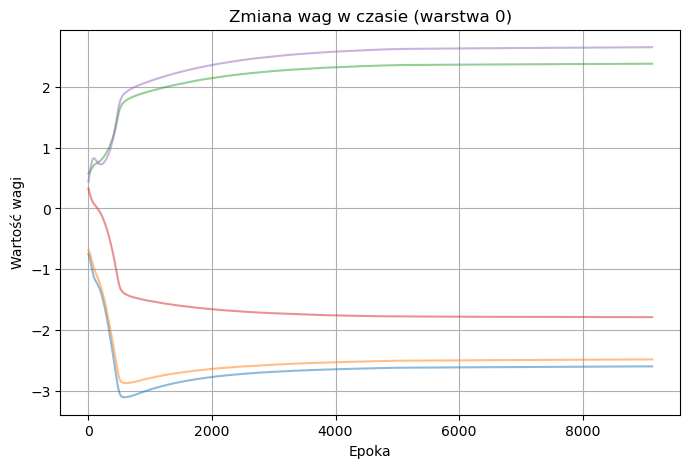

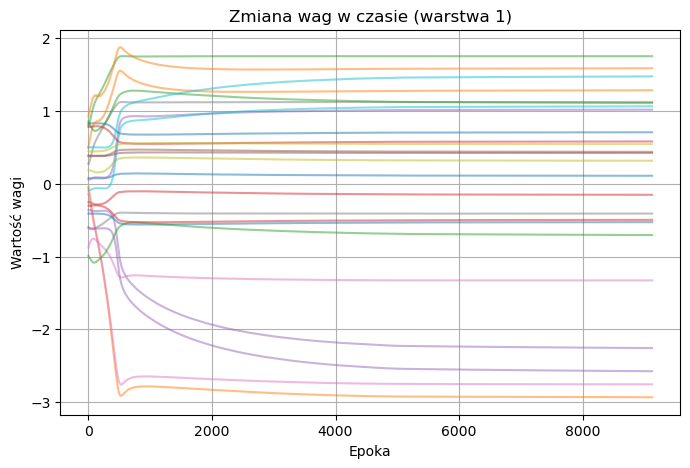

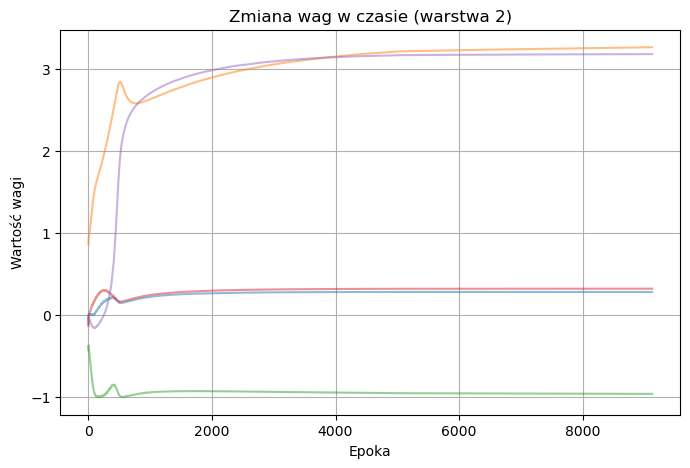

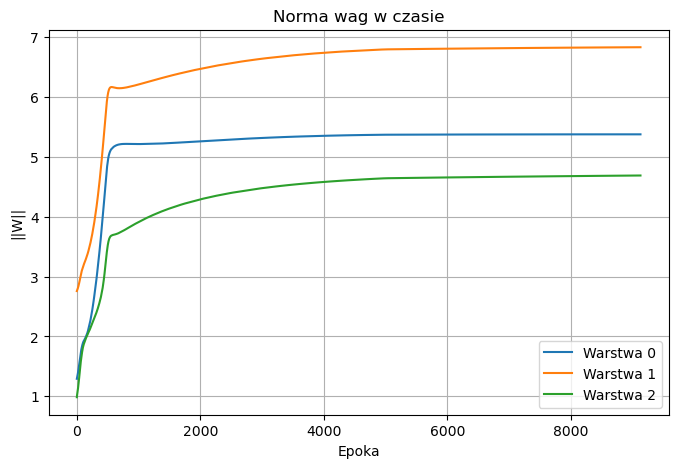

In [71]:

mlp_ss_batch.plot_weight_evolution()
mlp_ss_batch.plot_weight_evolution(1)
mlp_ss_batch.plot_weight_evolution(2)
mlp_ss_batch.plot_weight_norms() # jak widać mało zmieniają się wagi

In [80]:
# spróbujmy tanh i weźmy minibatch, bo lepszy


mlp_sts_batch_tanh = MLP(layer_num, tanh, grad_tanh)

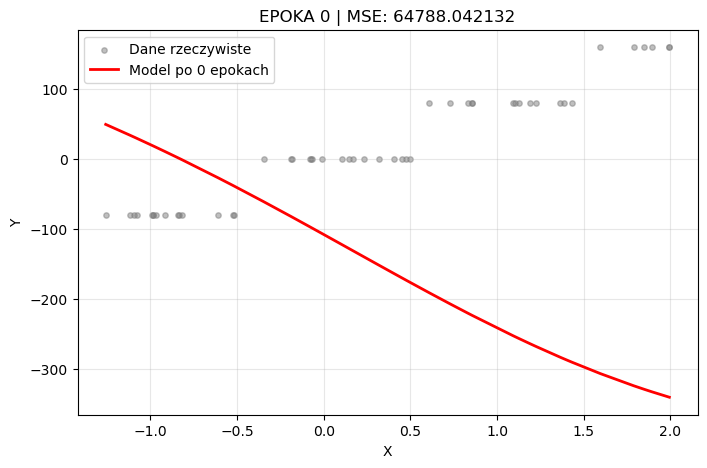

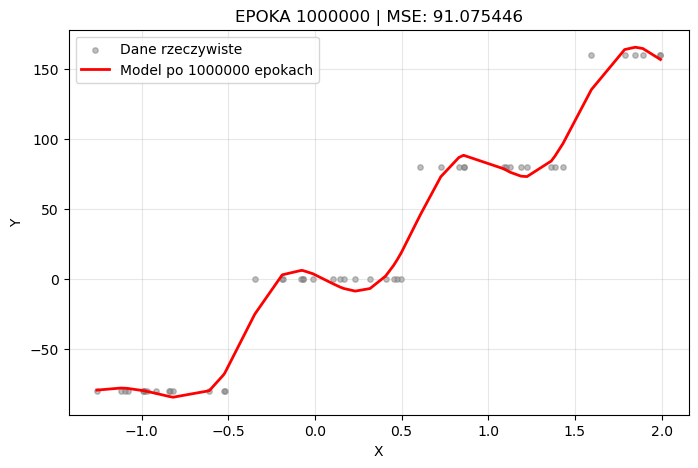

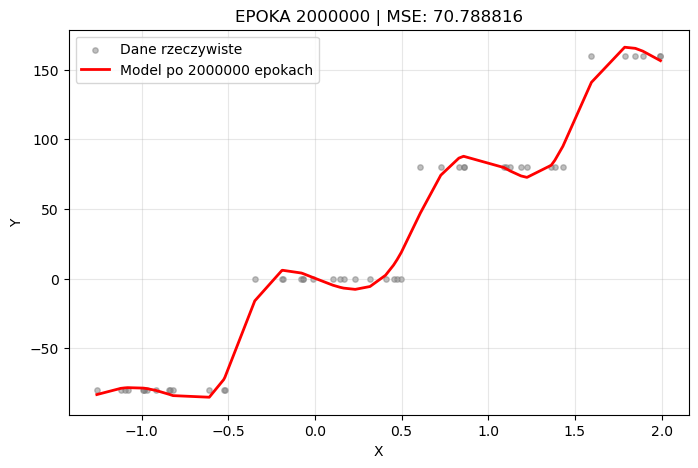

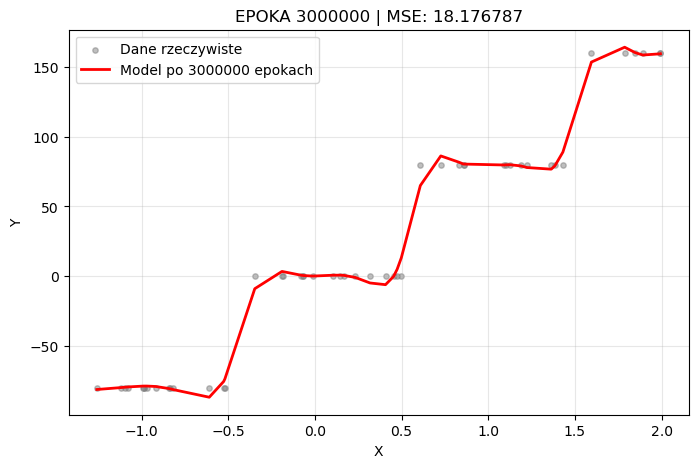

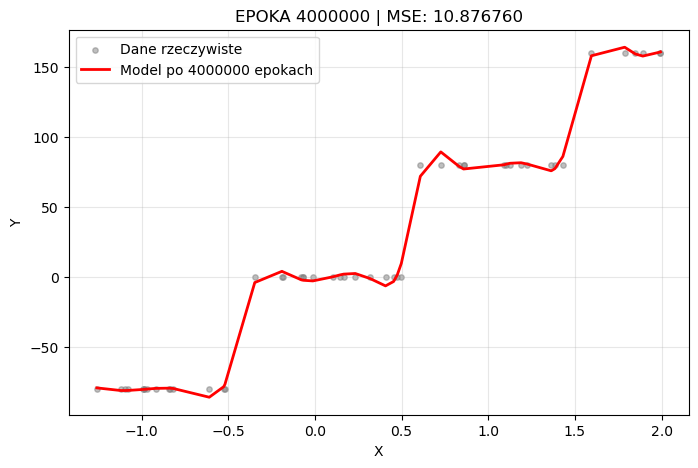

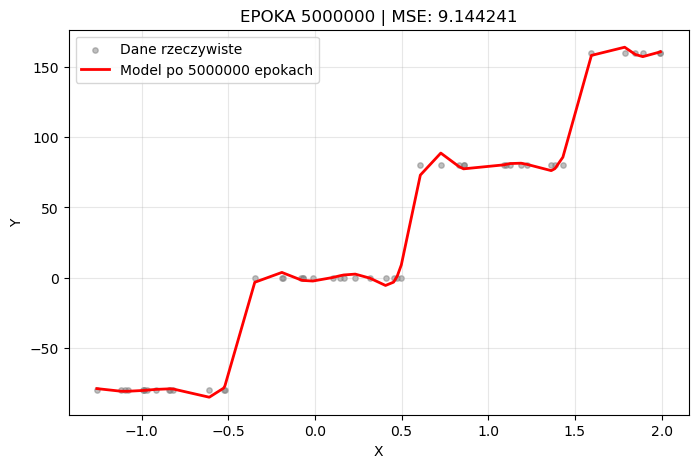

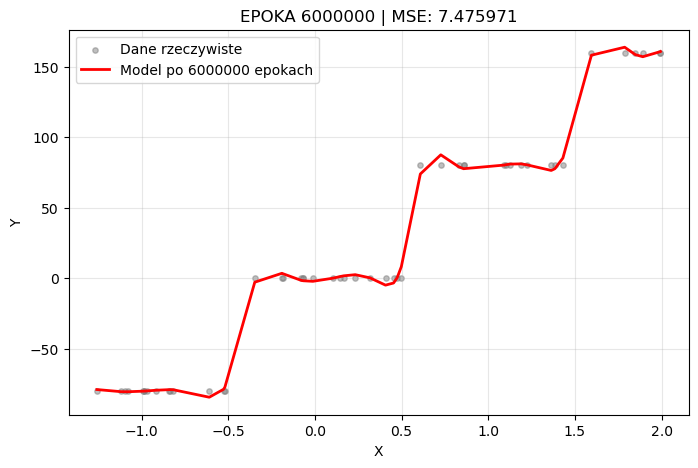

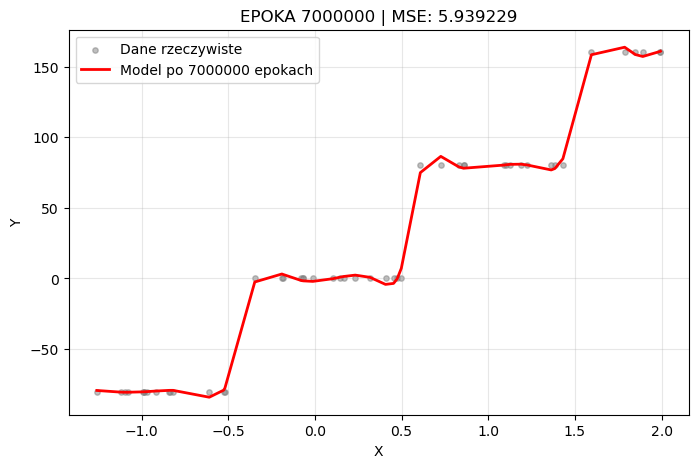

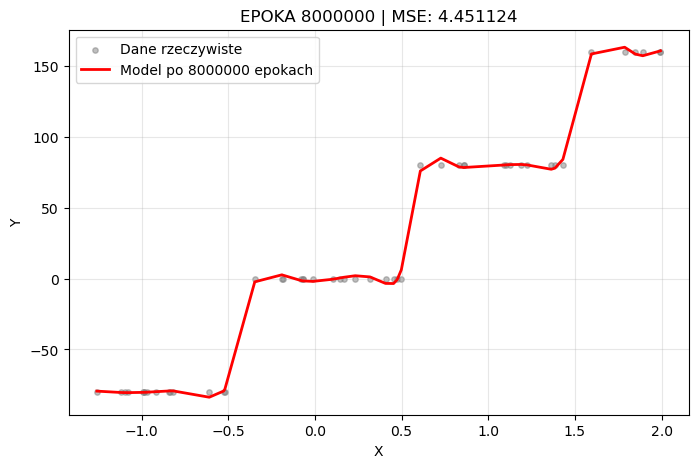

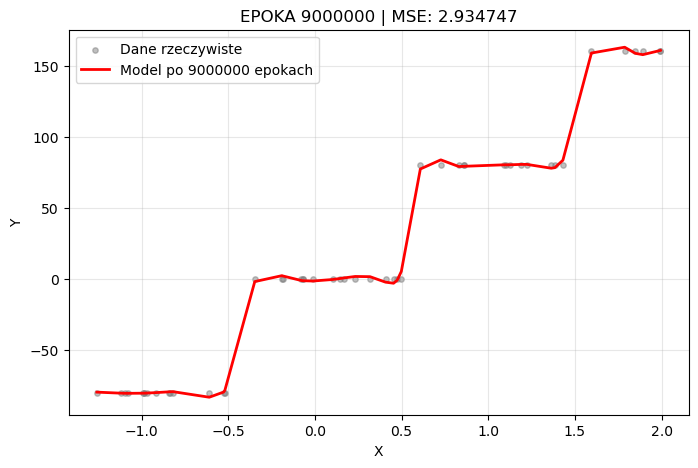

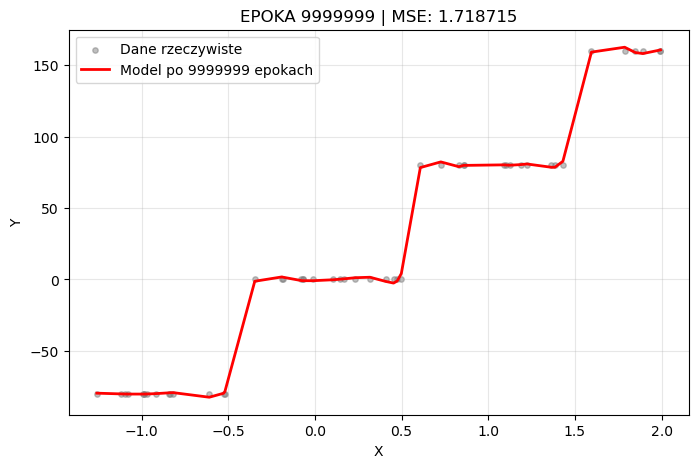

Wagi:
[array([[ 2.33836946, -0.72812454, -2.56109888, -2.47751356,  1.63170717,
        -2.75813519, -1.14833875,  1.92689253, -2.40727178,  2.08051544,
        -3.18311834,  0.89751308,  2.86790255,  0.80856197, -2.36925802,
         0.82365126, -0.77072636,  1.00299942, -0.50162456,  0.80268121]]), array([[-1.33583746e-01, -5.80296765e-01, -1.32183593e+00,
        -1.99412341e+00, -4.07863349e-01, -3.31593563e-02,
         9.79782064e-01,  2.51837805e-01, -8.77640813e-01,
        -1.95630830e+00,  4.80804946e-01, -1.56340415e-01,
         1.38000528e-01, -7.50417714e-01, -6.22110512e-01,
         6.89178532e-01,  2.85795333e-01, -9.01138412e-01,
         2.84070050e-02, -1.12211442e-01],
       [-1.42499780e+00, -2.12901220e-01, -5.76646673e-02,
         3.62116418e-01,  2.41998648e-01,  8.67817744e-02,
         3.53893877e-01,  1.17108618e-02,  4.06054864e-01,
        -1.89917701e-01,  2.16416624e-01,  1.38317928e-01,
         8.01656850e-01, -2.45279298e-01, -3.66307365e-01,
      

In [81]:
start = time.time()
mlp_sts_batch_tanh.train(x_sts, y_sts, epochs=10000000, lr=0.01, batch_size=32, verbose=True, epochs_between_graphs=1000000)
time_batch = time.time() - start

print("Mini batch time:", time_batch)

In [ ]:
Wagi:
[array([[ 2.33836946, -0.72812454, -2.56109888, -2.47751356,  1.63170717,
        -2.75813519, -1.14833875,  1.92689253, -2.40727178,  2.08051544,
        -3.18311834,  0.89751308,  2.86790255,  0.80856197, -2.36925802,
         0.82365126, -0.77072636,  1.00299942, -0.50162456,  0.80268121]]), array([[-1.33583746e-01, -5.80296765e-01, -1.32183593e+00,
        -1.99412341e+00, -4.07863349e-01, -3.31593563e-02,
         9.79782064e-01,  2.51837805e-01, -8.77640813e-01,
        -1.95630830e+00,  4.80804946e-01, -1.56340415e-01,
         1.38000528e-01, -7.50417714e-01, -6.22110512e-01,
         6.89178532e-01,  2.85795333e-01, -9.01138412e-01,
         2.84070050e-02, -1.12211442e-01],
       [-1.42499780e+00, -2.12901220e-01, -5.76646673e-02,
         3.62116418e-01,  2.41998648e-01,  8.67817744e-02,
         3.53893877e-01,  1.17108618e-02,  4.06054864e-01,
        -1.89917701e-01,  2.16416624e-01,  1.38317928e-01,
         8.01656850e-01, -2.45279298e-01, -3.66307365e-01,
         3.91937982e-01,  4.52741059e-01,  2.57227947e-01,
        -5.62997240e-01,  7.03552082e-01],
       [-7.05792650e-01,  9.38779453e-01,  9.65979415e-01,
         2.08921956e+00,  5.41888038e-01,  6.72342159e-01,
        -5.40967312e-01, -2.85539895e-02,  4.11932897e-01,
         2.17106580e+00,  5.97925776e-01,  7.00869323e-01,
        -5.70864337e-01,  9.14245162e-03, -5.69575774e-01,
         8.24630817e-01,  7.66695087e-01, -3.05455528e-01,
         3.81698075e-01, -5.66460120e-01],
       [-2.03824783e+00, -4.92255857e-01,  1.61087264e-01,
        -2.65609086e-01,  3.74253393e-02, -3.68783032e-01,
         1.63253914e+00, -3.86443316e-01,  6.46220811e-02,
         2.07071554e+00, -1.09869054e+00, -2.30256566e-02,
        -1.33458533e+00,  3.67514435e-01,  7.92918185e-01,
        -7.18850986e-01, -8.73056138e-01, -2.94950184e-01,
         6.72078665e-01,  7.40605393e-01],
       [ 1.46453643e+00,  1.68721260e-01, -3.00866807e-03,
         3.02940861e-01, -6.37000191e-01,  4.09213712e-01,
        -1.15995918e+00,  9.20203570e-01,  1.49770576e-01,
        -1.82060839e+00,  3.12653553e-01,  8.49606245e-01,
         2.73895833e-01, -9.46560376e-01, -9.45736678e-01,
         4.16238203e-01, -9.00809119e-01, -4.83461672e-01,
        -4.22415514e-01, -4.09105498e-01],
       [-2.56095719e+00, -6.14190723e-01,  4.72154736e-01,
        -4.53580794e-01, -4.28913724e-01, -6.44665902e-01,
         1.87082366e+00, -4.38222319e-01,  6.73508123e-01,
         2.38170510e+00, -3.23882951e-01, -1.70158360e-01,
         6.26974560e-02, -8.99861892e-01, -7.93800450e-01,
        -6.99909686e-02,  6.85907952e-01,  1.88014738e-01,
        -1.94281679e-01,  1.06231802e+00],
       [ 7.87826062e-02,  2.57620042e-01,  2.72981397e-01,
         1.22730959e+00, -8.09970562e-01, -8.24611383e-01,
         7.80274581e-01,  2.46652967e-01, -4.97030287e-01,
         5.08815482e-01,  6.84075181e-02,  2.84192162e-02,
         6.60161213e-01, -1.01260071e+00,  5.80310752e-01,
        -2.82698613e-01,  3.42984109e-01,  3.29194052e-01,
        -4.69745164e-01, -6.61427437e-01],
       [ 8.83927023e-01, -4.51379835e-01, -2.89809335e-01,
        -9.37160347e-01,  1.04723552e+00, -1.87603585e-01,
        -1.00150134e+00, -6.25403389e-01,  4.24779993e-01,
        -1.47177268e+00,  1.46281589e-02, -3.55707002e-01,
         1.00128610e+00, -5.34427732e-01,  1.77411594e-01,
         5.60023584e-01, -5.42485694e-01,  2.59519250e-02,
         7.41577593e-01, -1.14902979e+00],
       [-1.41221178e+00,  1.27094768e+00, -6.87705637e-01,
         1.91099871e+00, -5.82640632e-01,  4.32088981e-01,
         9.60922898e-01, -1.54997166e-01, -1.01307220e+00,
         2.37870814e+00, -1.00656587e+00, -3.02455467e-01,
        -2.10262590e-01, -3.60879019e-01, -2.43246878e-01,
        -6.26231518e-01, -2.66287198e-01,  3.46967091e-02,
         7.47915476e-01,  1.96522371e-01],
       [-8.80792414e-01,  8.48826656e-01, -3.55127482e-01,
        -1.72014682e+00, -2.16007251e-01, -1.01720571e+00,
        -4.61759742e-02, -6.41782291e-01, -1.48506977e-01,
        -1.05289888e+00,  7.57180135e-02,  6.23204109e-01,
         2.54332335e-01,  1.63617104e-01,  2.63264781e-01,
        -5.72963186e-01,  7.98539307e-01, -3.56981121e-01,
         5.90787287e-01,  2.81925080e-01],
       [-8.57293383e-01,  9.46361909e-01,  6.85089127e-01,
         2.28335255e+00,  7.50506271e-01,  6.97353947e-01,
         3.54699895e-01,  7.29517717e-01,  1.78465351e-01,
         3.02623680e+00,  5.28720204e-01, -9.89222504e-01,
        -1.71858563e+00, -7.07500094e-01,  3.92416444e-01,
        -9.51835753e-01,  2.15214155e-01,  4.81406633e-01,
        -1.23490907e-01,  1.11862244e+00],
       [ 1.07338051e+00, -7.99999969e-01, -1.01090615e+00,
        -4.10044481e-01, -1.07955453e-01, -2.15981162e-01,
        -2.43595445e-01, -1.08786277e-01,  2.97534627e-01,
        -2.40462344e-01, -5.08534240e-01, -3.58101730e-02,
         1.25238705e-01, -4.39062707e-01,  6.16323741e-01,
        -7.88012954e-01,  1.04631806e-01, -1.02915228e-01,
        -2.88564990e-01, -6.57785180e-01],
       [-4.09661784e-01,  9.85354020e-02, -9.49484104e-01,
        -2.67965965e+00, -1.46030543e-02, -6.84333702e-01,
         9.12647602e-01,  8.16991569e-01, -9.53321982e-02,
        -7.75307616e-01,  3.88391709e-02, -6.39767450e-01,
         7.06851676e-01,  8.78731499e-01, -6.76973248e-01,
        -8.01066186e-01,  9.66990805e-01, -5.86653396e-02,
         6.22334897e-01,  3.43964955e-01],
       [-4.34329100e-03, -5.26144137e-01, -4.09881955e-01,
        -6.36450600e-01,  7.73769183e-01, -6.91905130e-01,
        -3.46974801e-01,  1.25757191e-01, -8.32398739e-01,
        -3.01664808e-01, -5.92178902e-01,  6.33359023e-01,
        -9.00873761e-01, -7.30635689e-01, -3.48900759e-01,
        -2.32784225e-01,  3.22143995e-01, -1.87783041e-01,
         7.82680903e-01, -9.84767461e-01],
       [-1.82710976e+00,  1.02027972e+00,  8.91346436e-01,
         1.74841670e+00,  3.94627163e-01,  6.04139629e-01,
         7.04391055e-01, -3.40815416e-01, -6.62021096e-01,
         1.51949611e+00, -3.60689105e-01,  8.59646239e-01,
        -1.42388412e+00, -2.62352844e-01,  7.08268850e-02,
         3.12041004e-01,  8.91968154e-02, -5.48939845e-01,
        -1.81615570e-02,  3.41589460e-01],
       [-2.05034989e-02,  8.89937231e-01, -4.06743660e-01,
        -3.56980830e-01,  9.30337537e-01,  6.07940181e-02,
         1.75193172e-01,  9.42426863e-01, -8.16983875e-01,
        -5.41168120e-01, -7.96837386e-02, -9.84451675e-01,
         6.34817082e-01, -3.76971847e-01, -1.37938309e-02,
        -4.52649129e-01, -3.69064125e-01,  2.45897923e-01,
        -3.53236856e-01, -8.36787367e-01],
       [ 8.19881317e-02, -2.40844410e-01,  1.71883916e-01,
         8.33968697e-01, -2.90957275e-02,  9.24630981e-01,
        -7.15718945e-02,  7.95436774e-01, -5.93099143e-01,
         2.54077166e-01,  3.40298113e-01,  1.00542234e+00,
        -4.75474781e-01,  5.04818414e-01, -6.20849717e-01,
        -4.74960495e-01, -9.37780421e-01, -7.28821905e-02,
         4.06254571e-01, -6.02199705e-01],
       [ 9.04122589e-01, -3.31717679e-01,  2.74176310e-01,
         7.21894846e-01, -1.71873219e-01, -7.84880858e-01,
        -9.68687492e-01,  4.42915096e-02, -5.94258811e-01,
        -6.65472504e-01, -5.63759526e-01, -6.54147720e-01,
         8.23988703e-01,  4.98686823e-01, -9.02743156e-01,
        -5.35465308e-01, -5.62830079e-01,  4.11229324e-01,
         4.76197555e-01, -7.95070121e-01],
       [ 9.79788158e-01, -7.27825997e-01, -3.28319564e-01,
         1.26507054e+00,  9.98075767e-01,  9.16324370e-01,
         2.96309514e-01,  9.37846185e-01,  5.51740633e-02,
        -8.38179451e-01,  3.19753841e-01, -9.55574387e-01,
         2.13815769e-01, -3.95725328e-01, -6.07293408e-01,
         2.77227832e-01, -8.97011651e-01, -4.18958455e-01,
         3.73608629e-02,  3.30023690e-01],
       [-6.38747574e-01,  1.30789473e-01, -6.05708107e-02,
        -1.14223849e+00, -4.44576609e-01,  9.93240678e-01,
         1.07266731e+00,  6.39500721e-01, -8.75001763e-01,
        -5.45365434e-01,  6.78253305e-01,  2.31858851e-01,
         8.62477404e-01,  6.44200218e-01,  6.27361534e-01,
        -2.91724604e-01,  3.88745681e-01, -7.86375802e-01,
        -6.50653579e-01, -3.32001192e-02]]), array([[ 1.09456185],
       [-0.84992433],
       [ 0.66122582],
       [-0.36519405],
       [ 0.76766883],
       [-0.82492657],
       [ 1.3930443 ],
       [-0.6534491 ],
       [-0.35342559],
       [-0.40902161],
       [ 0.88494564],
       [-0.15527441],
       [-0.75800103],
       [-0.45192127],
       [ 0.33561846],
       [ 0.04439063],
       [-0.1302861 ],
       [ 0.0602966 ],
       [-0.65847531],
       [ 0.57306845]])]
Bias:
[array([[-0.57988742,  1.02314966,  0.87408476,  1.802019  , -1.27112167,
         2.18817589,  0.05204425, -1.18925073,  1.53825974, -0.26996279,
         1.66328395, -0.44256325, -0.61923493,  0.33316698,  1.30462611,
        -0.02839133, -0.27220418, -1.15849361, -1.07270858,  0.90552218]]), array([[-1.44633036,  0.26719516, -1.02939746, -0.22980018,  0.85256043,
        -0.10257973,  0.13225235, -0.95878031,  0.16003129,  1.02169722,
        -0.05791372, -0.50636893, -0.98931532,  1.02322756,  0.94533697,
         0.88194724, -0.29673915,  0.86794331, -0.11843398, -0.26672761]]), array([[-0.6826755]])]
Mini batch time: 1193.6154961585999

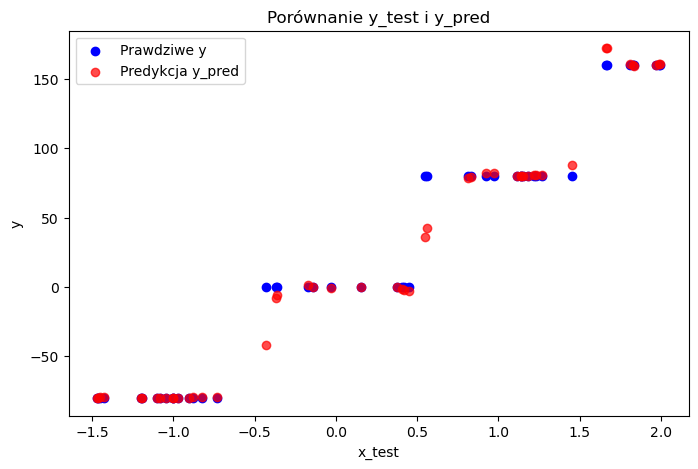

MSE dla modelu 1_20_20_1 trenowanym na batchach: 112.518828


In [82]:
y_pred = mlp_sts_batch_tanh.calc(test_x_sts)
plt.figure(figsize=(8,5))
plt.scatter(test_x_sts, test_y_sts, color='blue', label='Prawdziwe y')
plt.scatter(test_x_sts, y_pred, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(test_y_sts, y_pred)
print(f"MSE dla modelu 1_20_20_1 trenowanym na batchach: {loss:.6f}")

In [30]:
# multimodal-large
data_multimodal_large = csv.reader(open('mio1/regression/multimodal-large-training.csv'))
test_data_multimodal_large = csv.reader(open('mio1/regression/multimodal-large-test.csv'))
x_ml, test_x_ml, y_ml, test_y_ml = data_to_matrix(data_multimodal_large, test_data_multimodal_large)

In [8]:
np.random.seed(52)

layer_num = [1,20,20,1]
mlp_ml_full = MLP(layer_num, tanh, grad_tanh)
mlp_ml_batch = MLP(layer_num, tanh, grad_tanh)

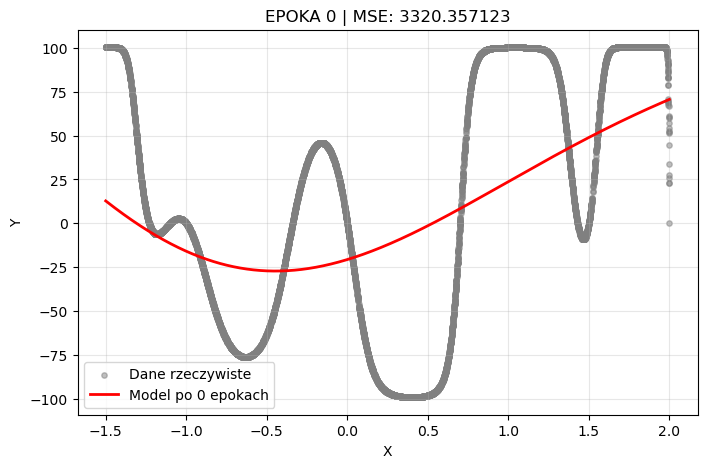

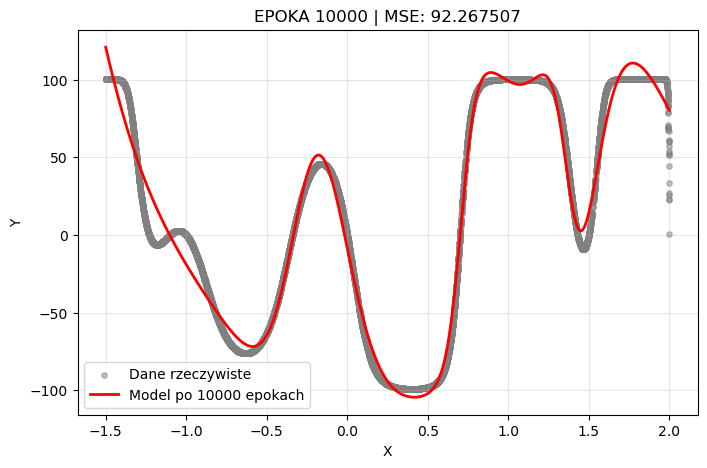

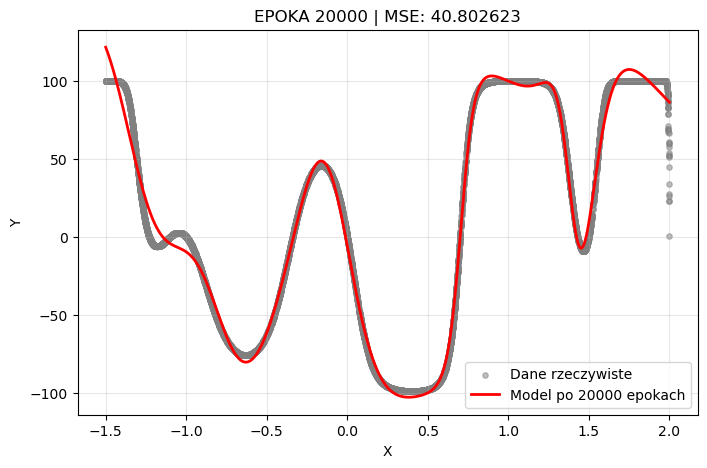

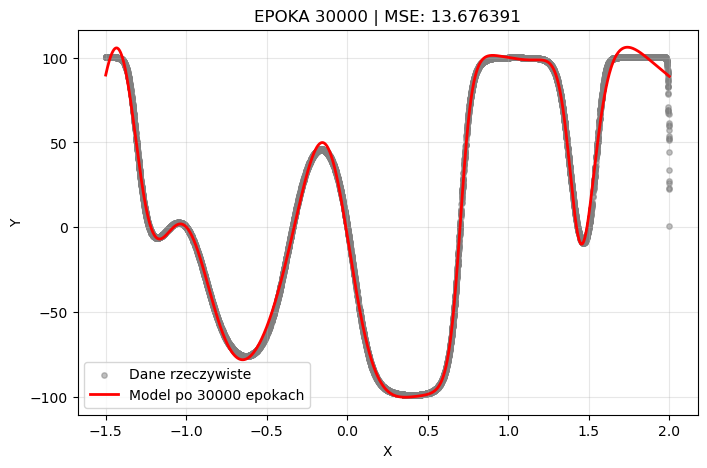

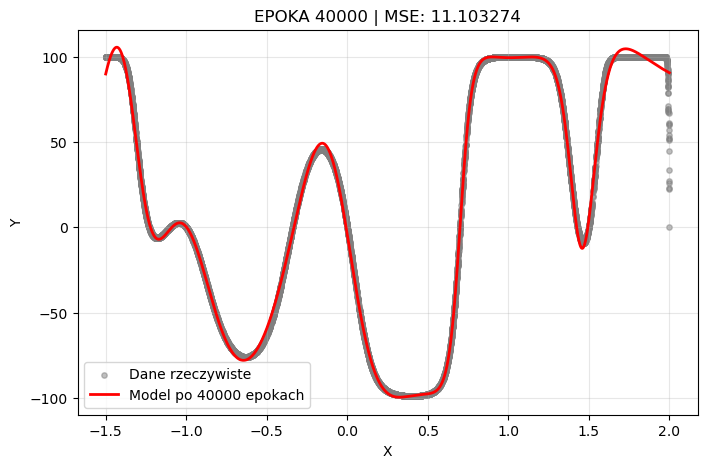

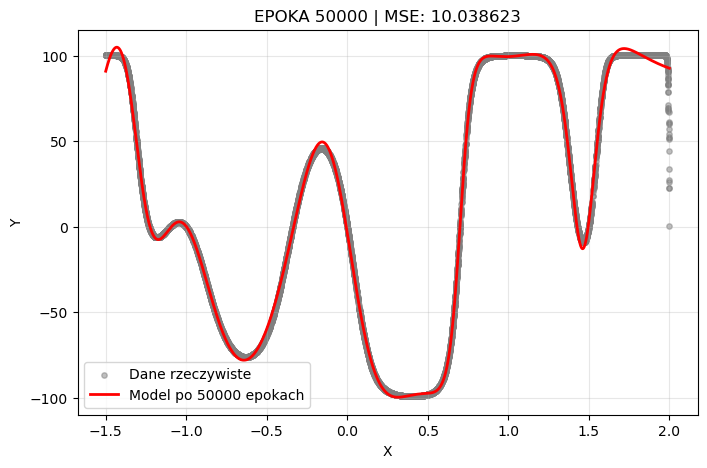

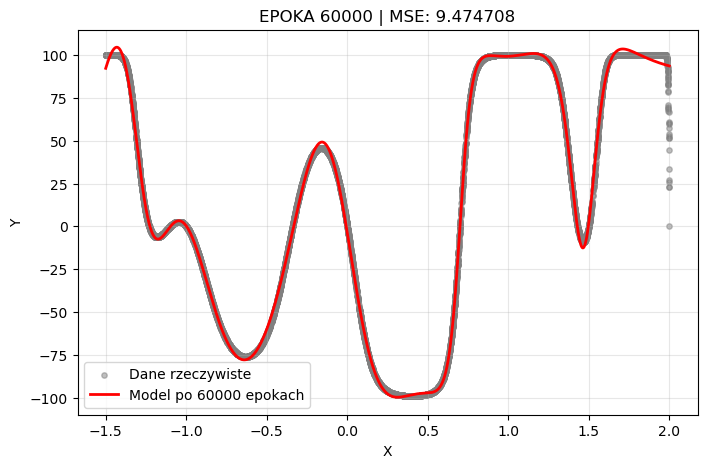

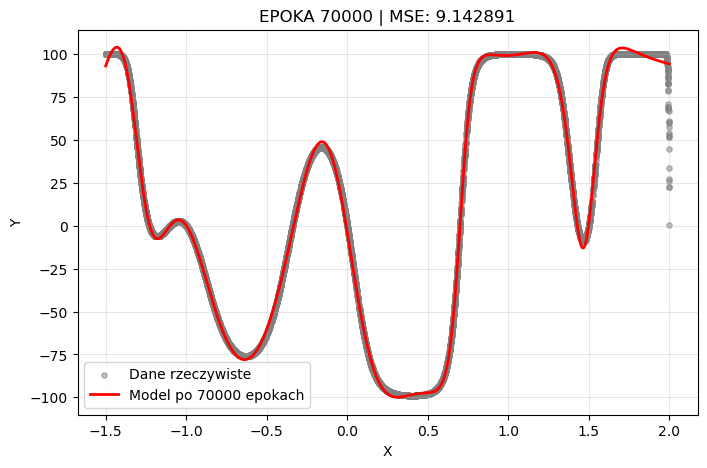

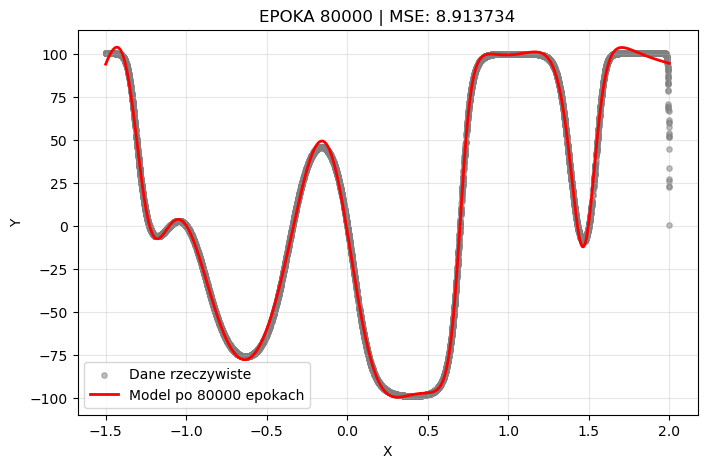

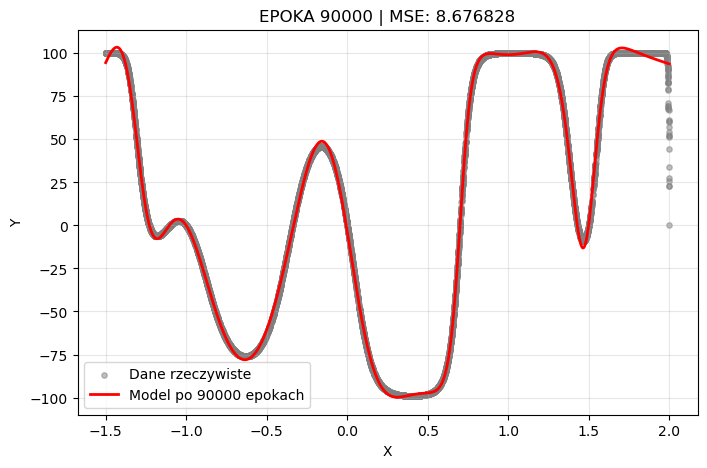

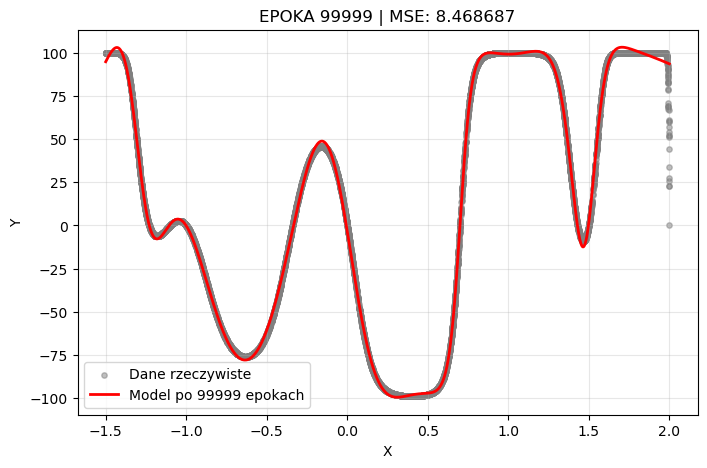

Wagi:
[array([[ 1.47895523, -4.61240725, -1.98984668, -0.80460464, -1.74576486,
         1.49509157, -3.9154475 ,  2.72593206,  2.8135041 , -0.03506363,
         0.74639366,  0.97379575,  1.58612778, -0.66100863,  0.53523745,
        -2.26191767,  3.57365344, -1.10235935, -2.22596506,  3.15545367]]), array([[-0.49411664, -1.57284716, -0.38105137,  0.19328962,  0.33475268,
         0.0339401 , -0.42058674,  0.92357086,  0.14168883, -0.10837732,
         0.3431071 ,  0.55525791, -0.25152947,  0.77101626, -1.40753251,
        -0.34627013, -0.13120584, -0.2951528 ,  0.72395097, -0.96455241],
       [-0.38161187, -0.95879631,  0.35656304,  1.32364954, -0.52351251,
         4.04049571, -0.87481837, -0.60945718,  1.4968441 ,  0.39810466,
         3.62080034, -0.03916169, -0.17160174,  1.061203  , -3.1197513 ,
         0.92368619,  0.38983861, -0.04521745,  0.28220339,  0.19464273],
       [ 0.06232869,  1.98620057,  0.53631871,  0.5477242 ,  0.87472334,
         0.18083662,  0.18400352, -1.38

In [106]:
start = time.time()
mlp_ml_full.train(x_ml, y_ml, epochs=100000, lr=0.01, batch_size=len(x_sts), verbose=True, epochs_between_graphs=10000)
time_full = time.time() - start





print("Full batch time:", time_full)


In [29]:
ml_w_full = [np.array([[ 1.47895523, -4.61240725, -1.98984668, -0.80460464, -1.74576486,
         1.49509157, -3.9154475 ,  2.72593206,  2.8135041 , -0.03506363,
         0.74639366,  0.97379575,  1.58612778, -0.66100863,  0.53523745,
        -2.26191767,  3.57365344, -1.10235935, -2.22596506,  3.15545367]]), np.array([[-0.49411664, -1.57284716, -0.38105137,  0.19328962,  0.33475268,
         0.0339401 , -0.42058674,  0.92357086,  0.14168883, -0.10837732,
         0.3431071 ,  0.55525791, -0.25152947,  0.77101626, -1.40753251,
        -0.34627013, -0.13120584, -0.2951528 ,  0.72395097, -0.96455241],
       [-0.38161187, -0.95879631,  0.35656304,  1.32364954, -0.52351251,
         4.04049571, -0.87481837, -0.60945718,  1.4968441 ,  0.39810466,
         3.62080034, -0.03916169, -0.17160174,  1.061203  , -3.1197513 ,
         0.92368619,  0.38983861, -0.04521745,  0.28220339,  0.19464273],
       [ 0.06232869,  1.98620057,  0.53631871,  0.5477242 ,  0.87472334,
         0.18083662,  0.18400352, -1.38871547, -0.25251717,  0.36458212,
         0.40251581, -0.35701295,  1.00770053, -1.18571836, -0.02778287,
        -0.24093544, -0.1246242 ,  0.71135315, -0.43969046, -0.13978193],
       [-0.18371417,  0.74138332,  1.00144057,  0.18828992,  0.0427275 ,
         0.64061241,  0.61526123, -0.82350365, -0.66876836,  0.40345308,
        -0.40913378, -0.12939682,  0.77349212,  1.20123975,  0.01386411,
        -0.11826836,  0.03115952, -0.75672799,  0.94962735,  0.90761705],
       [ 0.71388744,  1.76913962, -0.18566863,  0.28327061, -0.84451591,
        -0.01725627, -0.83266526, -0.97301688, -0.3363582 ,  0.37404296,
        -0.97500619, -0.10949183, -0.46002014,  0.67140696,  0.38769009,
         0.59008561,  0.16790753, -0.27779895, -0.66593242,  0.6021355 ],
       [ 0.64670492, -0.6533454 , -0.85219596,  0.2846742 , -0.36424355,
        -1.29750086,  0.46182954,  0.55943074, -0.44568255, -0.12643986,
        -0.63101706, -0.67282887, -1.16794456, -0.06786057,  1.2357832 ,
        -0.72671105, -0.72106868, -0.2615211 ,  0.92890916, -0.53573752],
       [-0.47986467,  1.16965129,  0.68581734, -0.10537985,  0.38790525,
         3.63248207, -1.24947879, -0.57385638,  1.58320637, -0.65609644,
         2.09802146, -0.77186091,  0.61585616, -0.04516077,  0.05226536,
         1.39924453, -0.8514843 ,  0.04353187,  0.03884752, -0.55505139],
       [-1.1088402 , -2.05617397, -0.71614319,  0.76764506,  0.91183352,
        -0.55833177,  1.0337123 ,  1.03162372, -0.79823037, -0.12134148,
         0.84596694, -0.48993281, -1.24381655,  0.47138158,  0.22407204,
         0.36613517, -0.96394215,  0.95876239, -0.1841027 , -0.00871543],
       [ 0.1435928 , -1.62883962,  0.48487769, -0.90557117,  0.31557736,
        -3.25401855,  0.47212929,  0.30527075, -1.77180428,  0.87951152,
        -1.32550643, -0.50750477, -0.98236438,  0.64723178, -0.18153883,
        -1.99412717,  0.06724222, -0.94764716, -0.56246512,  0.7336527 ],
       [-0.92057157,  0.31619968,  0.09305494,  0.16503317, -0.05722255,
         0.3567216 , -0.67744605,  0.38750805, -0.43236358, -0.61714839,
         0.88584244, -0.88855223, -0.89674426,  0.35439774, -0.25409927,
        -1.13456329, -0.44321716,  1.11880359,  0.7871806 , -0.98742848],
       [ 0.52528269, -0.59898438,  0.82994189,  0.83556221,  0.61935245,
        -0.47255204,  0.46268248,  0.41795918, -0.58133513,  0.89955848,
        -0.0694519 , -0.12482565,  0.64500284, -0.23587917,  0.83295353,
         0.66173182, -0.64416777,  0.53114426,  0.26618956, -0.213244  ],
       [-0.61127541,  0.12664394, -0.76181385, -0.20006647,  0.86907816,
        -1.45106947,  0.31981178, -0.10805353,  0.67689507,  0.73244713,
         0.08082501,  0.42009222, -0.29168291,  0.27774999,  0.84918767,
         0.00613585,  0.67012048,  0.60405918,  0.74554971,  0.21495653],
       [-0.96302817, -1.45179001, -0.94294162, -0.61623073, -0.64513673,
        -0.04199932,  0.3666018 , -0.43330796, -0.98927072, -0.00742582,
         0.06680349, -0.8965759 , -0.64354632, -0.05930955, -0.87039381,
        -0.56123063, -0.5850695 ,  0.68215032, -0.40695313,  0.35292702],
       [-0.27085105,  0.40722321, -0.5271134 , -1.10784222,  0.3007509 ,
         0.63896032,  0.15611807,  0.0658255 , -0.40870205, -0.50261623,
        -0.46586906,  0.1112408 ,  0.8840594 , -0.16015862, -0.48851872,
         0.60216744,  0.376569  , -0.88507466, -0.99338053,  0.41756559],
       [ 0.84234352,  0.20208268, -0.46320363,  0.25151417, -0.60376684,
        -0.03645108, -0.80535802,  1.15237361, -0.45609938,  0.17476223,
        -0.46490944,  0.66440888, -1.14424468, -0.11226366,  0.5595646 ,
        -0.0418073 ,  0.67247182,  0.84516804,  0.52281718, -0.25771146],
       [ 0.70874747,  1.29968843,  0.27104833,  0.63021025,  0.69114023,
         1.63578194, -0.17944869, -1.24995941,  1.02455426, -0.25853961,
         0.53525408, -0.78126813,  0.94074665,  0.15466808,  0.34451369,
         0.99787165,  0.00776757, -0.56627258,  0.71182713,  0.48631714],
       [-0.54345714, -0.82403966, -0.03954331,  0.75009635,  0.67801962,
        -2.61289431, -0.71172801, -0.24797773, -0.57827326, -1.06971337,
        -2.11509671,  0.73016546, -0.55783477,  0.63127715,  3.69182451,
        -0.64476146,  0.69587962,  0.94461405, -0.58334777,  0.26222724],
       [ 0.02622039,  0.46662047, -0.11475726,  0.80083729, -0.90717559,
         0.46920165, -0.95969702, -0.0286785 , -0.25811204, -0.81783939,
         0.21508258,  0.4225705 ,  0.27701587,  0.81689902, -1.61500342,
         0.08237435, -0.3893959 ,  1.12132139, -0.53369442, -0.95958166],
       [ 0.60695241,  0.96886898,  0.44798886,  0.72638534, -0.4008769 ,
         1.97134015, -1.05568258, -0.10688644, -0.34819705, -0.54021448,
         0.63551996, -0.2664686 , -0.21521594, -0.7993729 , -2.26849889,
         0.82180794, -0.17740408,  0.46721765,  0.92442636, -0.75660727],
       [ 0.09372551, -2.50302231,  0.71573658,  1.11742093, -0.6012366 ,
        -1.05110587,  0.52496691,  0.77582121, -1.15850119, -0.5967419 ,
         0.62374709, -0.22372283, -0.24217192,  0.74479294, -0.31449014,
        -1.38030106, -0.52230935,  0.89482661, -0.01815099,  0.63272775]]), np.array([[-0.64947901],
       [ 1.08537603],
       [ 0.55578294],
       [ 0.74316961],
       [ 0.54031205],
       [-0.54232367],
       [ 0.97862249],
       [ 1.59540081],
       [-1.47073411],
       [-0.35242066],
       [ 2.20703697],
       [ 0.12307774],
       [ 1.09089371],
       [-0.04162814],
       [ 2.09747974],
       [ 1.76225522],
       [ 0.13898421],
       [-1.24032154],
       [ 0.55612358],
       [ 0.06548132]])]
ml_biases_w_full = [np.array([[ 0.59463303,  3.61301899, -0.10060723,  0.33015339,  0.04224207,
        -0.97393136,  2.04733954,  0.04326631, -1.72563583,  1.19152108,
        -0.13967701, -0.58191892,  0.58789509, -0.46391402, -0.00706834,
        -0.14506629, -2.96797534,  1.01661292,  1.65664081, -0.11188431]]), np.array([[ 0.37775574, -1.19326624,  0.38869302,  0.17283769,  0.69059314,
         0.44811594,  0.83098721,  0.14709012, -0.74041369, -0.39154175,
         1.29618701,  0.24390227,  0.4348703 , -0.32353487, -0.16017428,
         0.09511571, -0.36787844, -0.30654758,  0.78585949, -0.86834702]]), np.array([[0.63507244]])]

In [32]:
x_min, x_max, y_min, y_max = min_max_vals(x_ml, y_ml) # wczytanie z wag dla full ml
mlp_ml_full = MLP(
    layer_num=[1, 20, 20, 1],
    act_func=tanh,
    grad_act_func=grad_tanh,
    w=ml_w_full,
    biases_w=ml_biases_w_full,
    x_min=x_min,
    x_max=x_max,
    y_min=y_min,
    y_max=y_max
)

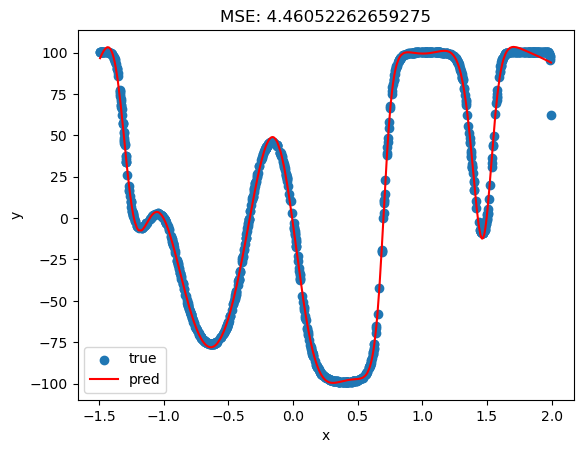

In [33]:
plot_model_predictions(mlp_ml_full, test_x_ml, test_y_ml) # sprawdzenie na testowych

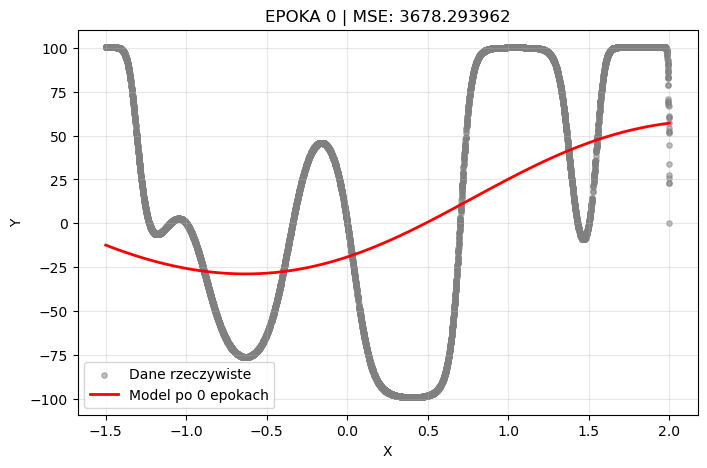

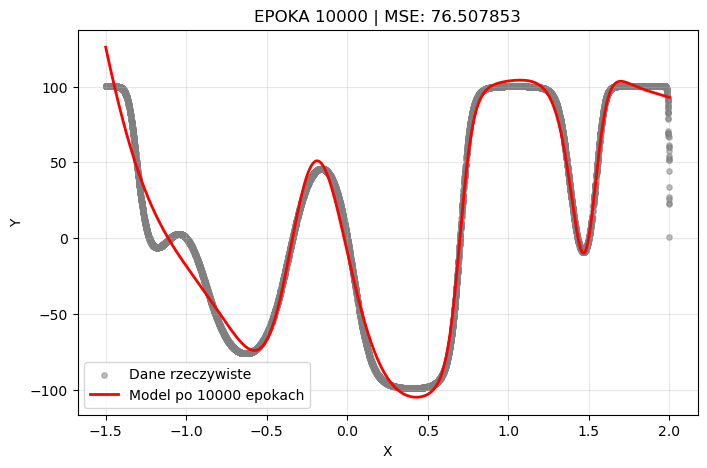

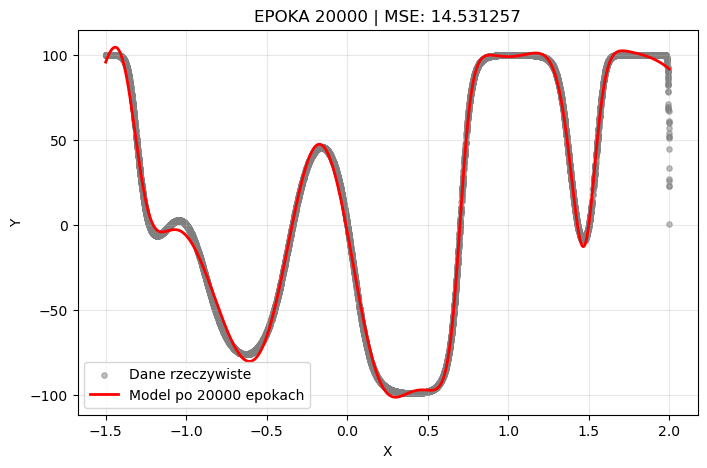

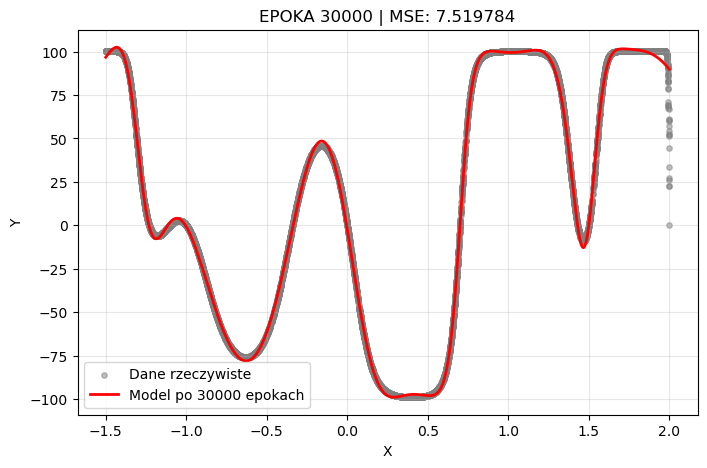

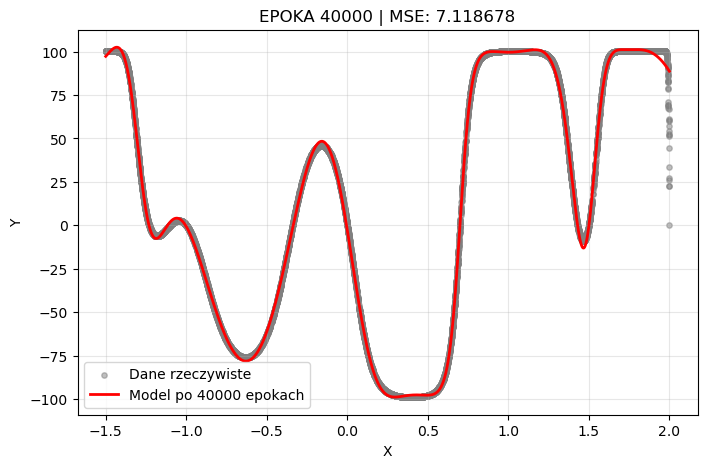

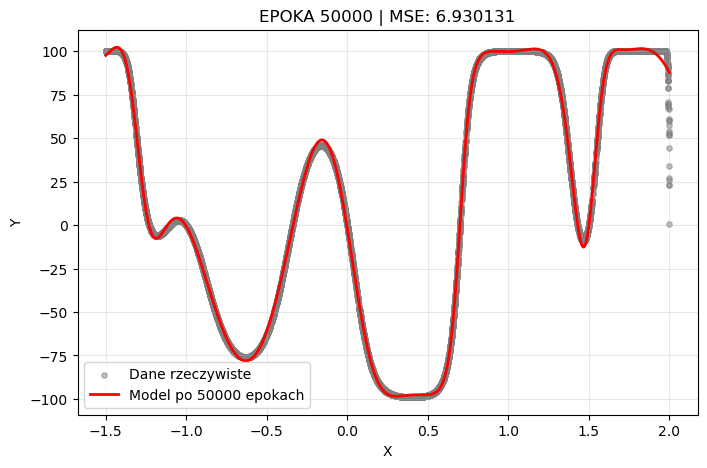

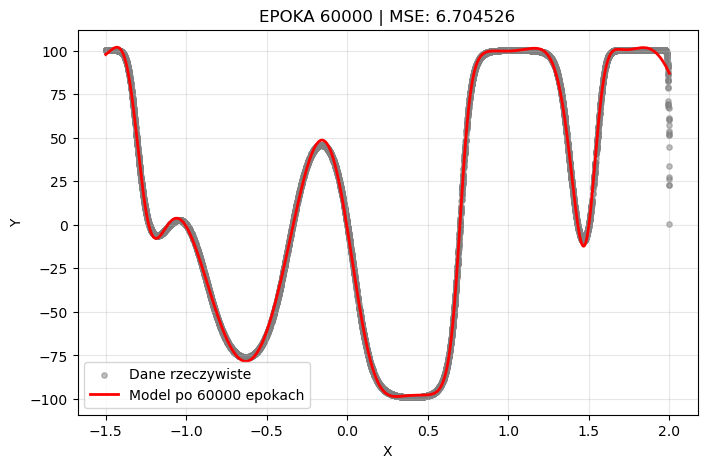

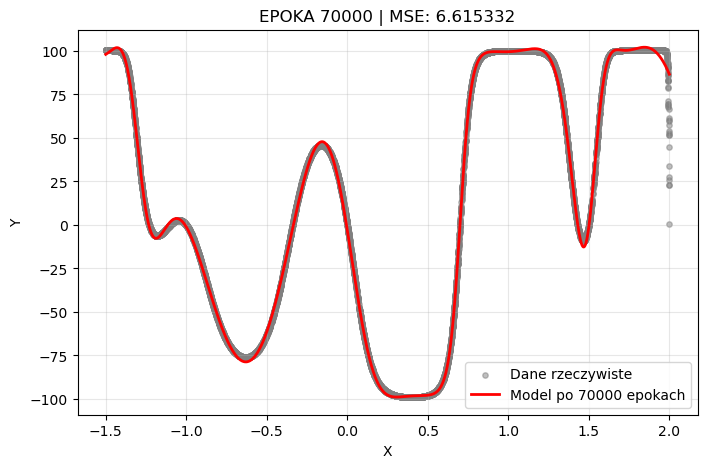

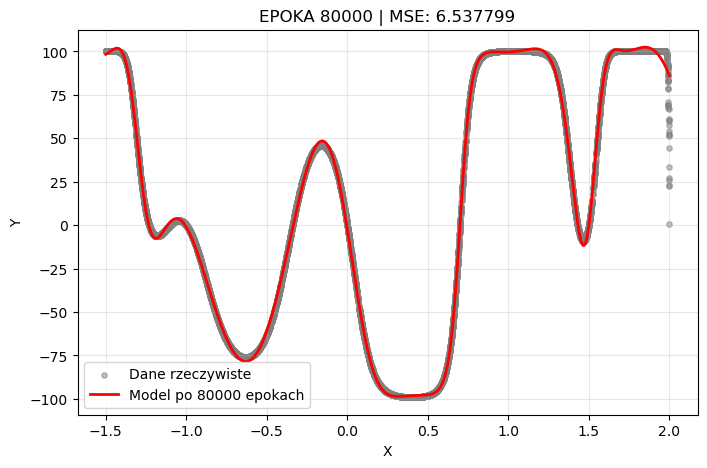

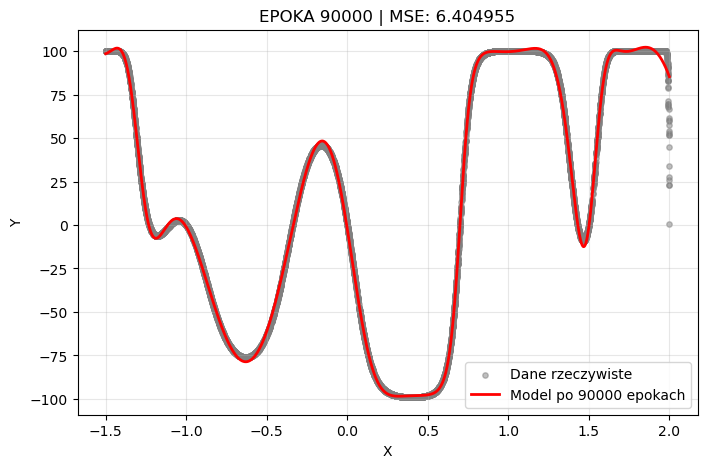

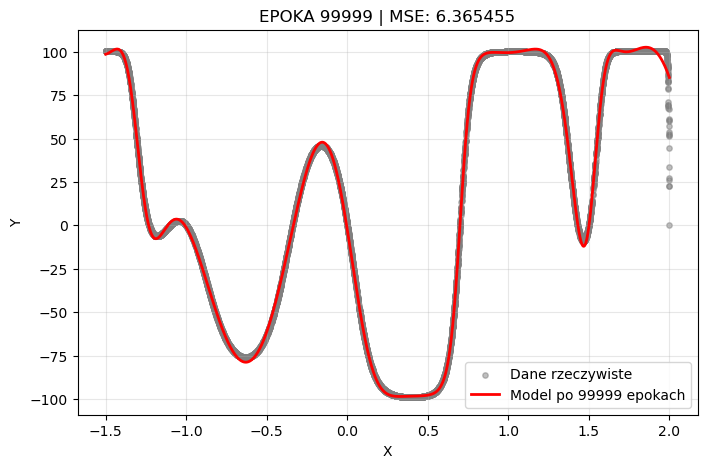

Wagi:
[array([[ 1.07848114,  0.98390565,  2.07824991,  2.47450779, -1.0903115 ,
        -3.8833644 ,  1.27866972, -3.80817888,  3.9454548 , -2.19859359,
        -1.0982347 , -2.86252562,  1.698303  ,  2.65594348, -1.37994285,
         1.09361962,  1.38029901,  2.6845524 , -1.61240508,  3.19304349]]), array([[ 0.5382571 , -0.78919065, -1.04307815,  0.52176836, -0.97098989,
         0.51738275,  0.05095127,  0.31408335, -0.26406672,  0.44881777,
         0.20879893,  0.34834873,  0.86181123,  1.17810625,  0.28884411,
        -0.24810599,  0.98180394,  0.9773461 ,  0.31233752,  0.04245615],
       [ 0.6357625 , -0.11295637,  0.25345178, -0.99471178,  0.27456766,
         0.95179122, -1.00733222,  0.16349291, -0.31011155,  1.05392227,
         0.11346506, -0.51572944,  0.31220136,  0.73685433, -0.93131545,
        -0.6515406 , -0.65658208, -0.4836943 , -0.85116297,  0.71328321],
       [-1.4494955 , -0.27185295,  0.16307399, -0.91221412,  0.62602462,
         0.39805682, -0.19517498,  1.22

In [9]:
start = time.time()
mlp_ml_batch.train(x_ml, y_ml, epochs=100000, lr=0.01, batch_size=32, verbose=True, epochs_between_graphs=10000)
time_batch = time.time() - start

print("Mini batch time:", time_batch)

In [ ]:
ml_w_batch = [np.array([[ 1.07848114,  0.98390565,  2.07824991,  2.47450779, -1.0903115 ,
        -3.8833644 ,  1.27866972, -3.80817888,  3.9454548 , -2.19859359,
        -1.0982347 , -2.86252562,  1.698303  ,  2.65594348, -1.37994285,
         1.09361962,  1.38029901,  2.6845524 , -1.61240508,  3.19304349]]), np.array([[ 0.5382571 , -0.78919065, -1.04307815,  0.52176836, -0.97098989,
         0.51738275,  0.05095127,  0.31408335, -0.26406672,  0.44881777,
         0.20879893,  0.34834873,  0.86181123,  1.17810625,  0.28884411,
        -0.24810599,  0.98180394,  0.9773461 ,  0.31233752,  0.04245615],
       [ 0.6357625 , -0.11295637,  0.25345178, -0.99471178,  0.27456766,
         0.95179122, -1.00733222,  0.16349291, -0.31011155,  1.05392227,
         0.11346506, -0.51572944,  0.31220136,  0.73685433, -0.93131545,
        -0.6515406 , -0.65658208, -0.4836943 , -0.85116297,  0.71328321],
       [-1.4494955 , -0.27185295,  0.16307399, -0.91221412,  0.62602462,
         0.39805682, -0.19517498,  1.22195644,  0.56760568, -0.14397222,
        -0.35033446, -1.22339287,  0.55791604,  1.68207451, -0.36528324,
         0.12677373,  1.04154998,  0.11371019,  0.01617157,  1.0767367 ],
       [-1.54236618, -0.57984744,  1.11214886,  0.15057785,  0.67839159,
         0.89444552,  0.35087729, -0.61518461,  0.97125545,  0.70951441,
        -0.75583635, -0.87008269, -0.38957087,  1.63576679,  0.756883  ,
         0.76329601,  0.55803489, -0.33197219, -0.67599228,  0.43843096],
       [ 0.79279798,  0.76665245,  0.31801531, -0.67452686,  0.59495338,
        -0.20295278,  0.53387709, -0.06256397, -0.64766719, -0.88505176,
        -0.11256511,  0.8539007 , -0.84442047, -1.0602005 , -0.58367798,
         0.94136678, -0.45849485,  0.45245021,  0.78788639, -0.89328738],
       [ 1.76926307,  0.12238319,  3.03262   , -0.89491671,  0.49386572,
         0.46723753, -0.96853175, -3.43603264,  0.45405966,  0.68456123,
        -0.08273758,  0.67533584, -2.34670985, -0.4480382 , -1.04124355,
        -0.6410787 ,  0.31575981, -0.57726207, -0.57445537, -0.09828932],
       [ 0.16770846,  0.38170593, -1.23813683,  0.35394831,  0.20982577,
        -0.31035497,  0.35703747,  1.55062247,  0.36547179,  0.64713203,
        -0.75829701, -0.24808592, -0.06211091,  0.18319862,  0.31282314,
        -1.01746163,  0.36686366,  0.68031914,  0.77182276, -0.1639033 ],
       [ 0.01102317,  0.04958328,  2.2265828 ,  0.47875611,  0.4842911 ,
        -0.47287324, -0.71120551, -2.90065258, -0.65159896, -0.6306321 ,
         0.64151394,  1.54199087, -2.15805302, -0.64787561, -0.05102415,
         0.81363793, -0.07283259, -1.26792579,  0.52679113, -1.46948606],
       [-1.32048616,  0.8208515 ,  0.50730144, -0.56647492,  0.21605603,
        -0.357474  , -0.30776957,  1.50479927,  0.05145823, -0.29967832,
         1.3159982 ,  0.27013392, -0.46464007,  3.24280964, -0.56132179,
         0.3063097 ,  1.13974549,  0.14352709,  0.00841501, -0.03113175],
       [ 0.44793361, -0.70097945,  2.06912105,  0.83206411, -0.11006842,
        -0.65975636,  0.76048161, -1.66202811,  0.65805609, -0.79847963,
        -0.23856945,  0.63788857, -1.44967291,  0.48062917, -0.66483424,
         1.01613516,  0.1748462 , -0.97882787,  0.57063211, -0.20680557],
       [ 0.30773939, -0.34158736, -0.66806256,  1.04025123, -0.17948886,
         0.86347777, -0.17544663,  0.13190373, -0.2128354 , -0.09667599,
        -0.68670563, -0.35947   ,  0.78054779, -1.24736437,  0.71271675,
        -0.06694362, -1.25392821, -0.48455563,  0.69714948, -1.06567443],
       [ 1.31795215,  0.5501479 , -1.16573053,  0.76874794,  0.94081268,
        -0.54349476,  0.39616734, -1.1464167 ,  0.13829724,  0.30752445,
        -0.73108444,  0.47492564,  0.14603674, -1.40631209,  0.41289253,
        -0.46048033, -1.54395591,  0.65519205, -0.76370151,  0.72411698],
       [ 0.84628019, -0.04829723, -0.26207341,  0.58990526, -0.30745534,
         0.42946164, -0.4269133 ,  1.92764818,  0.70635194, -0.45868423,
         0.50808798, -0.02378873, -0.43250665,  1.47825321, -0.69662707,
        -0.16016159, -0.18030688, -0.63163728, -0.26105785, -0.44627952],
       [ 0.85058387,  0.49307424, -1.86535817, -0.29843908, -0.21050628,
        -0.72738842, -0.18632034,  1.88619067, -0.27599348, -0.90789163,
         1.02315088, -1.84782116,  0.50152818,  1.16648599, -0.939554  ,
        -0.12582959,  0.77348502, -0.28578031,  0.25660223,  0.97521288],
       [ 0.14269848,  0.41218744, -1.44537159, -0.70280974, -0.95980344,
        -0.07035206,  1.02279668, -0.98290352, -0.98842801,  0.03310608,
        -0.20843439,  0.65206583,  1.20981817, -0.67681017, -0.15698006,
         0.78229066, -1.32355738, -0.88283673,  0.88912409, -0.94651174],
       [ 0.66427048,  1.05660535, -1.14498151, -0.57335539,  0.83988631,
        -0.22036811, -0.60683021,  1.33111863, -0.22387494, -0.33303296,
        -0.10099494,  0.34008412,  1.52980793, -0.48188024, -0.25625009,
        -0.93841485,  0.10771432, -0.32202097,  0.99999581,  0.58844886],
       [ 0.80697736,  0.35285365, -1.51758648, -0.59777835, -0.96700855,
         0.44576174, -0.78254622,  1.06520794, -0.23937575, -0.94339986,
        -0.06243751,  0.27546546,  0.15639619, -0.59938197, -0.26106765,
        -1.01350158, -0.37021748,  0.81941742, -0.04221171,  0.67517944],
       [-1.84704299,  0.58359904, -0.69356949, -0.52989449,  0.38645643,
         0.26177429, -0.43447583,  2.42229607,  0.54969199,  0.5456097 ,
         1.02778406, -1.28942833,  0.4991474 ,  1.29575469,  0.90482984,
         0.64628234,  1.00197115,  0.2814938 , -0.02988654,  1.43325171],
       [ 0.97602769, -0.50258299,  1.07903858, -0.76425272,  0.81725796,
        -0.28681636, -0.64167152, -1.23609306,  0.42309646, -0.23531586,
        -0.92340966, -0.08522866, -0.99508034,  0.34691528, -0.15395227,
         1.22054469, -0.25208591, -1.10334819, -0.82715539,  0.6443262 ],
       [-0.79532888, -0.32345685, -3.16459057,  0.43055378,  0.53523997,
        -0.68392362, -0.11277181,  3.02486997,  0.68892116,  0.24439475,
         0.04223109, -0.53144904,  1.38124515,  0.43211279,  1.01963428,
        -0.28179786, -0.65905941,  0.01239213, -0.80755929,  0.32994935]]), np.array([[-2.388579  ],
       [-0.82148138],
       [-1.77930084],
       [ 0.96871734],
       [ 0.58277067],
       [-0.3093443 ],
       [-0.76164429],
       [ 0.51050725],
       [-0.4441273 ],
       [ 0.15906658],
       [-0.955755  ],
       [-1.20593995],
       [-2.48336146],
       [-1.10636878],
       [-0.27180119],
       [ 1.33060724],
       [ 1.72581068],
       [ 1.46009075],
       [-0.01911549],
       [-3.03660605]])]

ml_biases_w_full = [np.array([[-0.49696584,  0.80272794, -0.12298493,  0.16115673,  0.28015275,
         2.80084055, -1.15545894,  2.28554785, -0.1856328 ,  2.2148679 ,
        -0.50993338,  0.00432384, -0.41666624, -1.19330547, -0.35087783,
        -1.3231338 , -1.2588748 , -1.66066683,  1.74538889, -2.615295  ]]), np.array([[ 0.76183867,  0.85853487, -0.18846048,  0.4195548 ,  0.27263894,
         0.04211013, -0.86717708,  0.1361775 ,  0.60846898, -0.36827409,
         0.26640996,  0.42802632, -0.80310147,  0.9303021 , -0.96203905,
         1.05519206, -0.02472023, -0.62188822, -0.23627509, -0.46694789]]), array([[-0.9395098]])]
Mini batch time: 1816.0207562446594



In [ ]:
# porównanie czasu
# Full batch time: 1320.2336320877075
# Mini batch time: 1816.0207562446594